Colab Link
https://colab.research.google.com/drive/1d32YIX2mPuF5RYWRsAKzIYex1JtpF512#scrollTo=-1x7mrxdHxM8


# AutoCorrelation and PartialAutoCorrelation

Correlation analysis is an important step in the Exploratory Data Analysis of time series forecasting. The autocorrelation analysis helps detect patterns and check for randomness.

> To find the value of m, we analyse the series and select the value based on that, but that may not be clear, so we use correlation to find the best value of m

Due to the continuous and chronologically ordered nature of time series data, there is a likelihood that there will be some degree of correlation between the series observations.

**the correlation is a snapshot measure of global synchrony**

- Analyzing the correlation between a series and its lags can help us find the value of m



Given our current time series  𝑦(𝑡) ,
- What if we consider another time series where we introduce a lag of 1, i.e. shift the series by 1 unit of time:  𝑦1(𝑡)
- We can then find the correlation coefficient between these two time series:  𝑦(𝑡)  and  𝑦1(𝑡)
- Similarly, we find the correlation between the original time series  𝑦(𝑡)  and a time series lagged by i units:  𝑦𝑖(𝑡) , where  𝑖=1,2,3,...  (i represents lag)
- In doing so, we would find a value of  𝑖 , where the lagged time series rougly overlaps over the original series.

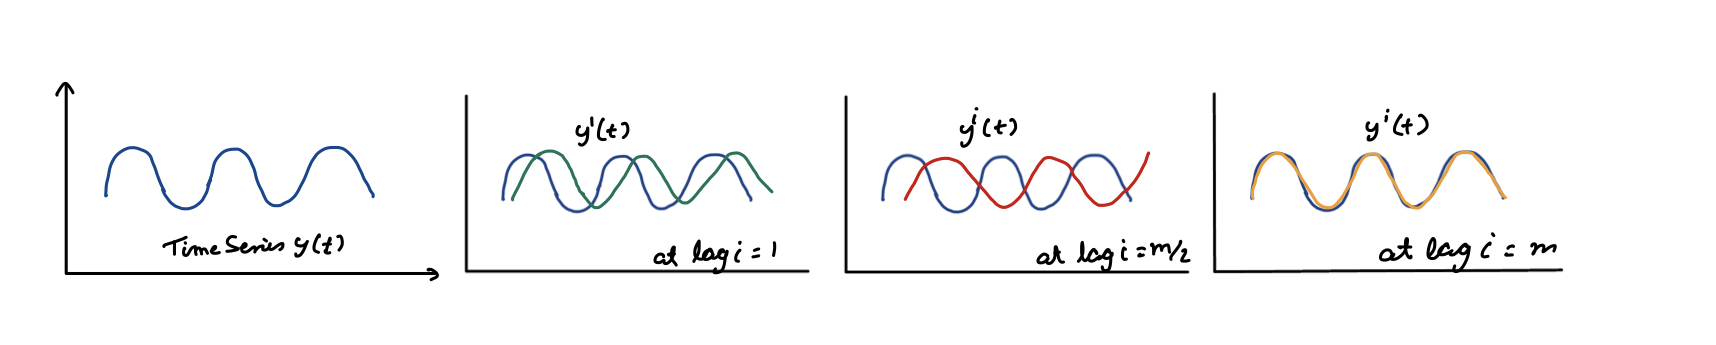

What will the plot between correlation coefficient and lag (i) look like?

- At  𝑖=𝑚 , we would get a correlation value very close to 1.

- At  𝑖=𝑚/2 , as the value of lagged time series increases, the value of original series decreases, giving us a strong correlation

- For a value of  𝑖  that is even close to  𝑚 , though the correlation value would not be as strong as at  𝑚 , but it would be relatively strong.

## ACF

Autocorrelation is the correlation between a time series with a lagged version of itself. The ACF starts at a lag of 0, which is the correlation of the time series with itself and therefore results in a correlation of 1.

 Autocorrelation is similar to the correlation between two different time series in theory, but it uses the same time series twice: once in its original form and again with one or more time periods added.

**There is a correlation with each latency**

The autocorrelation function (ACF) evaluates the correlation between observations in a time series over a given range of lags. Corr(yt,yt-k), k=1,2,…. gives the ACF for the time series y. We generally use graphs to demonstrate this function.


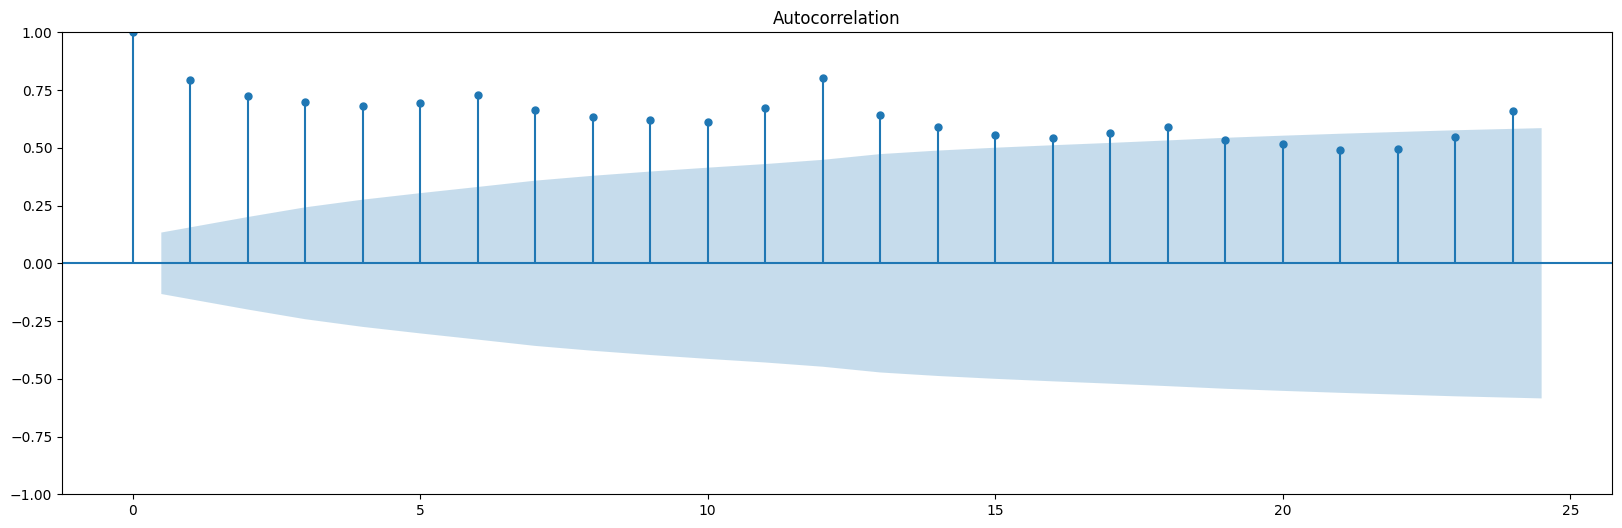

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(myntra_sales.Sales);

- From the plot we can see that the correlation value increases at every six months which we couldn't recognise just by looking at the actual data plot. So there is also a **6 month seasonality**.

- It peaks every 12th month.

<br>

For this time series, correlations are quite high.

Let's see the ACF plot for the **de-trended series**. Because intuitively also, finding seasonalities on a de-trended series would be better.

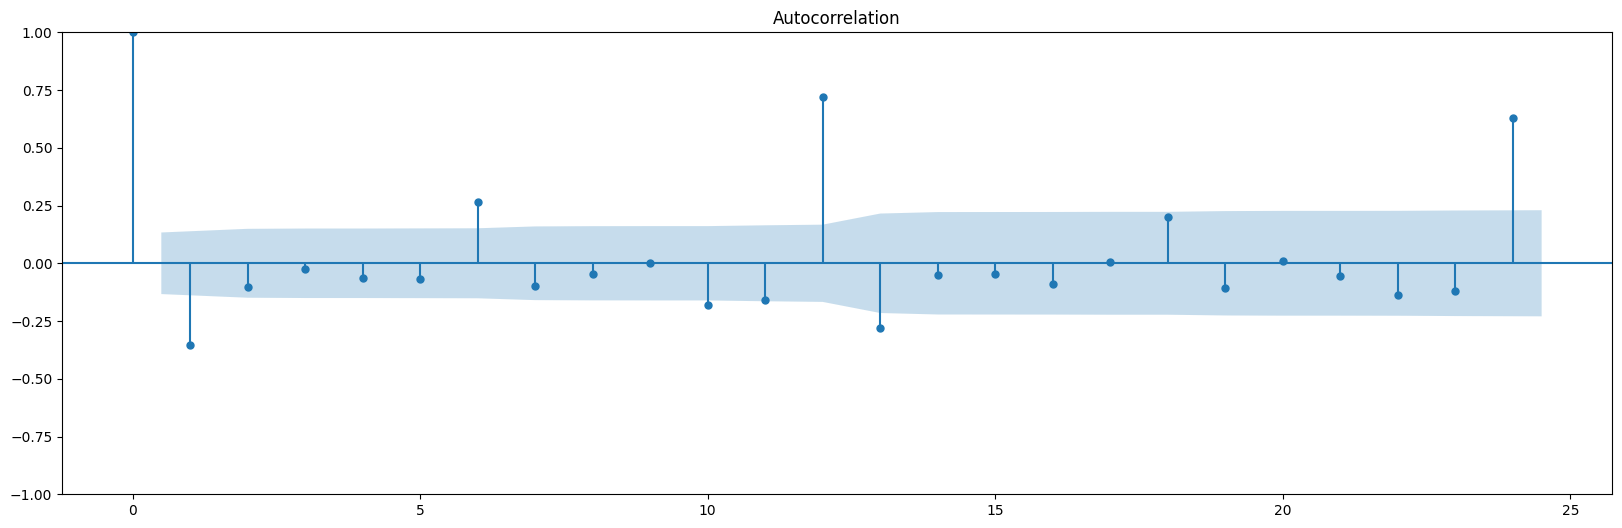

In [ ]:
plot_acf(myntra_sales.Sales.diff().dropna());

- After de-trending the series, we can see the correlation of the series is high at period of 12 and 6. This indicates there is some seasonality.

- Besides that, the correlation values are random and small.

- On removing the trend, we're able to capture negative correlations between the original series and lagged series with more ease.

- As per business logic, we can expect to see a dip right after peak/holdiday season.

Let's do the de-seasoning, in order to get a **stationary series**, and see the ACF for it.

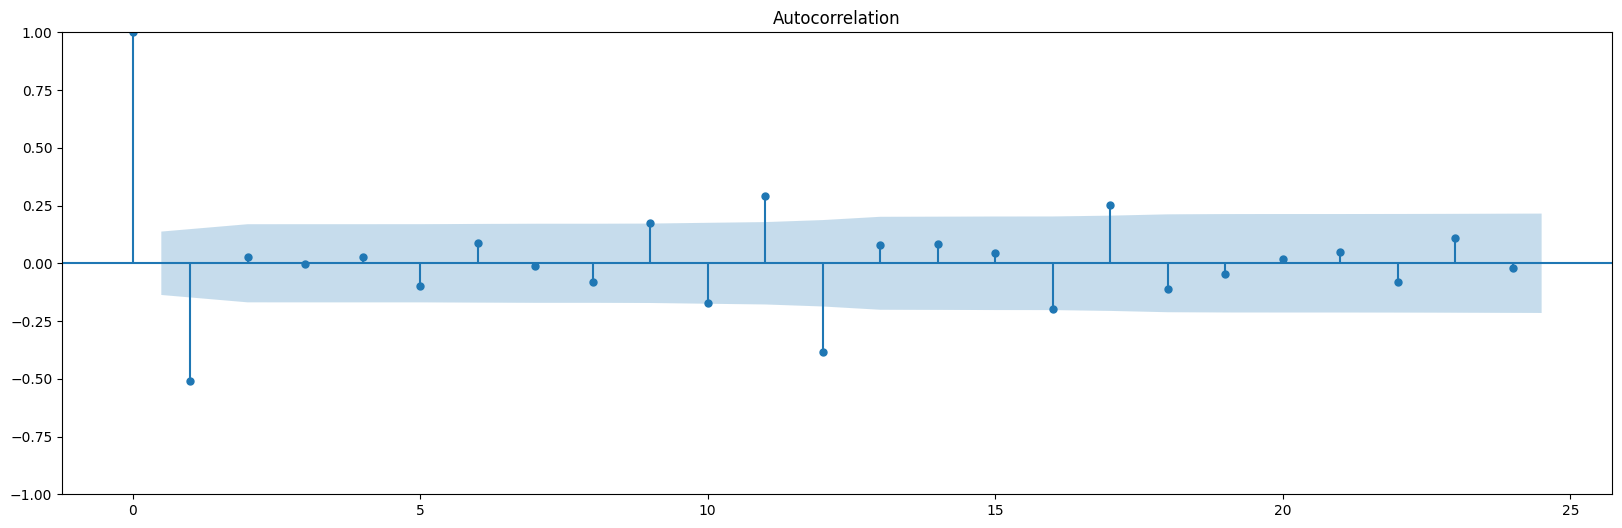

In [ ]:
plot_acf(myntra_sales.Sales.diff().diff(12).dropna());

Here we can see the significant decrease in the correlation values , that means seasonality is reduced



## PACF

The partial autocorrelation function, like the ACF, indicates only the association between two data that the shorter lags between those observations do not explain. The partial autocorrelation for lag 3 is, for example, merely the correlation that lags 1 and 2 do not explain. In other words, the partial correlation for each lag is the unique correlation between the two observations after the intermediate correlations have been removed.

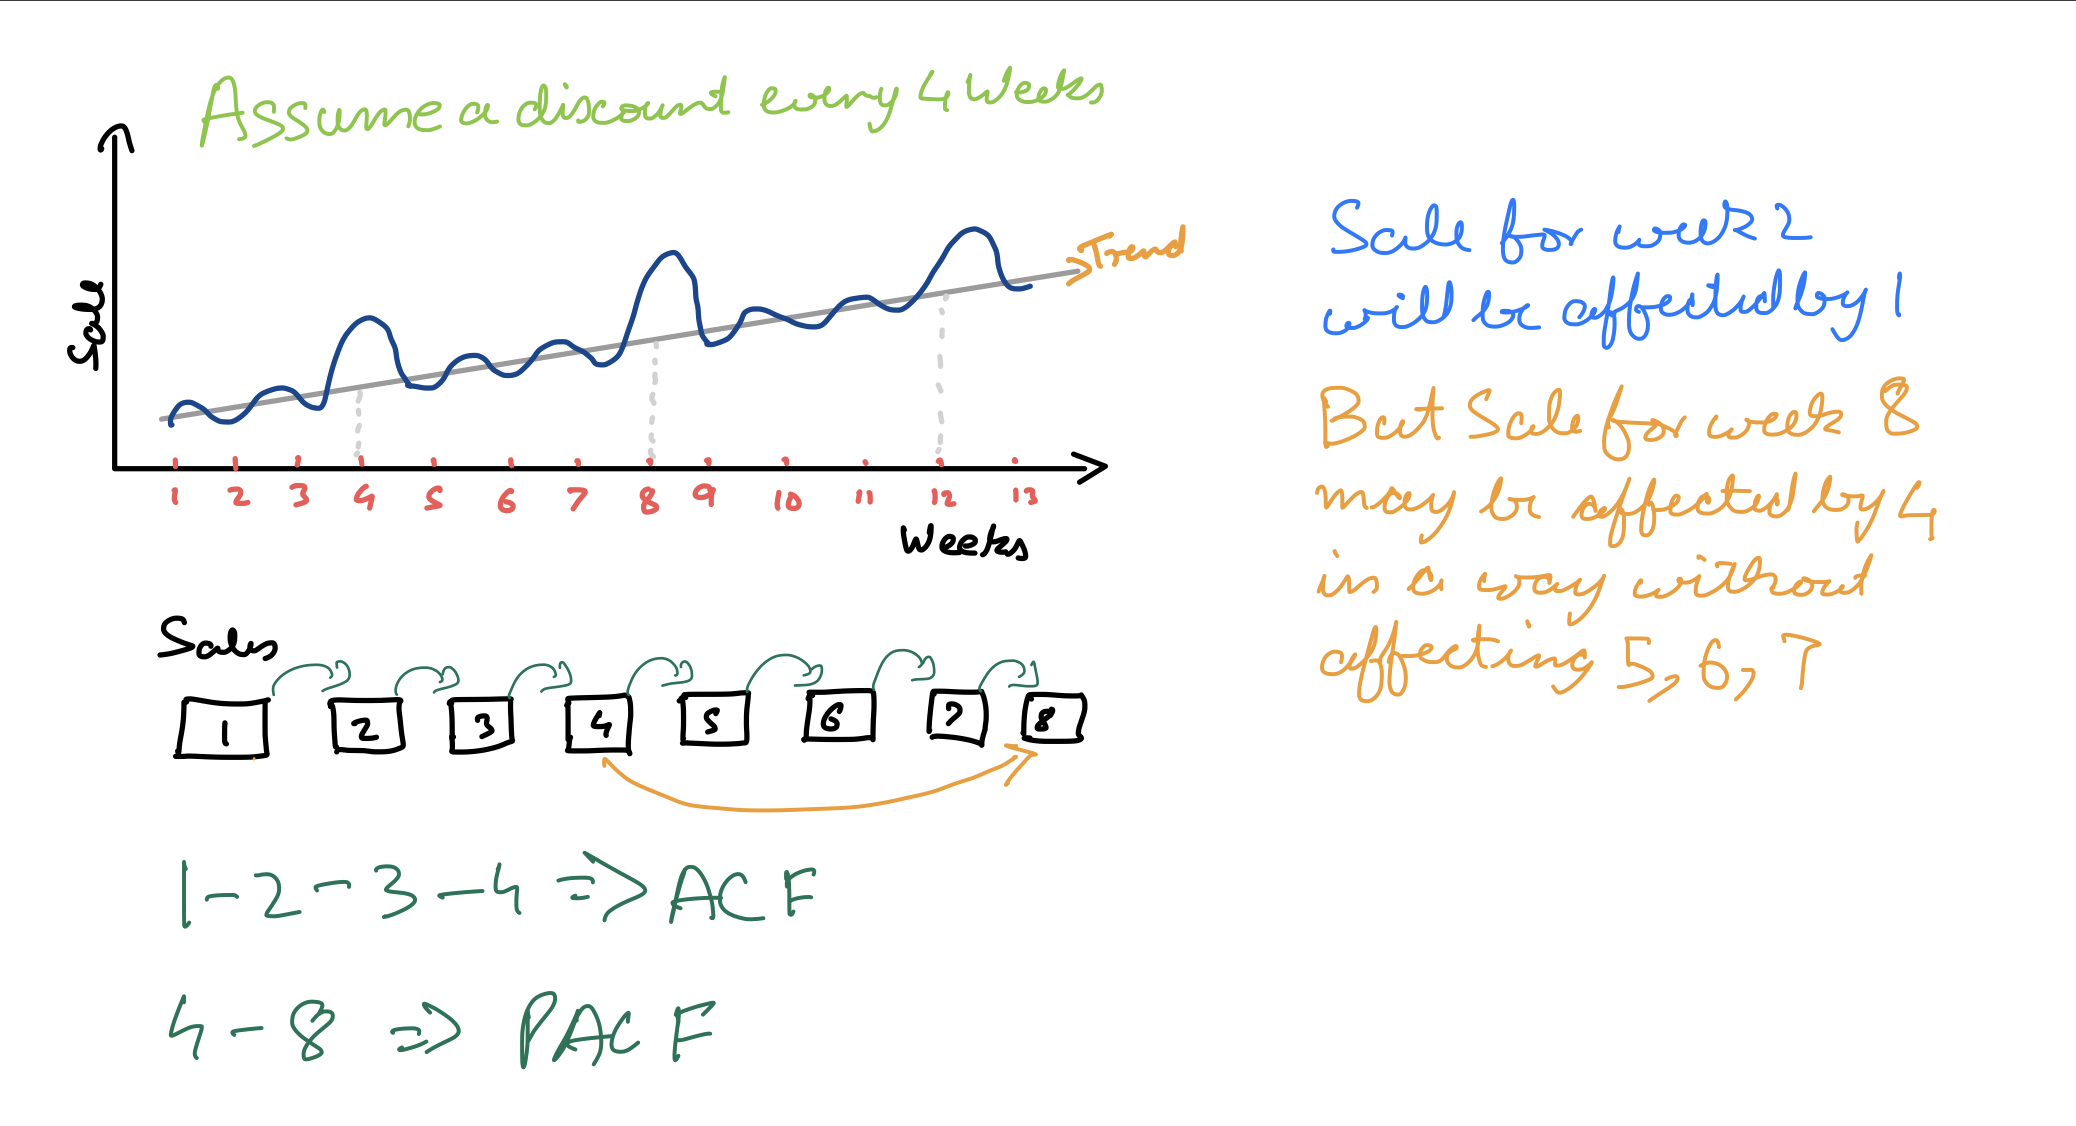

- The partial correlation for each lag is the unique correlation between the two observations after the intermediate correlations have been removed.

This is also known as Conditional AutoCorrelation.

Let's have a look at the Partial Auto Correlatio Plot (PACF)

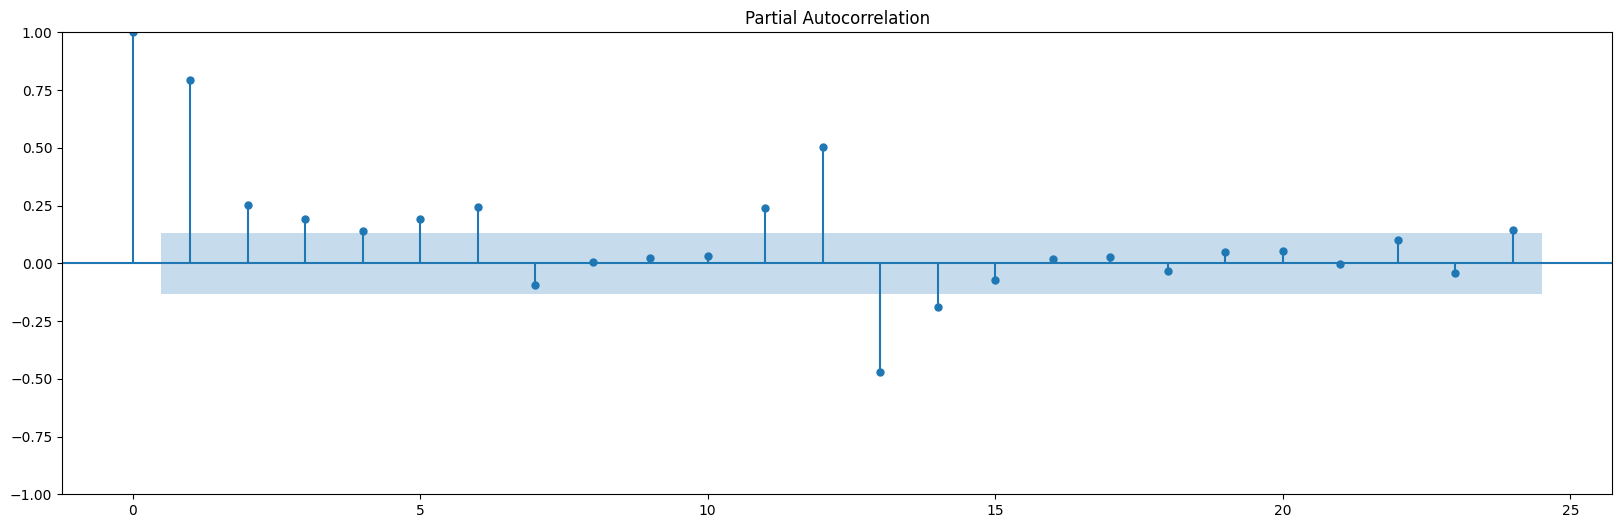

In [ ]:
plot_pacf(myntra_sales.Sales);

This PACF makes the correlation clear.

**Interpretation:-**
- Value at $i=1$ is high: This means that given the values of time series $y(t)$, we can compute the values of a time series with lag 1, $y^1(t)$ with ease.
- There is a high value at $i=12$
 - This means that even if we ignore the information given by all the time series with $lags=1, 2, ..., 11$, the information carried in time series $y^{12}(t)$ alone is very high.
 - This shows strong seasonality

<br>


**Observations:-**
- Autocorrelation plot is as expected; series does not seem to be stationary
- Diff series is indeed stationary. Also, seasonality can be seen using this plot.
- De-seasoned series does not have any seasonality or trend.
- PACF suggests that only the first lag and 12th lag is strong.

> **NOTE:-**
- **We calculate PACF on the original time series, whereas ACF is plotted on stationary time series.**

#### Quiz-2

```console
If we have a sine wave, plotted in degrees, with time period 360 degree, and 1 lag represents 1 degree, at what lag will the autocorrelation be
minimum?

1. 0
2. 45
3. 90
4. 180
```

Ans: 180 degree, corr = -1, at 90 it would be 0.

**Note: the values that we get from the ACF and the PACF pots is lot more experimental and depends a lot on domain and problem statement. the rules that we discuss are just a guideline to follow but may or may not give the best result, so the values are to be experimented with and best decided based on domain understanding**

## Correlation Vs Causation

A variable x  may be useful for forecasting a variable  y, but that does not mean x is causing y.

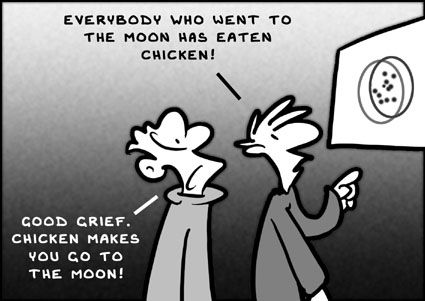

Correlations are useful for forecasting, even when there is no causal relationship between the two variables.

For example,
- It is possible to forecast if it will rain in the afternoon by observing the number of cyclists on the road in the morning.
- When there are fewer cyclists than usual, it is more likely to rain later in the day.

This model can give reasonable forecasts, not because cyclists prevent rain, but because people are more likely to cycle when there is less or no chance of rain.

In this case, there is a causal relationship, but in the opposite direction to our forecasting model.

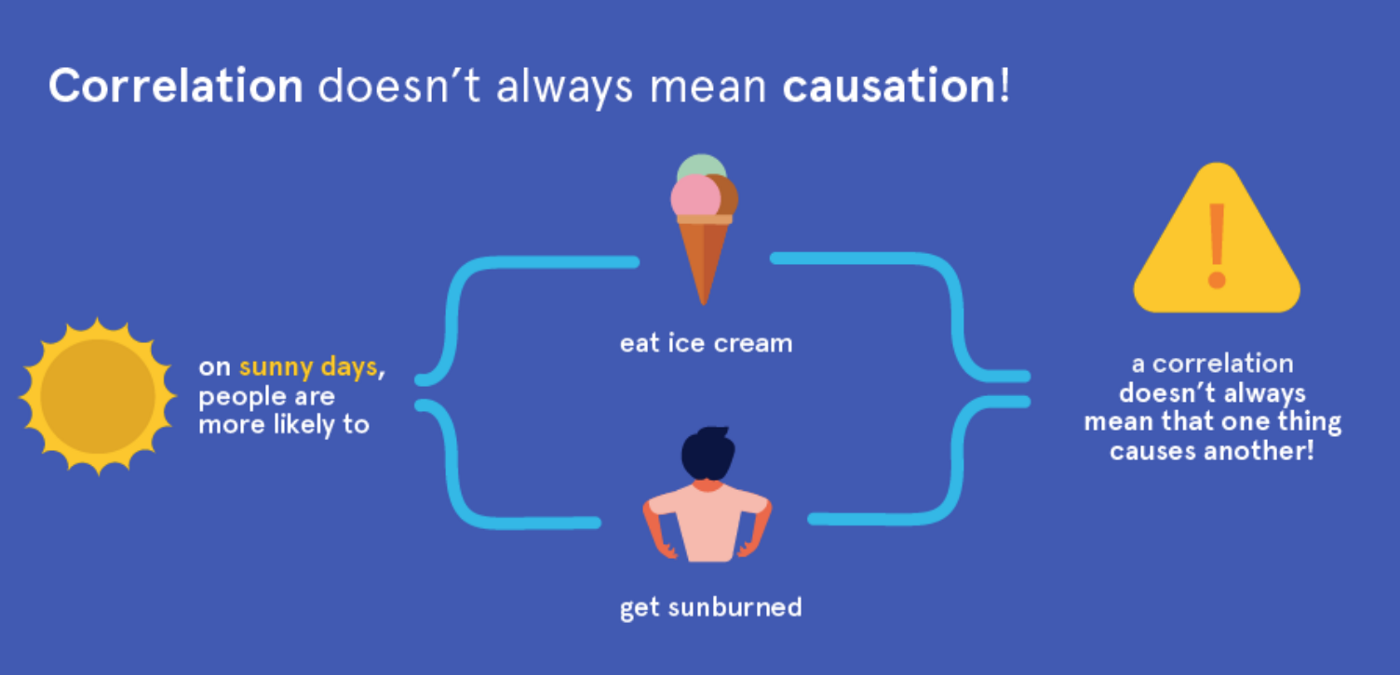

Though we can get good forecasts based on correlated variables, if we try and understand the causality behind those variable, we can identify better features, thereby creating a better model.

# ARIMA Family of Forecasting Techniques

## 1. Auto Regression (AR)

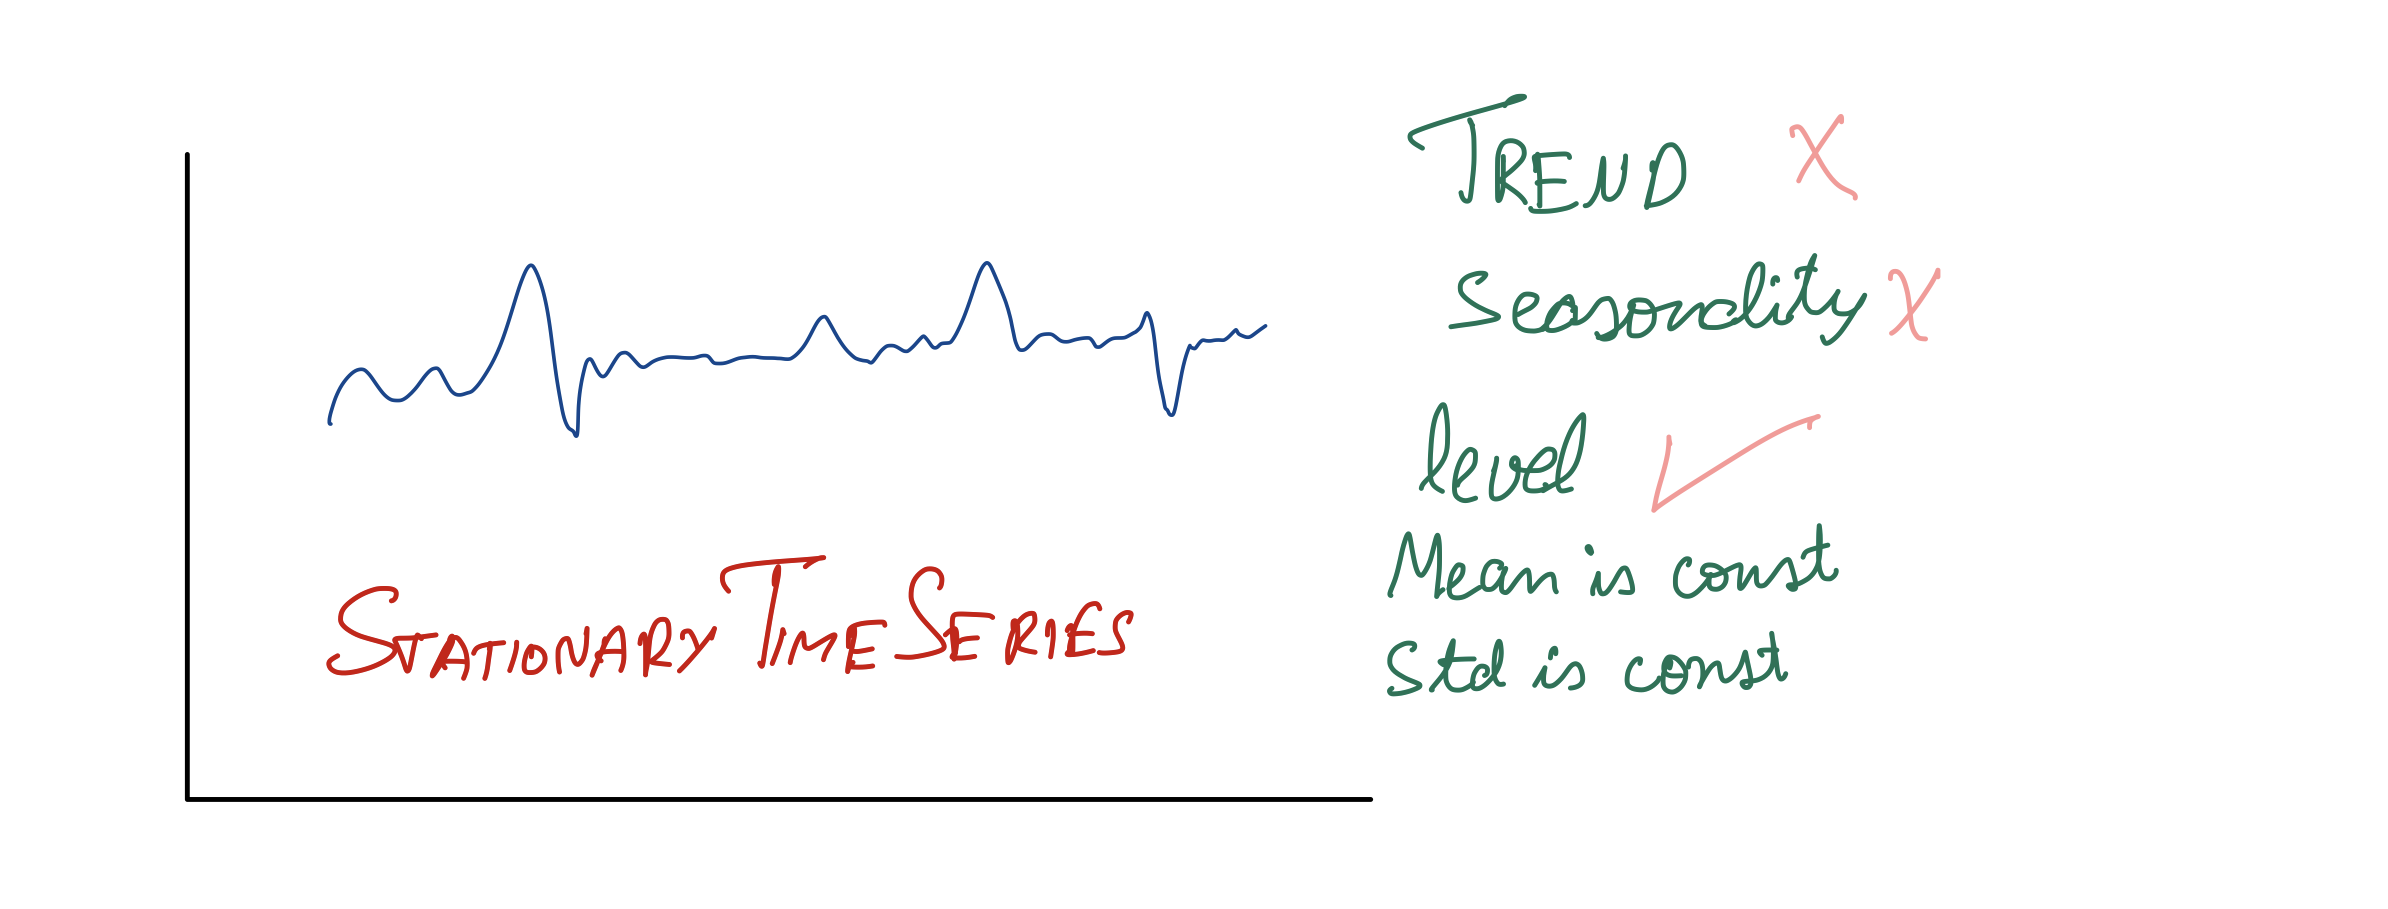

So far, the models we've seen, assume a trend and seasonality component.

But what about the case of stationary series?
In this case, we're kind of helpless, because there is no pattern in the series.
For such cases, we study this new family of models, called ARIMA Family.

- Though such series look like they are completely random, there is still some extent of forecastability here,

There is still information left to be extracted from stationary series.
- Any trend or seasonality that was present, has been removed from series, will be added later

An autoregressive model is when a value from a time series is regressed on previous values from that same time series
In this regression model, the response variable in the previous time period has become the predictor and the errors have our usual assumptions about errors in a simple linear regression model.

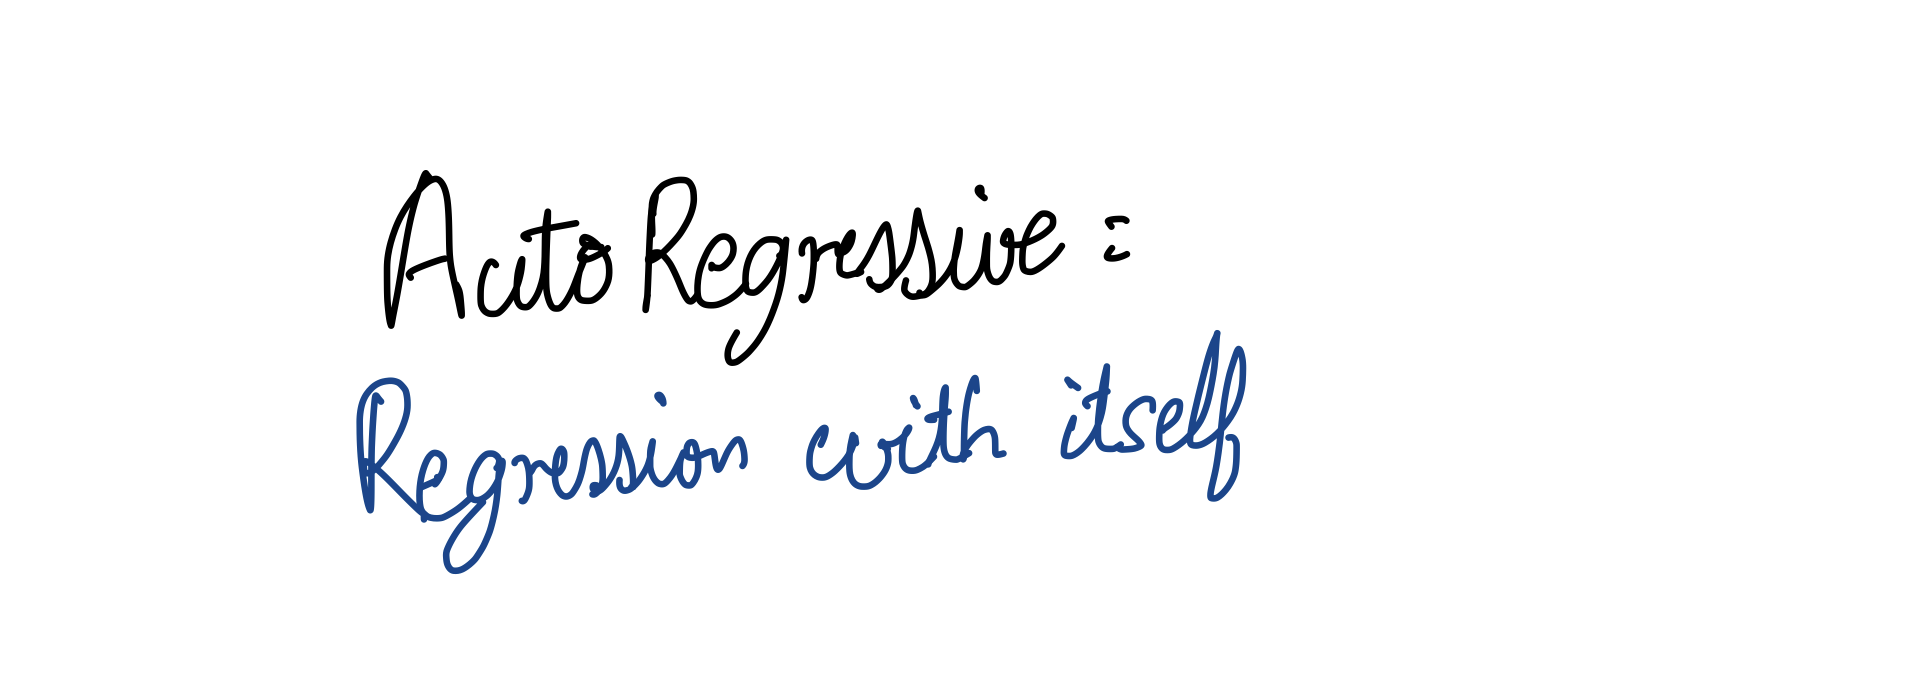

 we could just utilise **Linear Regression**, by mapping this feature's values with the value to be forecasted.

<br>

We can use the past experience/values as feature, so that we can utilise Linear Regression.

We can map the value of the stationary time series at time $t$ with the value of series at time $t-1, t-2, t-3, ..., t-p$, where p is the number of past values we want to consider, it could be a **hyperparameter** we set.

This way, now our data becomes as shown.
- It contains date as index,
- Past values $y_{t-1}, y_{t-2}, ..., y_{t-p}$ as features and
- value at time $t$ as the value to be predicted ($\hat{y_t}$)

Now we can successfully implement Linear Regression using these features.

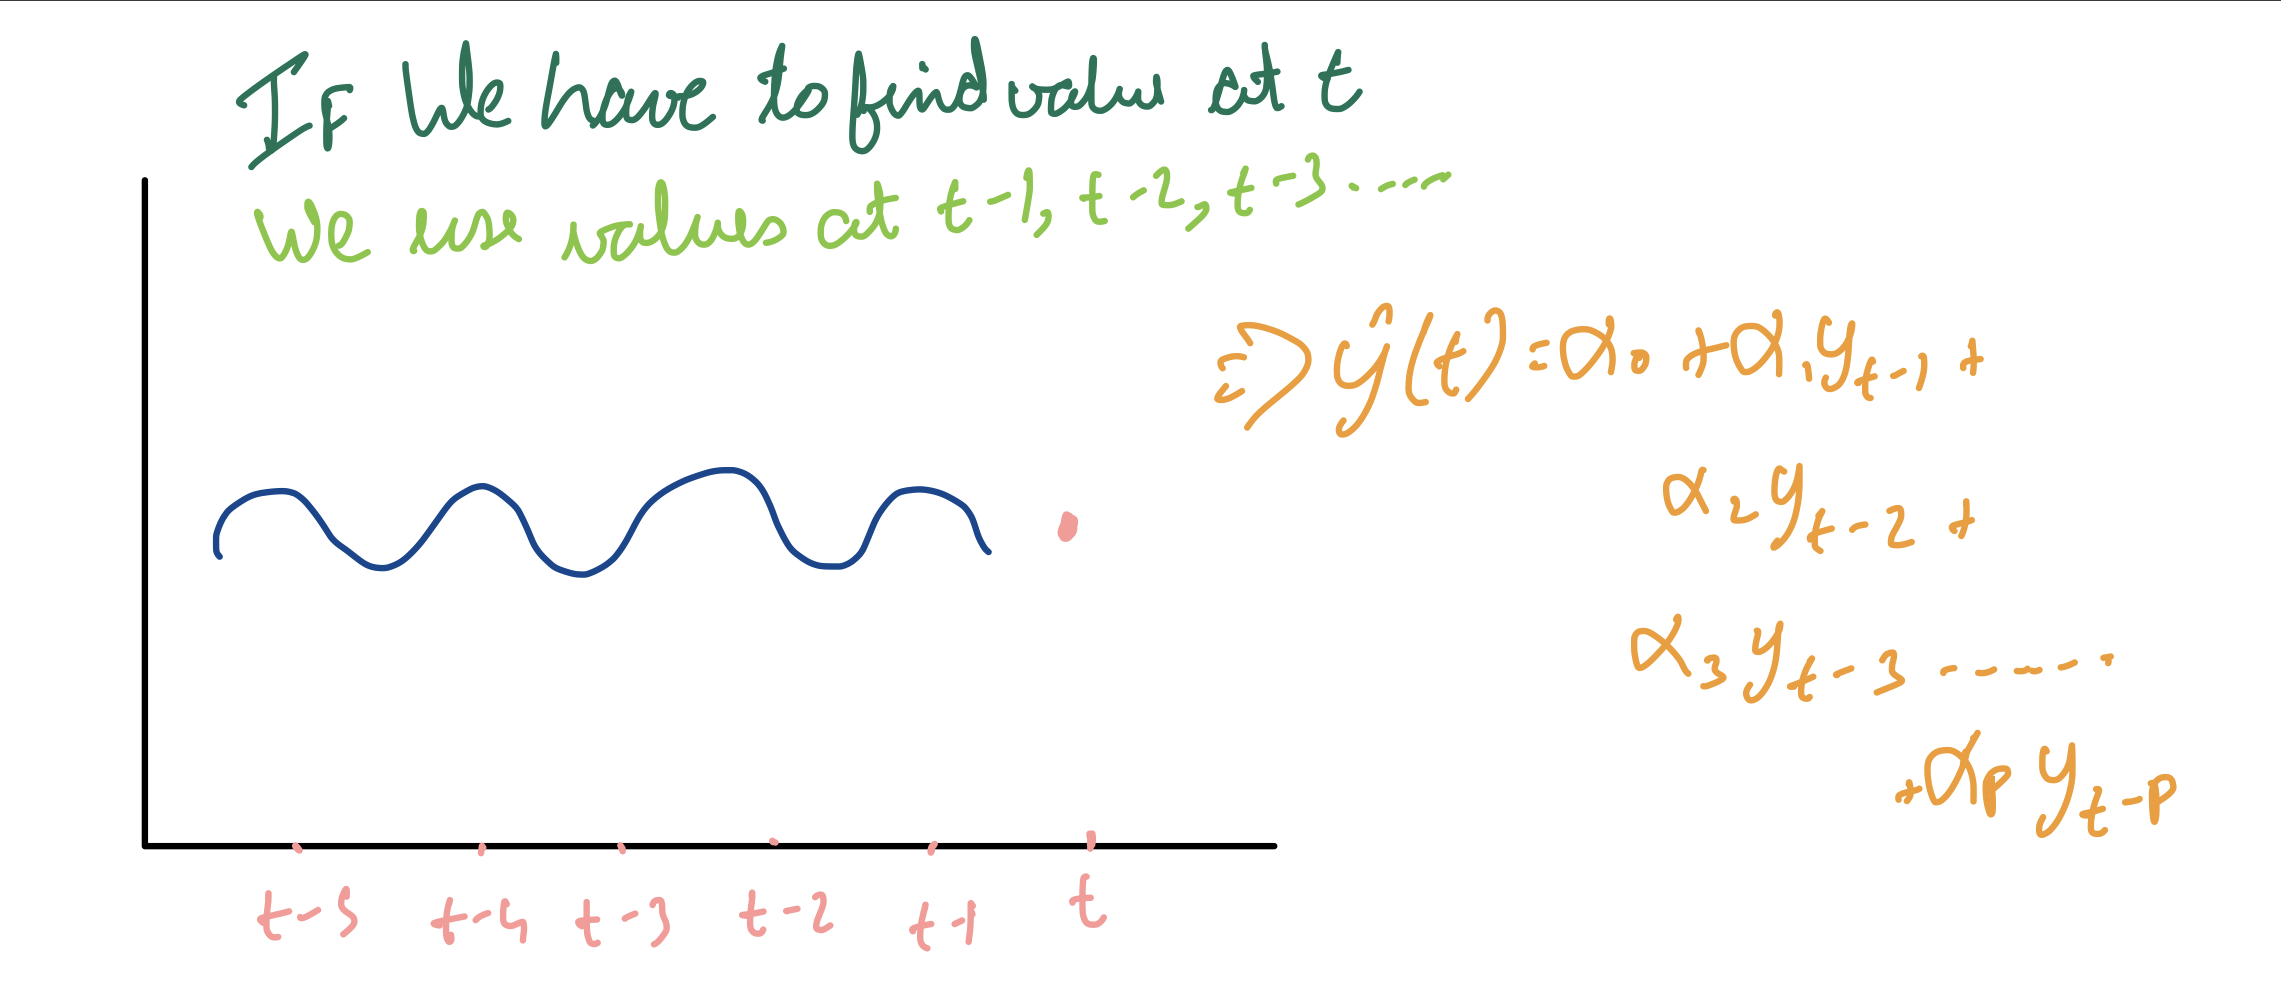

Essentially, we're converting our forecasting problem to Linear Regression.

We're saying that,

Future value $\hat{y}_t$ = LinearRegression(Past p values)

Recall the Linear Regression lecture, this converts our problem into following form

$ŷ_t = α_0 + α_1y_{t-1} + α_2y_{t-2}... + α_p y_{t-p}$

where
- $α_0$: intercept (parameter)
- $α_1, α_2, ..., α_p$: weights (parameters)
- $p$: No of past values to be considered (hyperparameter)

Hence, this is also known as the **AR(p) model**

Though we are essentially doing a weighted average of the past time series values in both SES and AR models, there is a fundamental difference.

**In case of SES**

- The weights are exponentially decaying
- The hyperparameter is  α

**In case of AR**

- The weights are learnt by multiple iterations.
- The hyperparameter is  𝑝

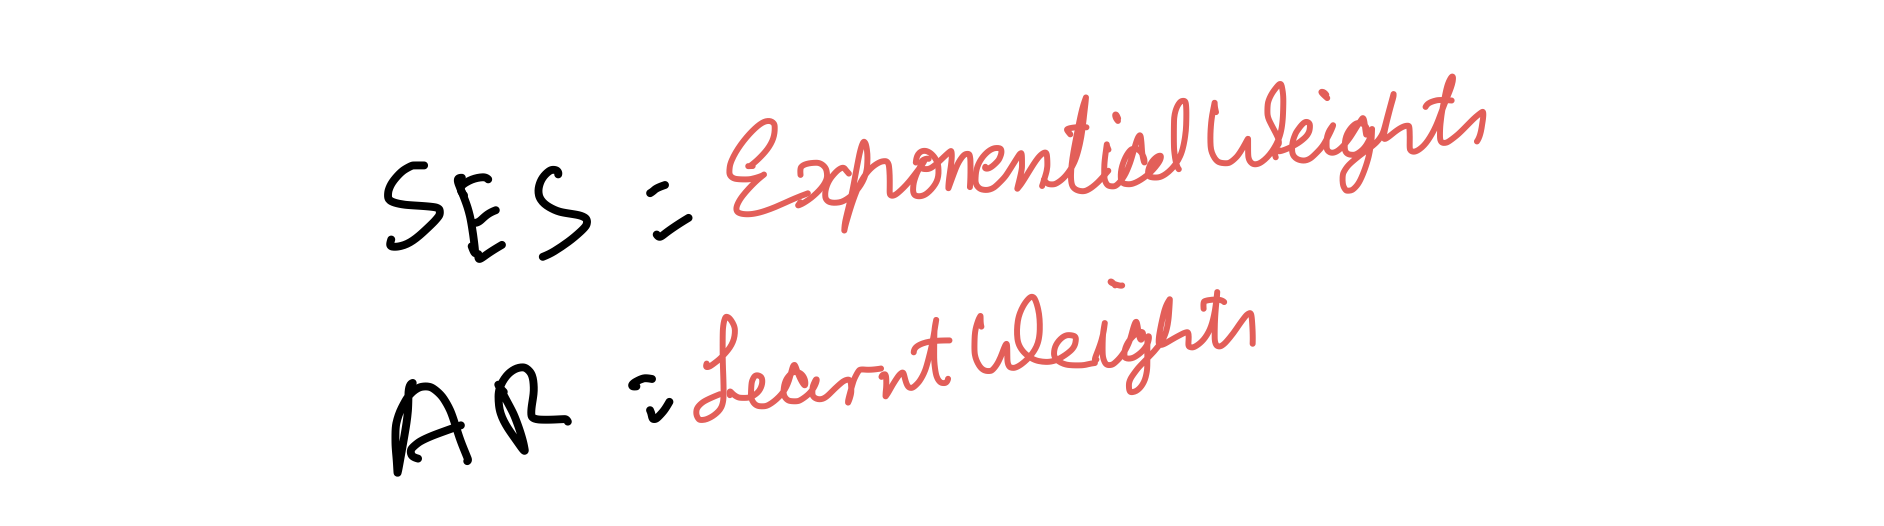

- so like linear regression the model will learn the weights
- the hyperparameter **p** is there for us to set

so how do we sset th hyperparameter

### Finding value of p from PACF

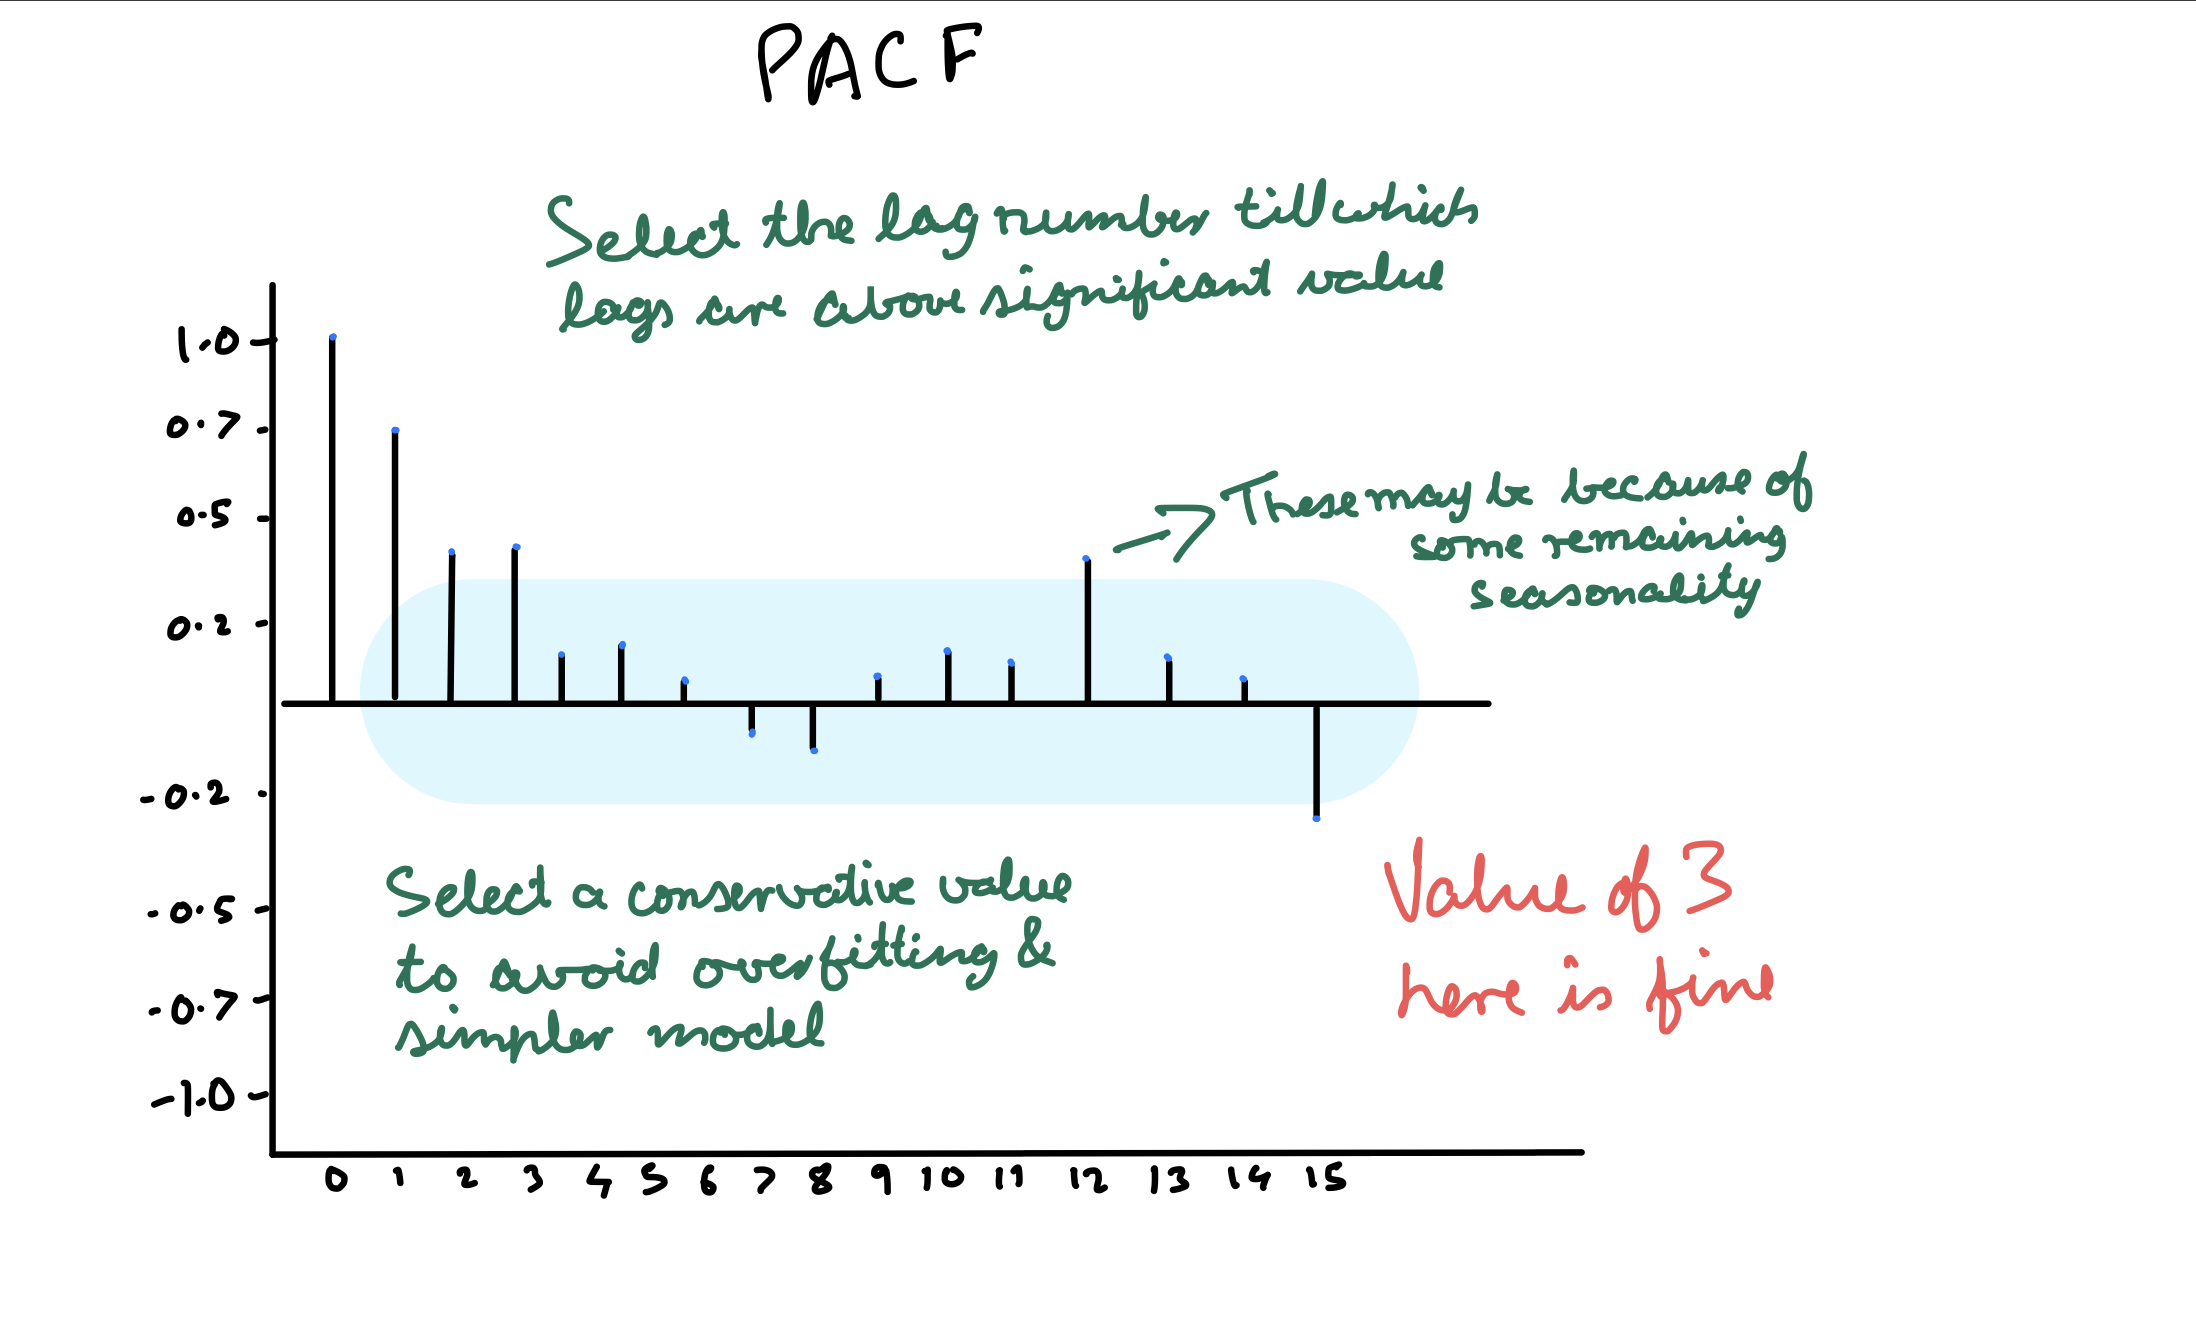

Before applying the AR Model, let's check the nature of our time series right now (stationary/non-stationary) using the `adf_test()`

In [ ]:
train_x.head()

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00


In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(train_x.Sales)

Sequence is not stationary


Recall that we need to have a stationary time series to use AR Model.

Let's **de-trend** it by taking a difference of 1.

In [ ]:
train_x_st = train_x.copy()
train_x_st.Sales = train_x_st.Sales.diff(1)
train_x_st.dropna(inplace=True)
adf_test(train_x_st.Sales)

Sequence is stationary


> **Q. How can we implement AR in code?**

We import the SARIMAX function from **statsmodel**. We will shortly see what SARIMAX itself means.

We have to pass `order` parameter. It accepts a tuple of 3 values, we will see what these values mean.

For now, in order to implement pure AR, we pass `(1,0,0)` to `order`, where 1 specifies the order we wish to use for AR. We can change this order as per our choice.

In [ ]:
import statsmodels as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(1, 0, 0))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)
test_x['pred'].head(20)

DATE
2018-02-01    1728.700558
2018-03-01    -635.966295
2018-04-01     233.963671
2018-05-01     -86.072170
2018-06-01      31.664824
2018-07-01     -11.649074
2018-08-01       4.285542
2018-09-01      -1.576595
2018-10-01       0.580009
2018-11-01      -0.213378
2018-12-01       0.078499
2019-01-01      -0.028879
Name: pred, dtype: float64

Since we've gotten the forecasts from the de-trended series, we need to **integrate the trend back**, in order to obtain the true value of our forecasts!

In [ ]:
# Integrate !!

test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

MAE : 2307.213
RMSE : 2585.999
MAPE: 0.153


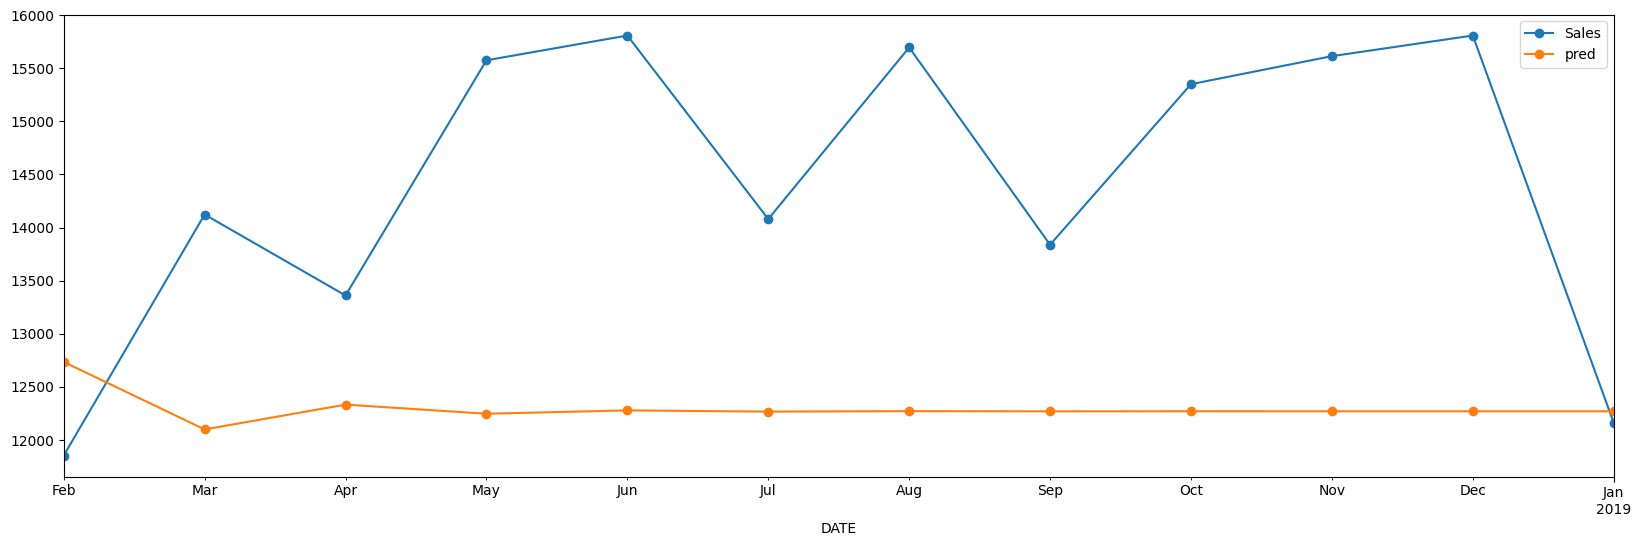

In [ ]:
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

This is not performing that well. Let's see what the optimal value for order should be by looking at PACF plot.

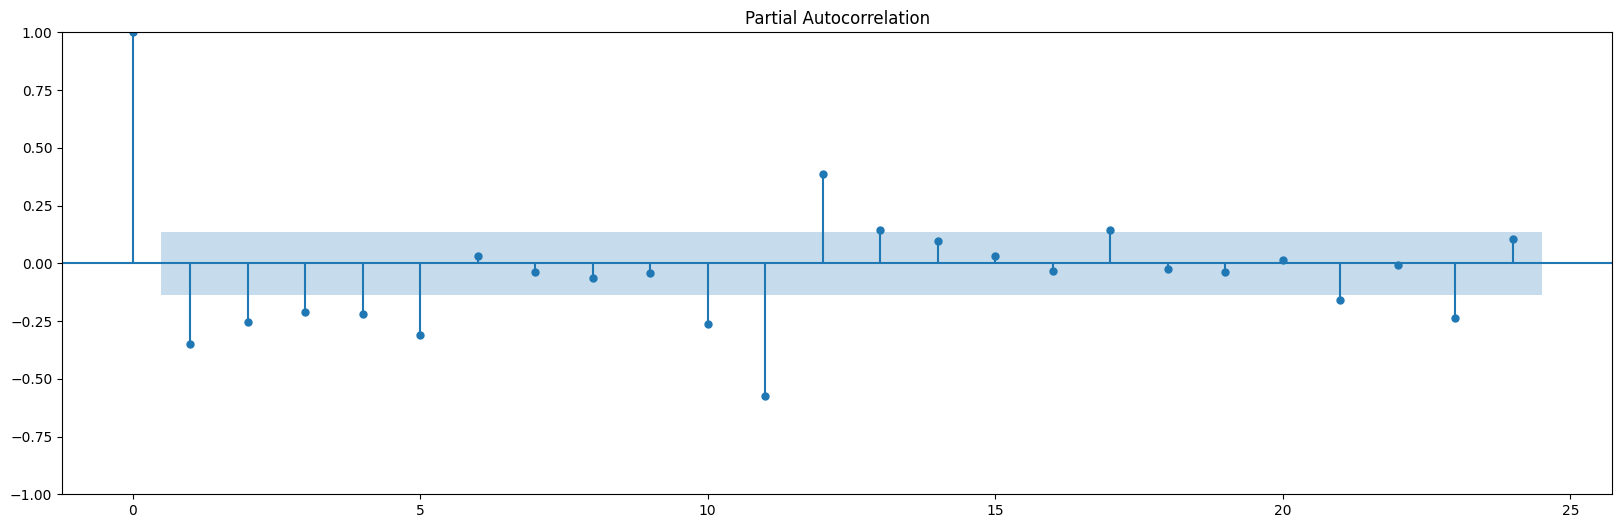

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plot_pacf(train_x_st.Sales);

From here, we see the best value is 3.
- Note that -ve is also significant.
- Here it could also be 4-5, but taking a conservative number to avoid overfitting and keeping the model simpler.
- later correlations maybe due to some more left over seasonality.

Lets try that

MAE : 1647.061
RMSE : 1890.003
MAPE: 0.11


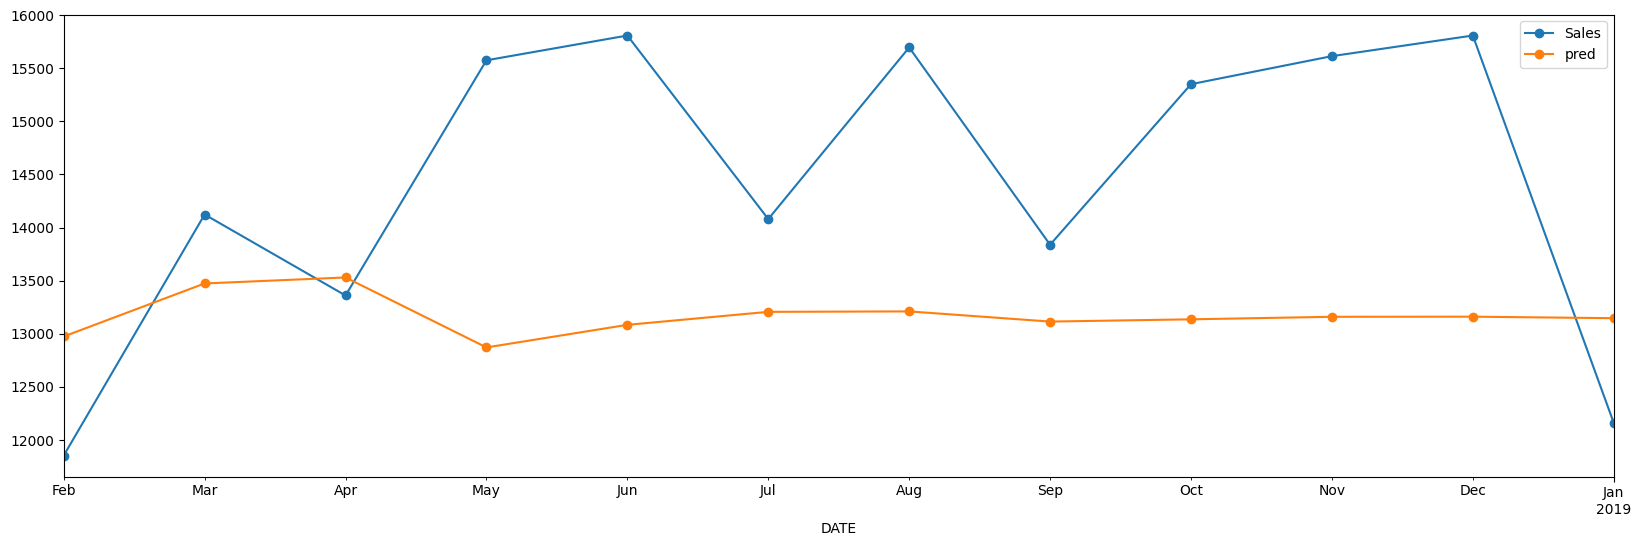

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(3, 0, 0))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

# Integrating the trend back!
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

# Plotting
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

## MA Model
the moving average model, states that the current value is linearly dependent on the current and past error terms.

The error of each data point in the series from the mean/average, would be different.

This should also work, as we are able to successfully create a new feature that is unique for each point.

In fact, this idea is called the Moving Averages (MA) technique.

> Though the name is same as the smoothing technique, we looked at before, this has nothing to do with that, and is a completey different concept.
- A moving average model is used for forecasting future values, while moving average smoothing is used for estimating the trend-cycle of past values.

**we'll see the equation and then see how does it work**

just like the AR equation which is in turn a linear regression equation we can see that
- we have our intercept $\mu$
- aur coefficients or our weights $\theta$
- and instead of previous values like in AR we will use the previous errors
- this will continue till q like in AR we continued till p which is our hyperparameter

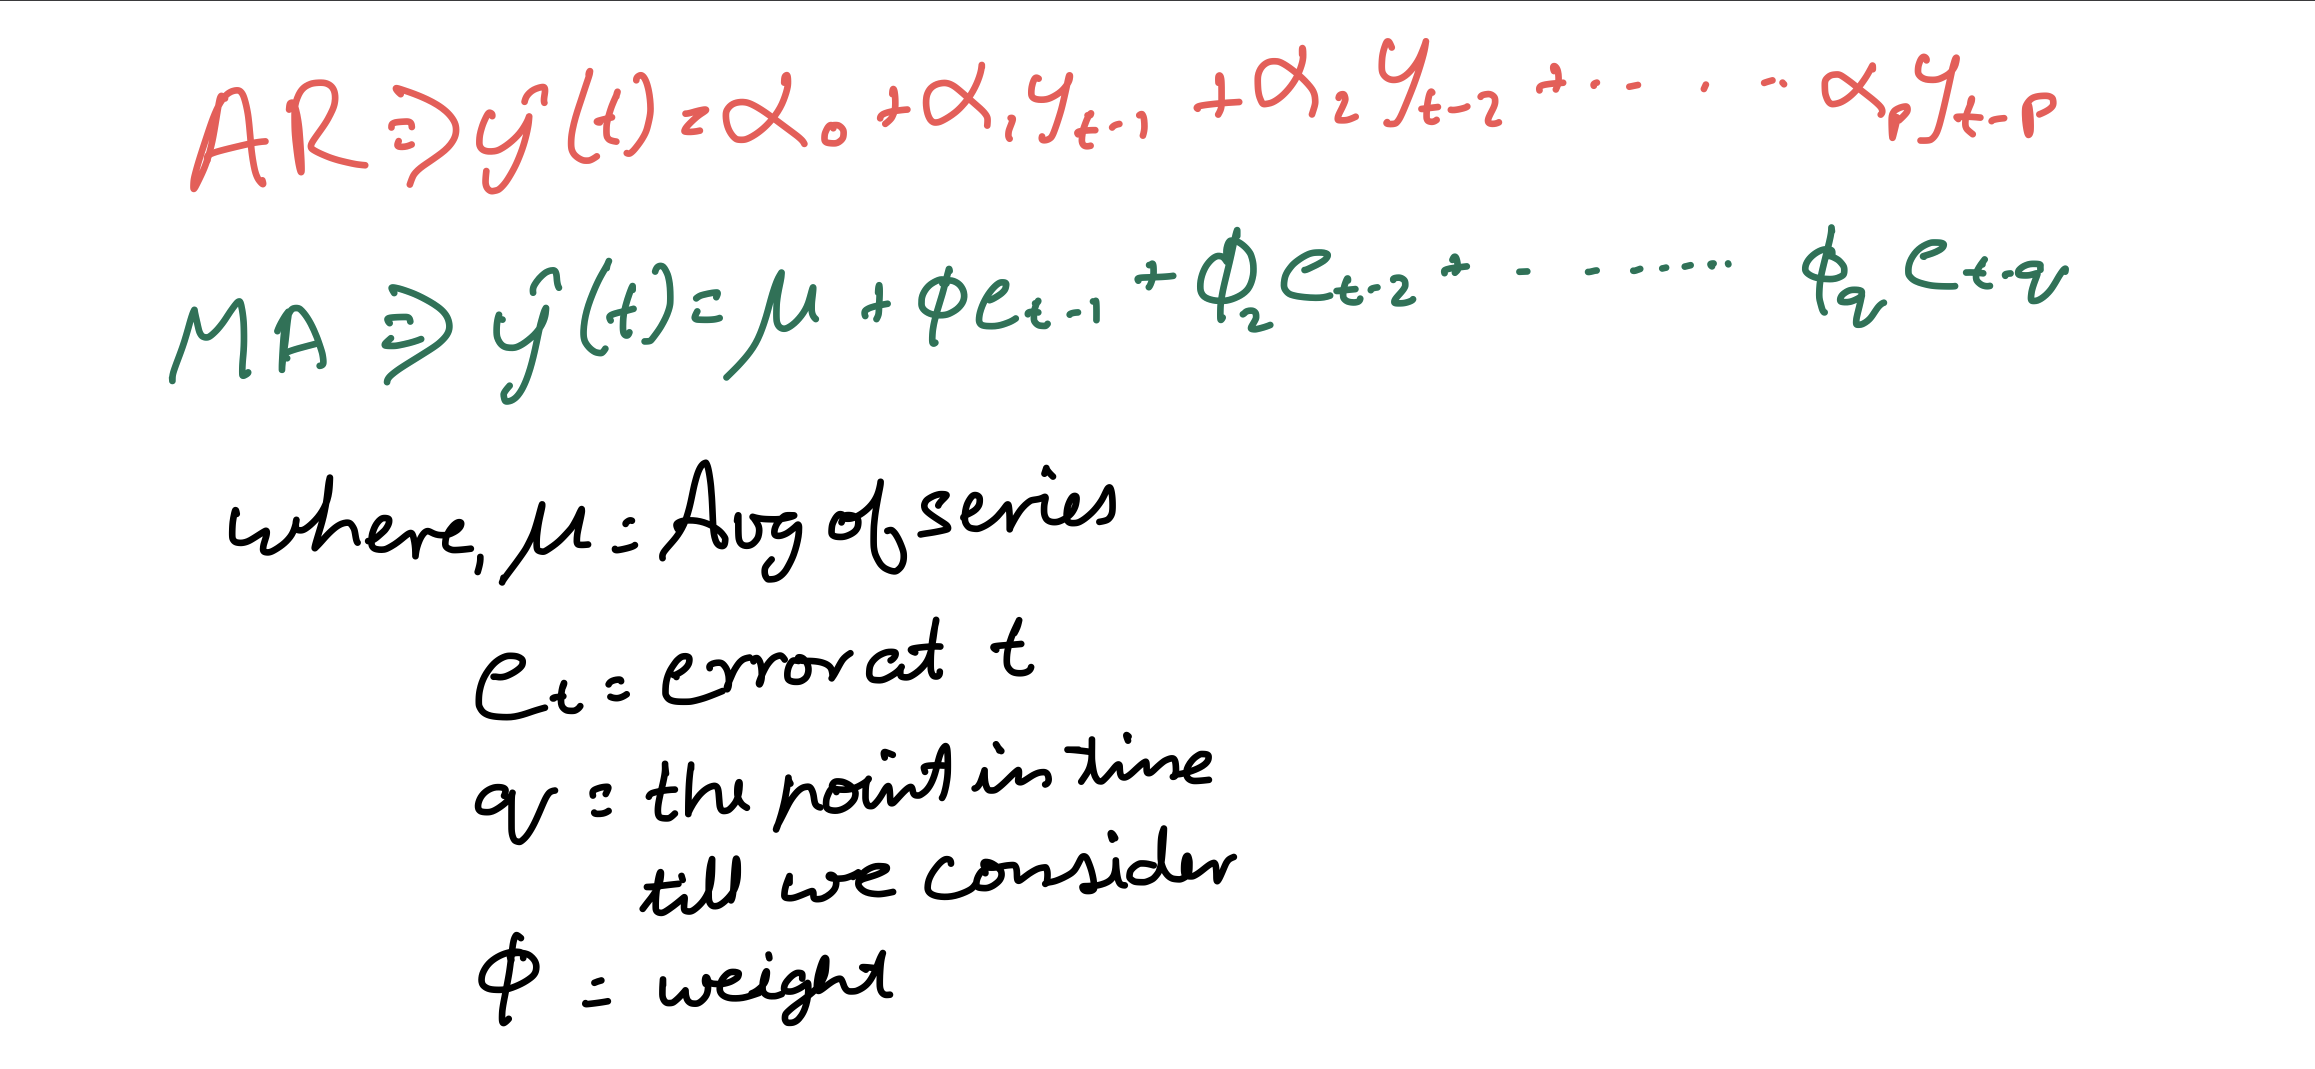

instead of looking on the previous values of forecvast what we will do is we will focus on the errors for the previous forecasts

> **lets start by understanding what do we nean by moving avegae here**

we will have an average of our time series and according to the errors in the predictions we will move around it


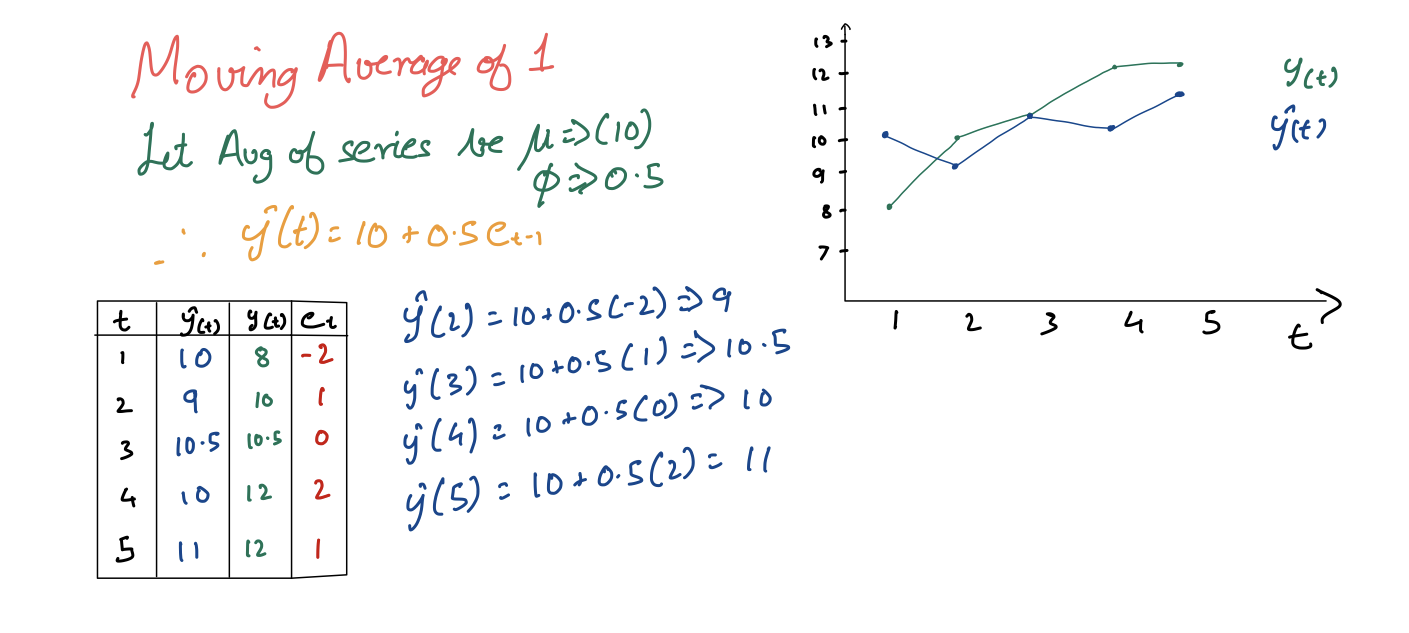

- what we are basically doing is we are starting with a base prediction which is our average of the series and then correcting it based on the previous errors
- MA models are useful for tackeling external factors which effect our series, because we take in account the errors that occur due to them

### finding value of q

like we did while finding the value of p with pacf plot we plot acf and then get the lag number of significant lines

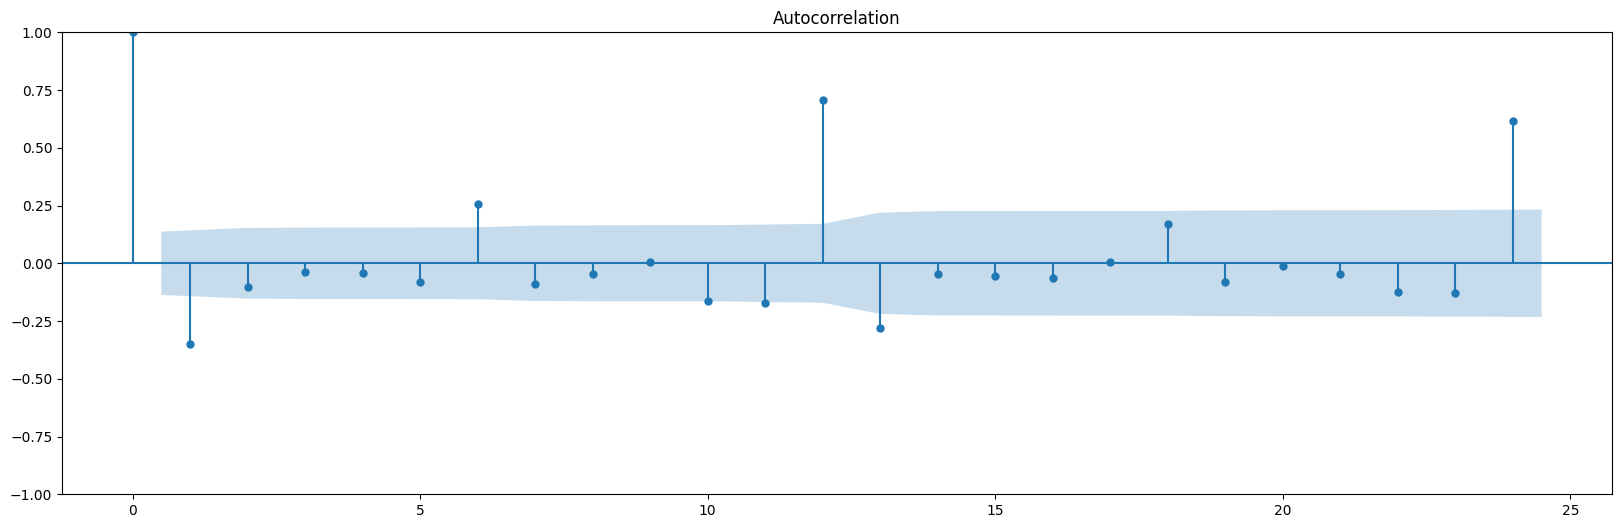

In [ ]:
plot_acf(train_x_st.Sales);

> How can we implement MA in code?

The same way as AR.

Only, the order in which we give value to order changes.

Now, we make the first value in tuple as 0, indicating that we do not want any AR, and we specify the order in the third value as the order for MA.

Let's plot it and see

MAE : 1362.947
RMSE : 1558.015
MAPE: 0.093


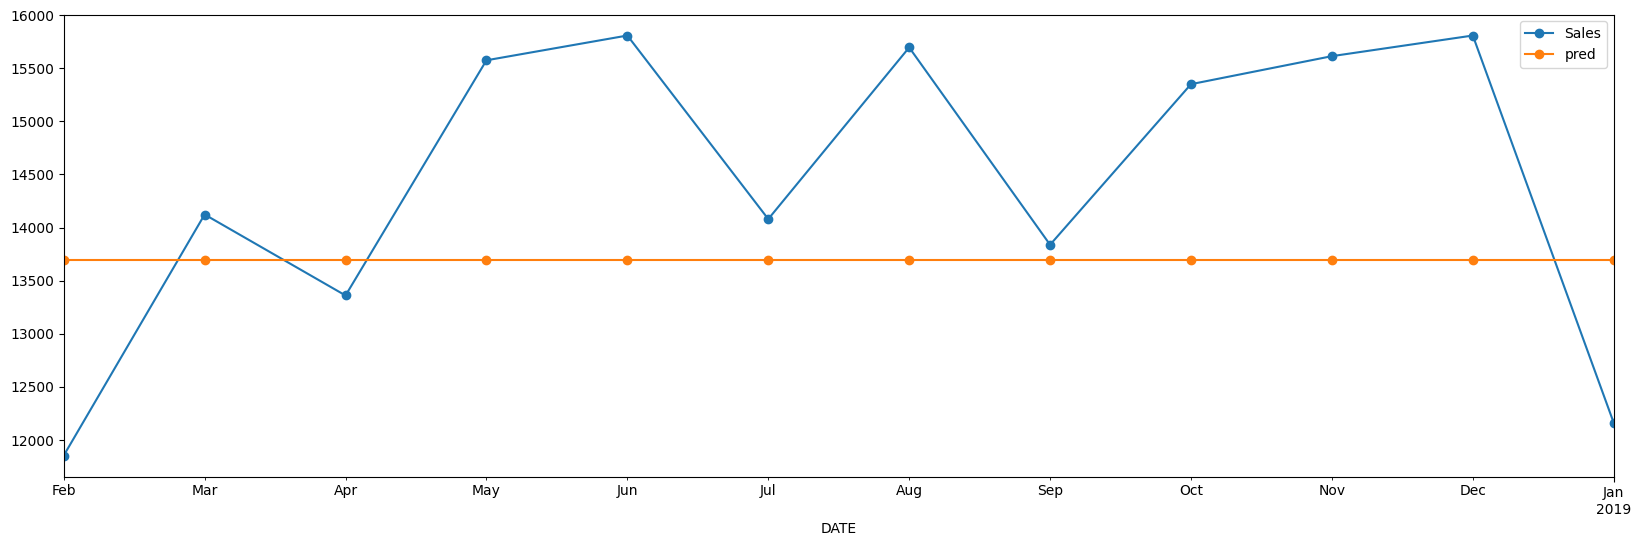

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(0, 0, 1))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

> MA models are mostly not used independently it is often combined with the AR model for better prediction

## 3. Auto Regression - Moving Averages (ARMA)

This is a model that is combined from the AR and MA models. In this model, the impact of previous lags along with the errors/residuals is considered for forecasting the future values of the time series.

- because we take in account for the previous lags as well as the errors that may be there, we can build a highly accurate model

While combining these two ideas,
- `p`: order of AR  
- `q`: order of MA

 - `p` may or may not be equal to `q`

- Here, `p` and `q` are **hyperparameters**
- Hence it is also called as **ARMA(p,q) Model**.

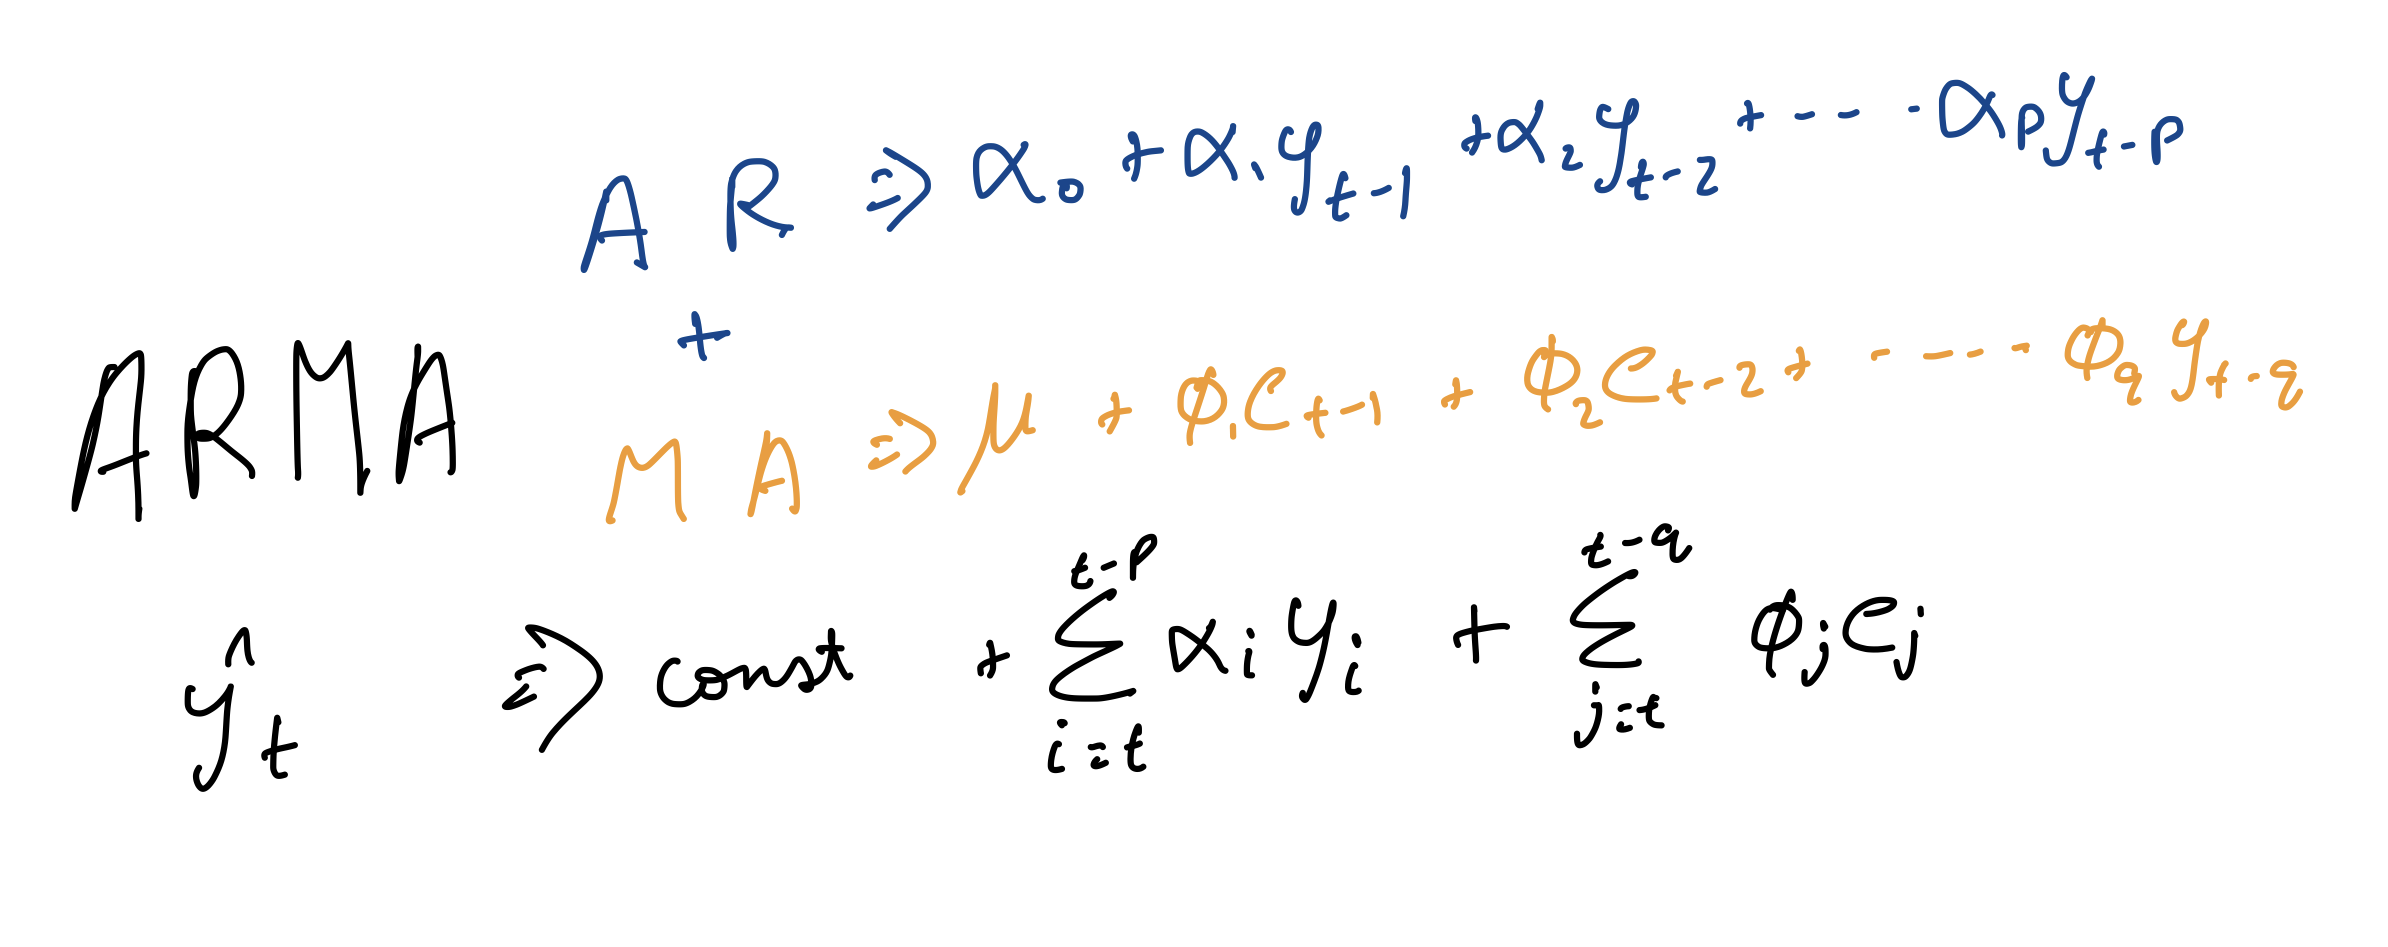

### Finding p,q values

Exactly same as for AR, MA models
- **the values from the plots may not always be easy to interpret in real life and requires some hit and trial as well for selecting the actual values for all these models**

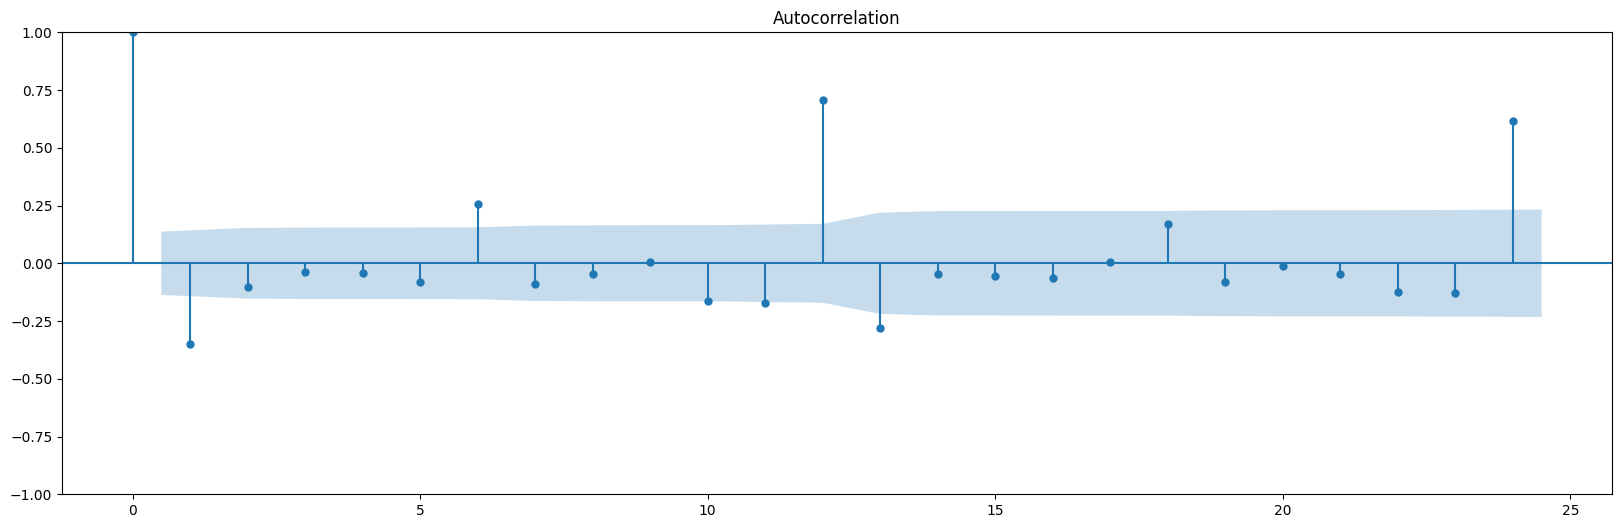

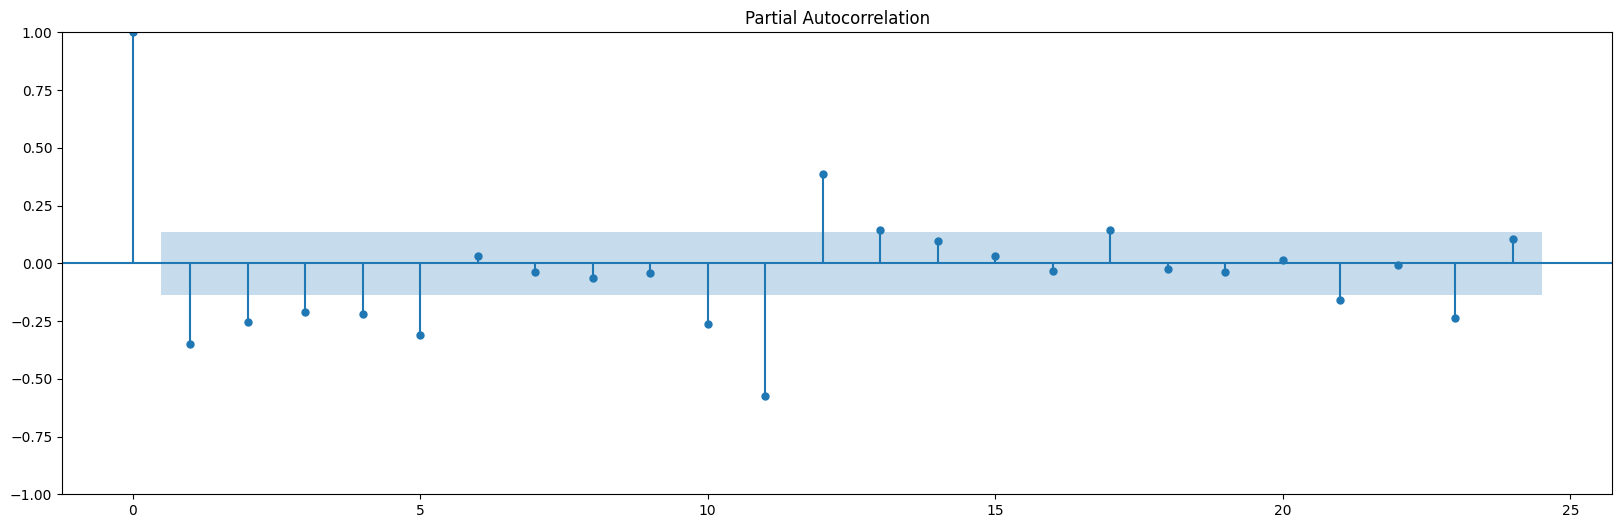

In [ ]:
plot_acf(train_x_st.Sales);
plot_pacf(train_x_st.Sales);

MAE : 1355.315
RMSE : 1523.819
MAPE: 0.092


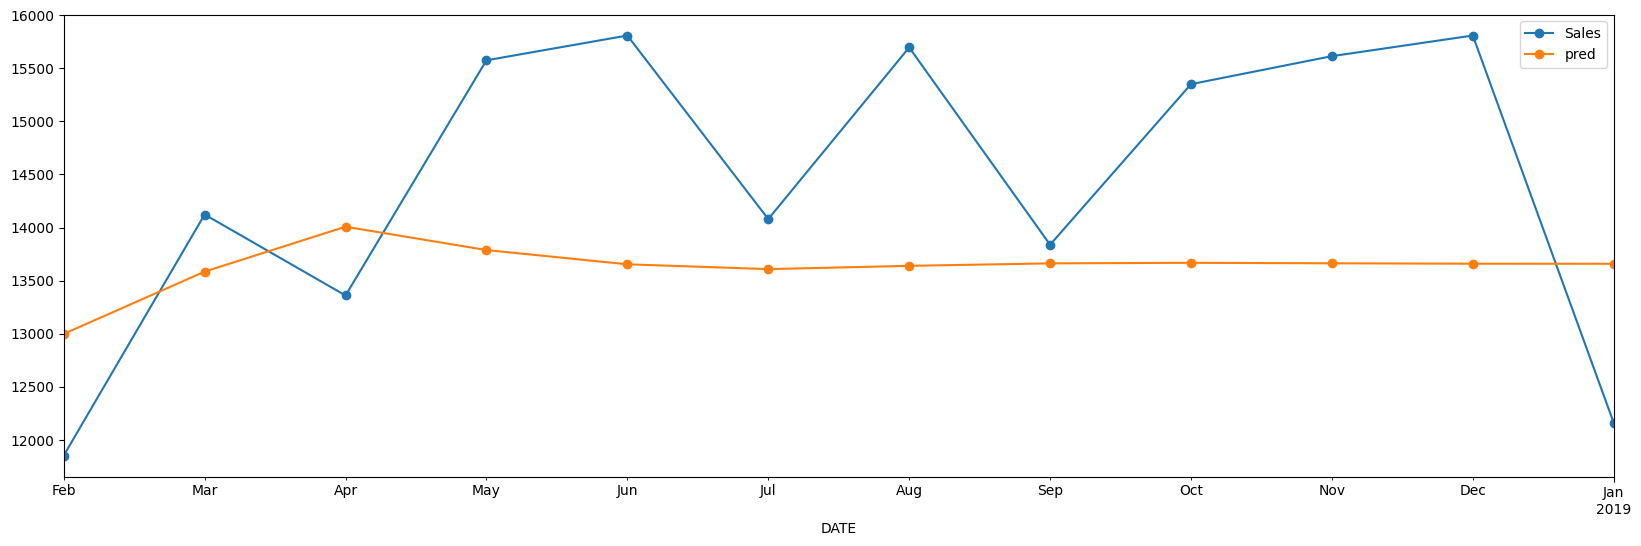

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(3, 0, 1))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

- Let us try some more values and see if we can get a better result

MAE : 1041.707
RMSE : 1271.736
MAPE: 0.07


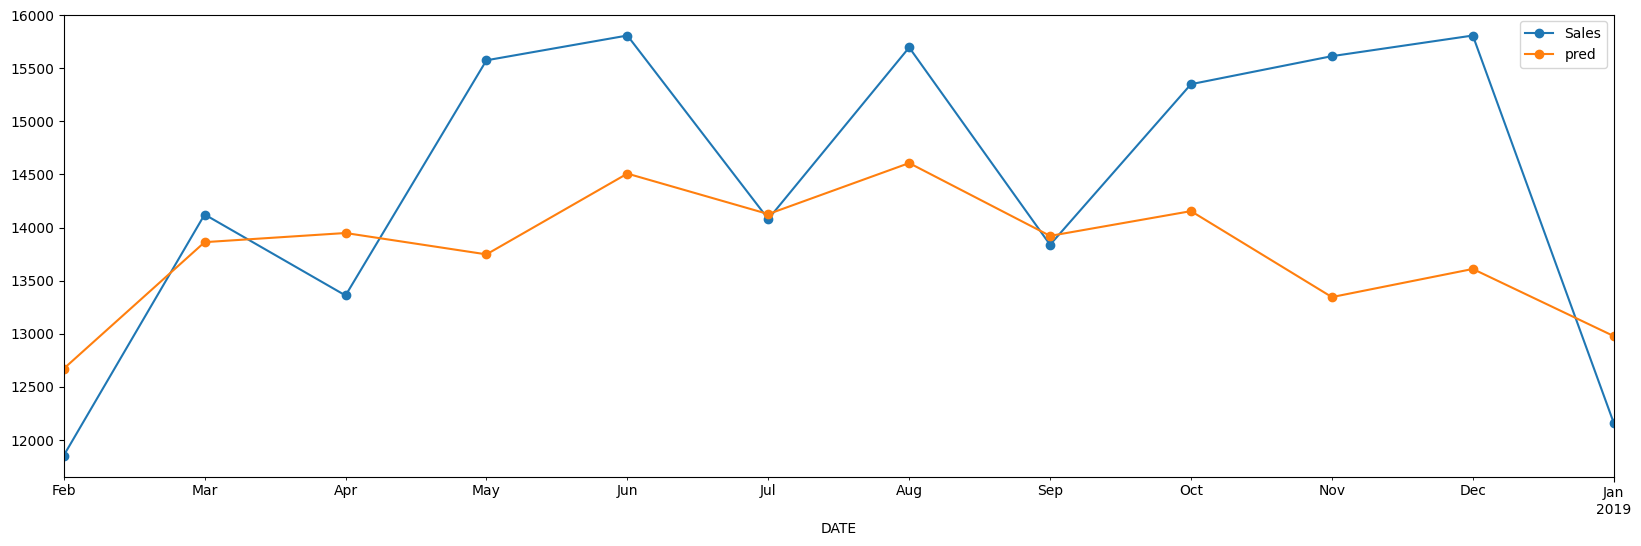

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(3, 0, 6))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

- We definetly see a lot of improvement over our last result
- We increased the q vale to 6 because we saw some significant rise in the acf plot there
- if you look closely that we can see that multiple of 6 have higher significant level then others
- this may be because we have some seasonality left in the data

**Limitation of ARMA**

Requires the series to be stationary

#### **Quiz-3:**

```
Which is not a hyperparameter in the ARMA model?

a. Order of auto-regression
b. Order of Differencing
c. Order of Moving Averages
d. None of them

```
Answer: b -  Order of Differencing  

---

## 4. ARIMA

> **What if we do not have a stationary time series?**

In such a case,
 * We perform **differencing** to de-trend
 * Then we apply the ARMA technique, to get an approximation.
 * Now to get a good forecast, we need to **integrate** the trend **back** to get the final result


That is ARIMA, where

AR= Auto Regressive

I= integrated

MA= Moving Average

ARIMA,  actually  ‘explains’ a given time series based on its own past values (like AR), that is, its own lags and the lagged forecast errors(like MA)

We already know how AR and MA work

the only new thing here is I intergrated part.

- very simply what it does is it differentiates the series for us, makes it stationary
- calculate forecast based on arma model
- integrate it back to get forecast on the original series

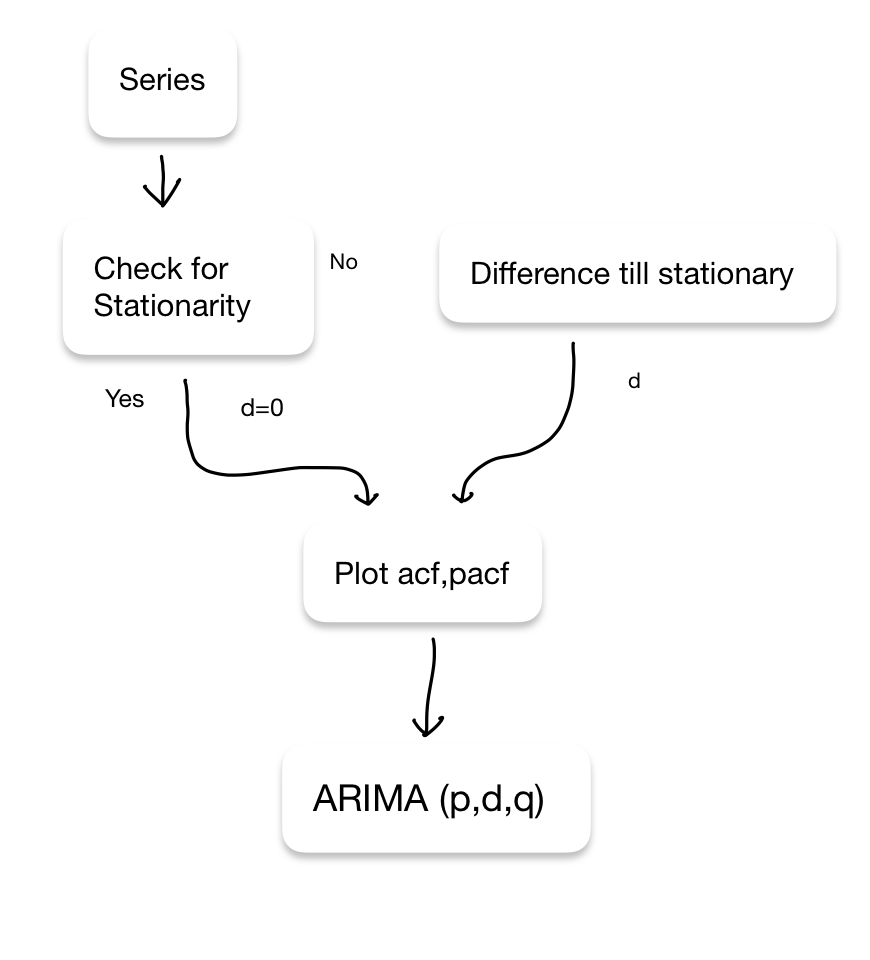

lets find the value of d with differencing
- we can see that it becomes stationary at diff of 1

In [ ]:
train_x_st = train_x.copy()
train_x_st.Sales = train_x_st.Sales.diff(1)
train_x_st.dropna(inplace=True)
adf_test(train_x_st.Sales)

Sequence is stationary


MAE : 998.652
RMSE : 1120.978
MAPE: 0.07


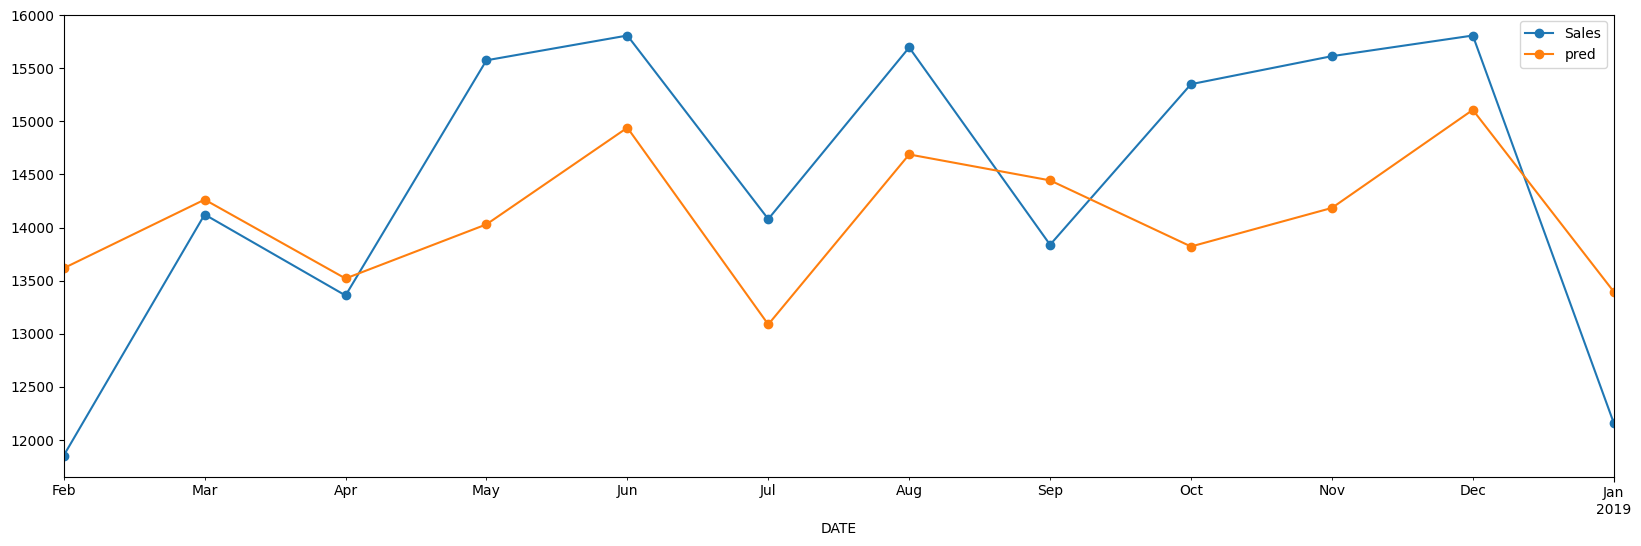

In [ ]:
model = SARIMAX(train_x_st.Sales, order=(3, 1, 6))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)

test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

**A problem with ARIMA is that it does not support seasonal data.**

ARIMA expects data that is either not seasonal or has the seasonal component removed, e.g. seasonally adjusted via methods such as seasonal differencing.

## 5. SARIMA

Seasonal Autoregressive Integrated Moving Average, SARIMA or Seasonal ARIMA, is an extension of ARIMA that explicitly supports univariate time series data with a seasonal component.

If we wish to account for seasonality without SARIMA, the process becomes:-
- first differentiating $(x[i] - x[i-T])$, to remove seasonlity,
- then performing AR and MA,
- then integrating the seasonality back,

This is very tiring.

Instead of doing so much work to utilise the ARIMA model, we can just apply another model called :the **SARIMA model** directly.

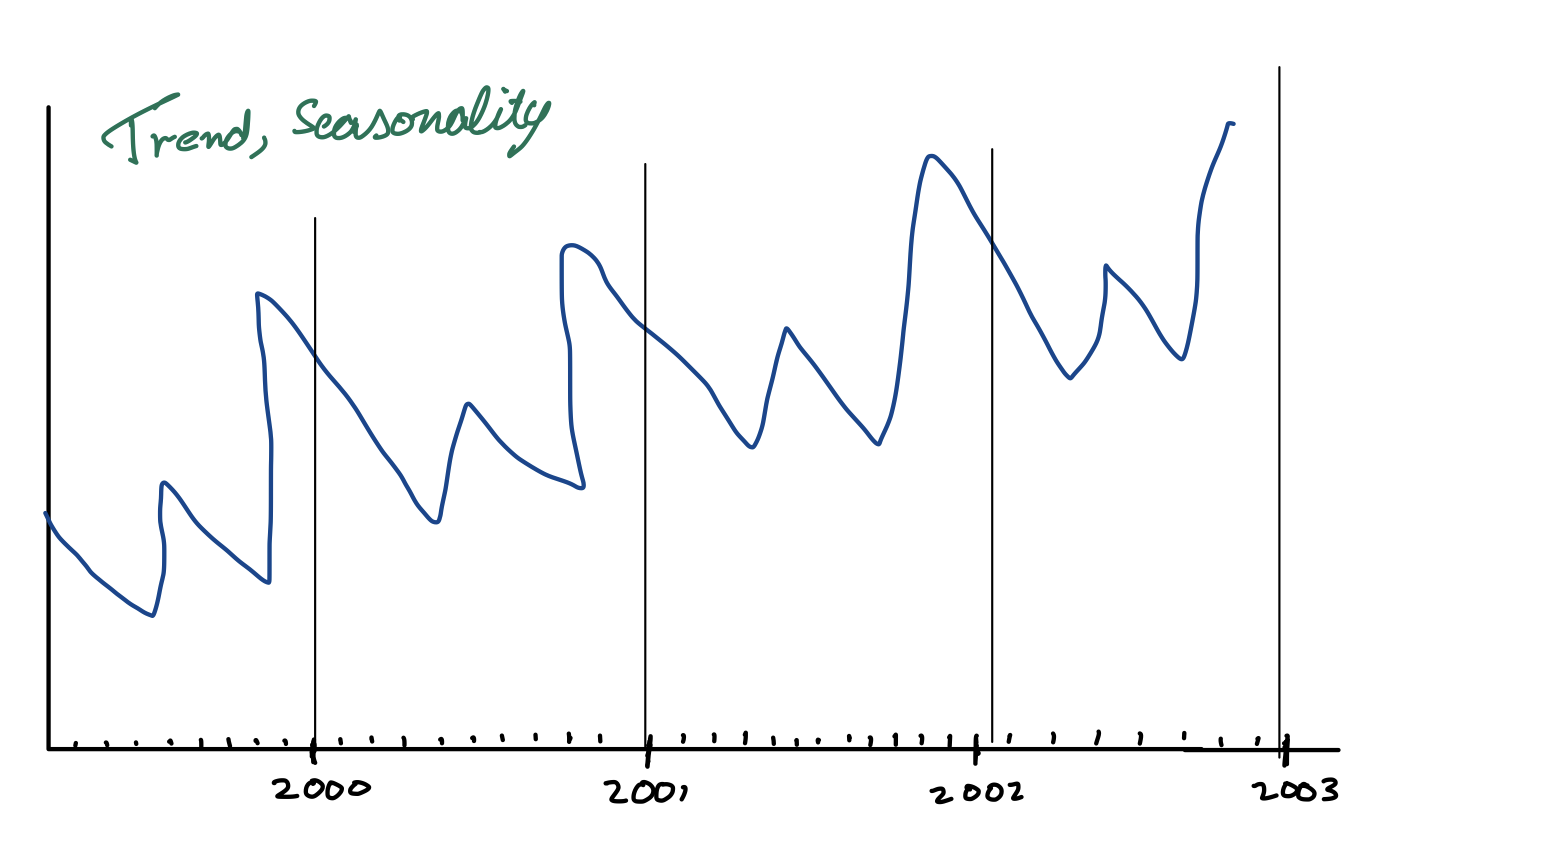


It adds three new hyperparameters to specify the autoregression (AR), differencing (I) and moving average (MA) for the seasonal component of the series, as well as an additional parameter for the period of the seasonality.

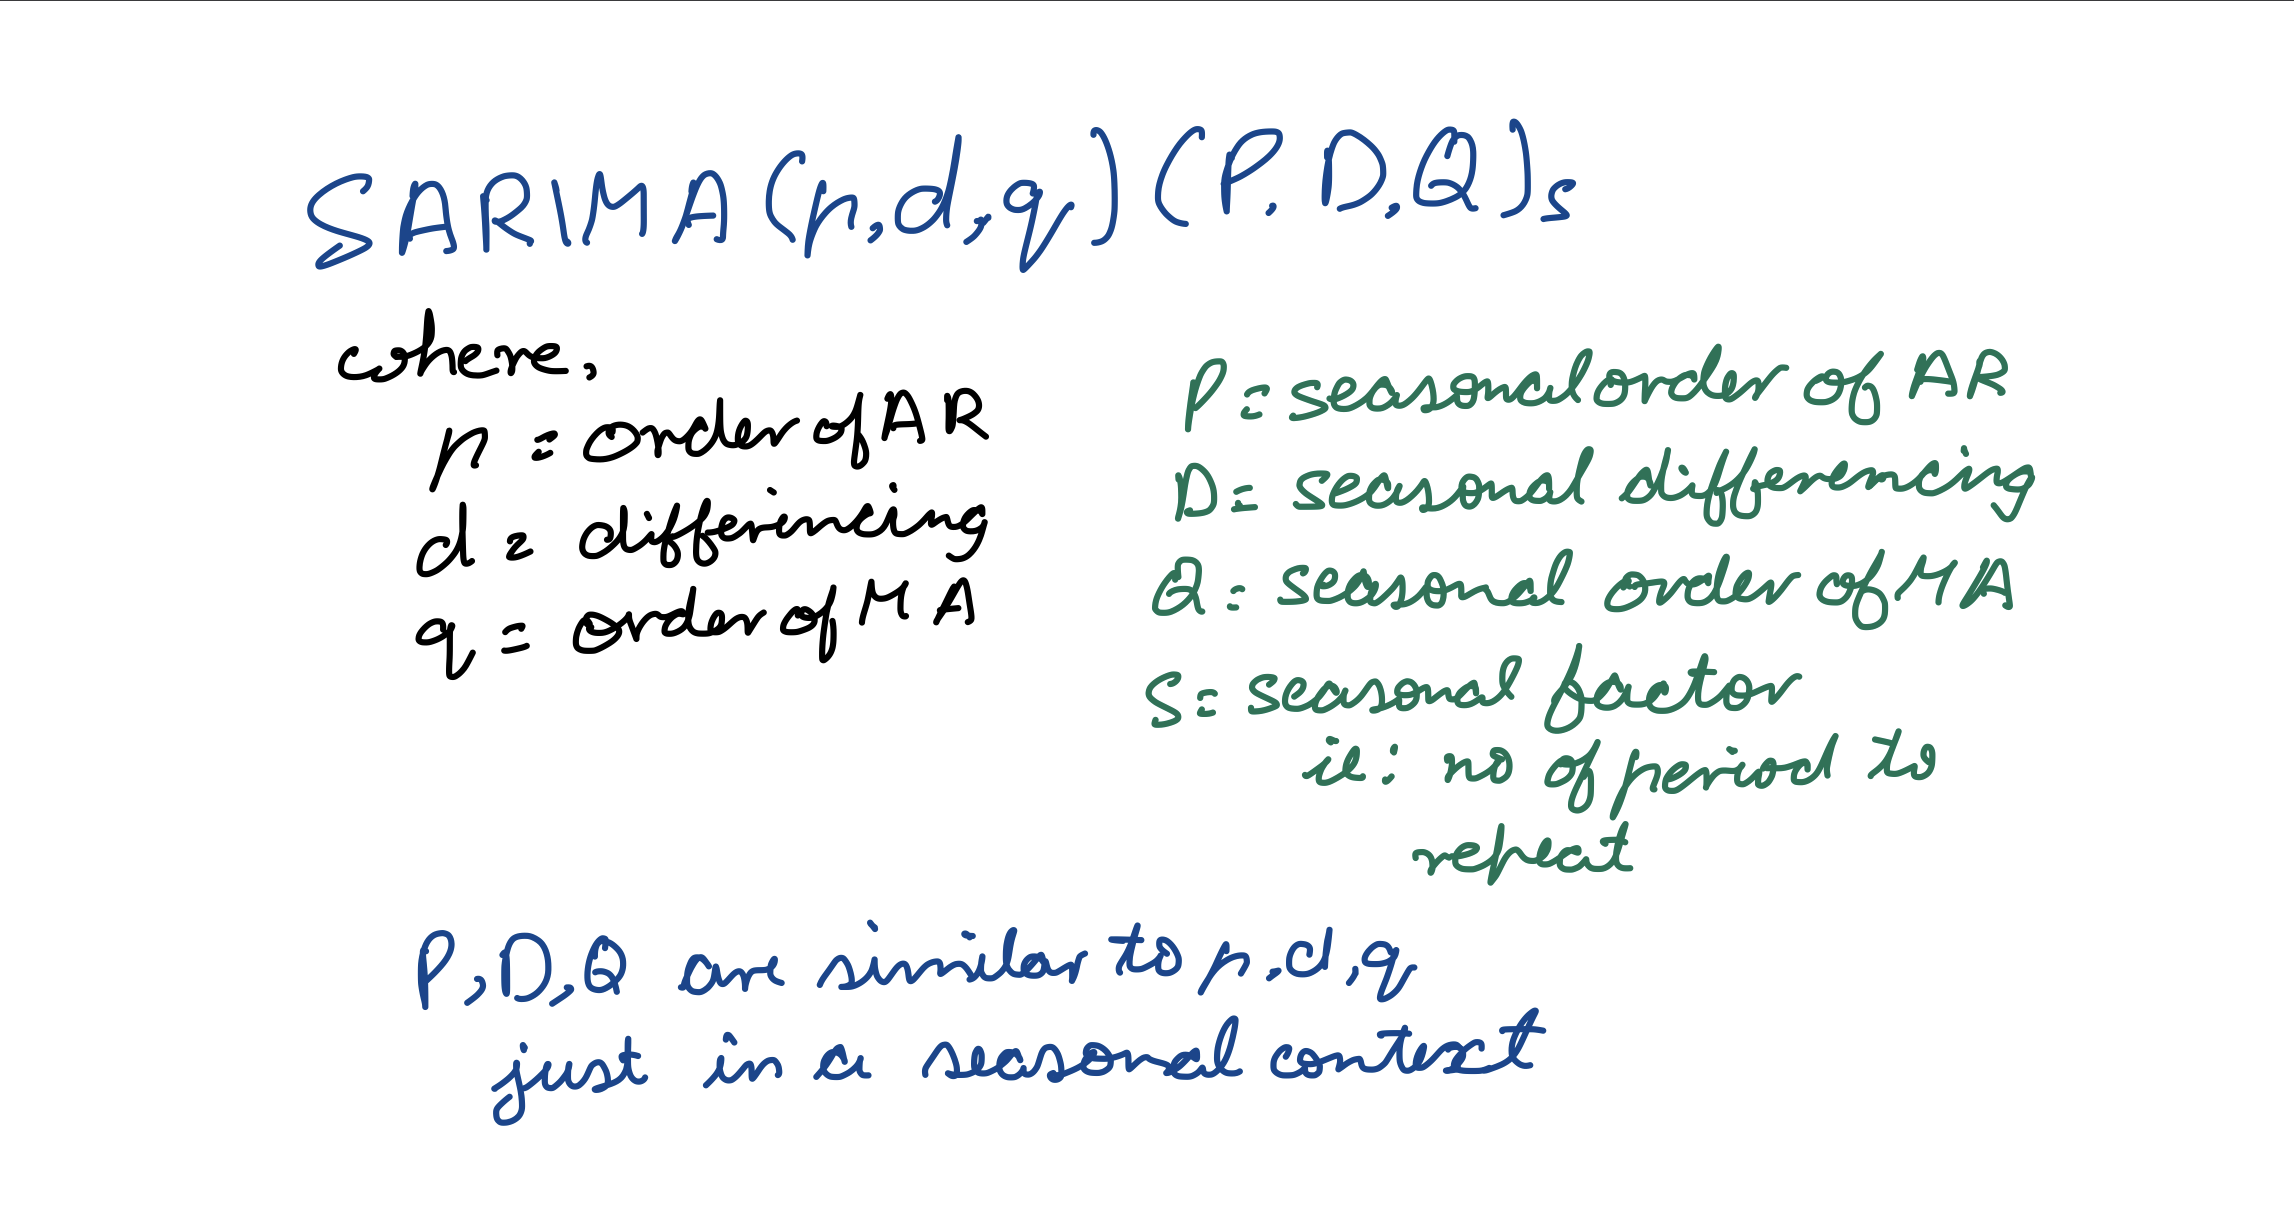

A seasonal ARIMA model is formed by including additional seasonal terms in the ARIMA. The seasonal part of the model consists of terms that are very similar to the non-seasonal components of the model, but they involve backshifts of the seasonal period.

**Trend Elements**

There are three trend elements that require configuration.

They are the same as the ARIMA model; specifically:

- p: Trend autoregression order.
- d: Trend difference order.
- q: Trend moving average order.

**Seasonal Elements**

There are four seasonal elements that are not part of ARIMA that must be configured; they are:

- P: Seasonal autoregressive order.
- D: Seasonal difference order.
- Q: Seasonal moving average order.
- s: The number of time steps for a single seasonal period.

Together, the notation for an SARIMA model is specified as:

**SARIMA(p,d,q)(P,D,Q)s**

### Understanding the new terms

- **D Seasonal diffrence order** A seasonal ARIMA model uses differencing at a lag equal to the number of seasons (s) to remove additive seasonal effects. As with lag 1 differencing to remove a trend, the lag s differencing introduces a moving average term. The seasonal ARIMA model includes autoregressive and moving average terms at lag s.

- **P Seasonal autoregressive order** This will understand the seasonal aspect of the series. Giving importance to the lags on the basis of seasonality

- **Q: Seasonal moving average order** this will take the help of errors in the seasonal aspect of the series

### Finding the new order

Besides specifying values for the order parameter, we also need to add values for the seasonal_order parameter.

Like we did for ARIMA we will plot the acf,pacf plots again
- this time we will try to look for seasonality in the plots and check significant lags based on that

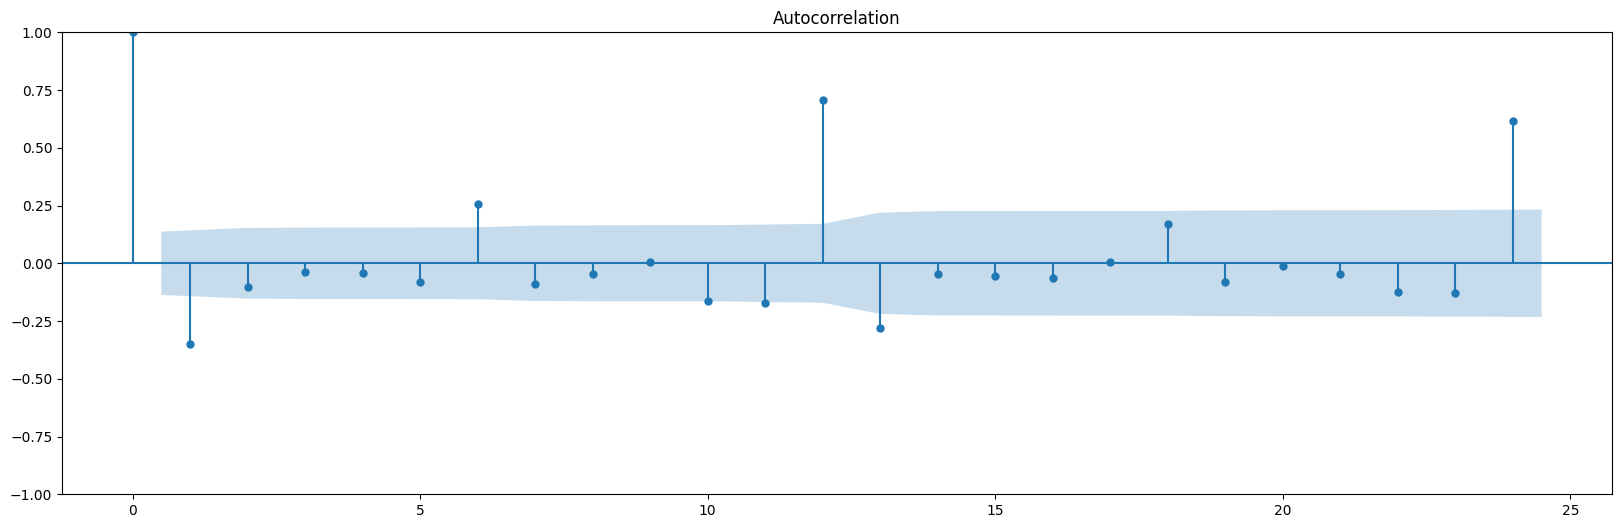

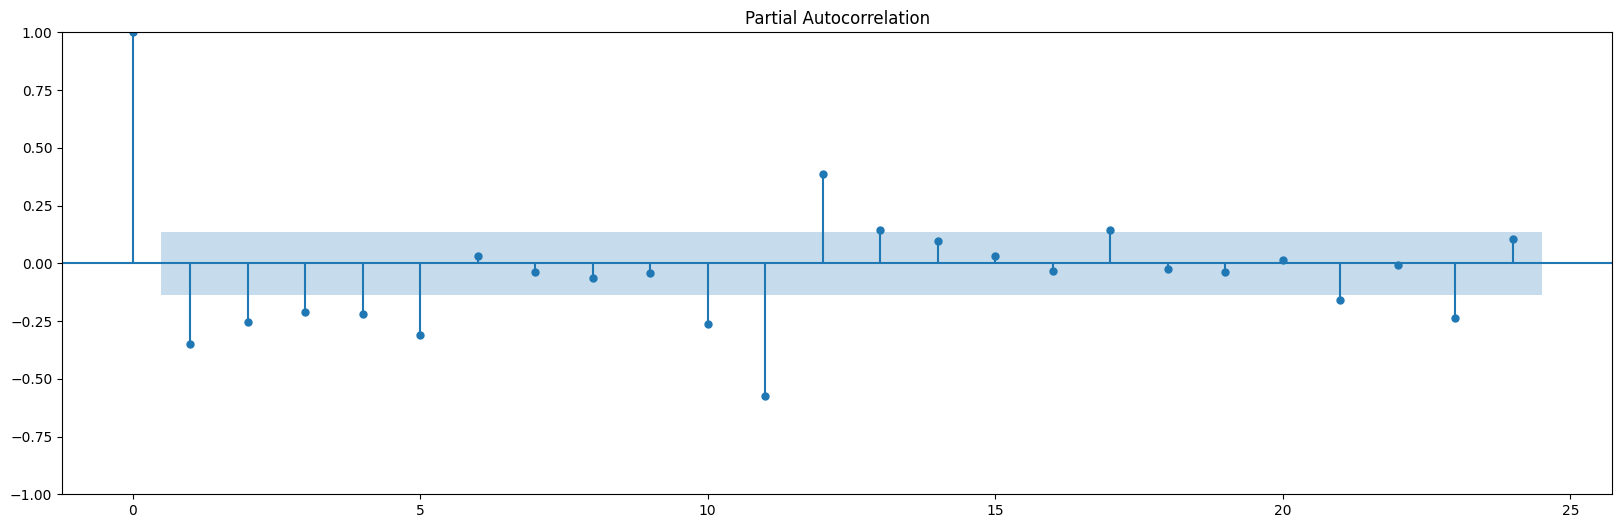

In [ ]:
plot_acf(train_x_st.Sales);
plot_pacf(train_x_st.Sales);

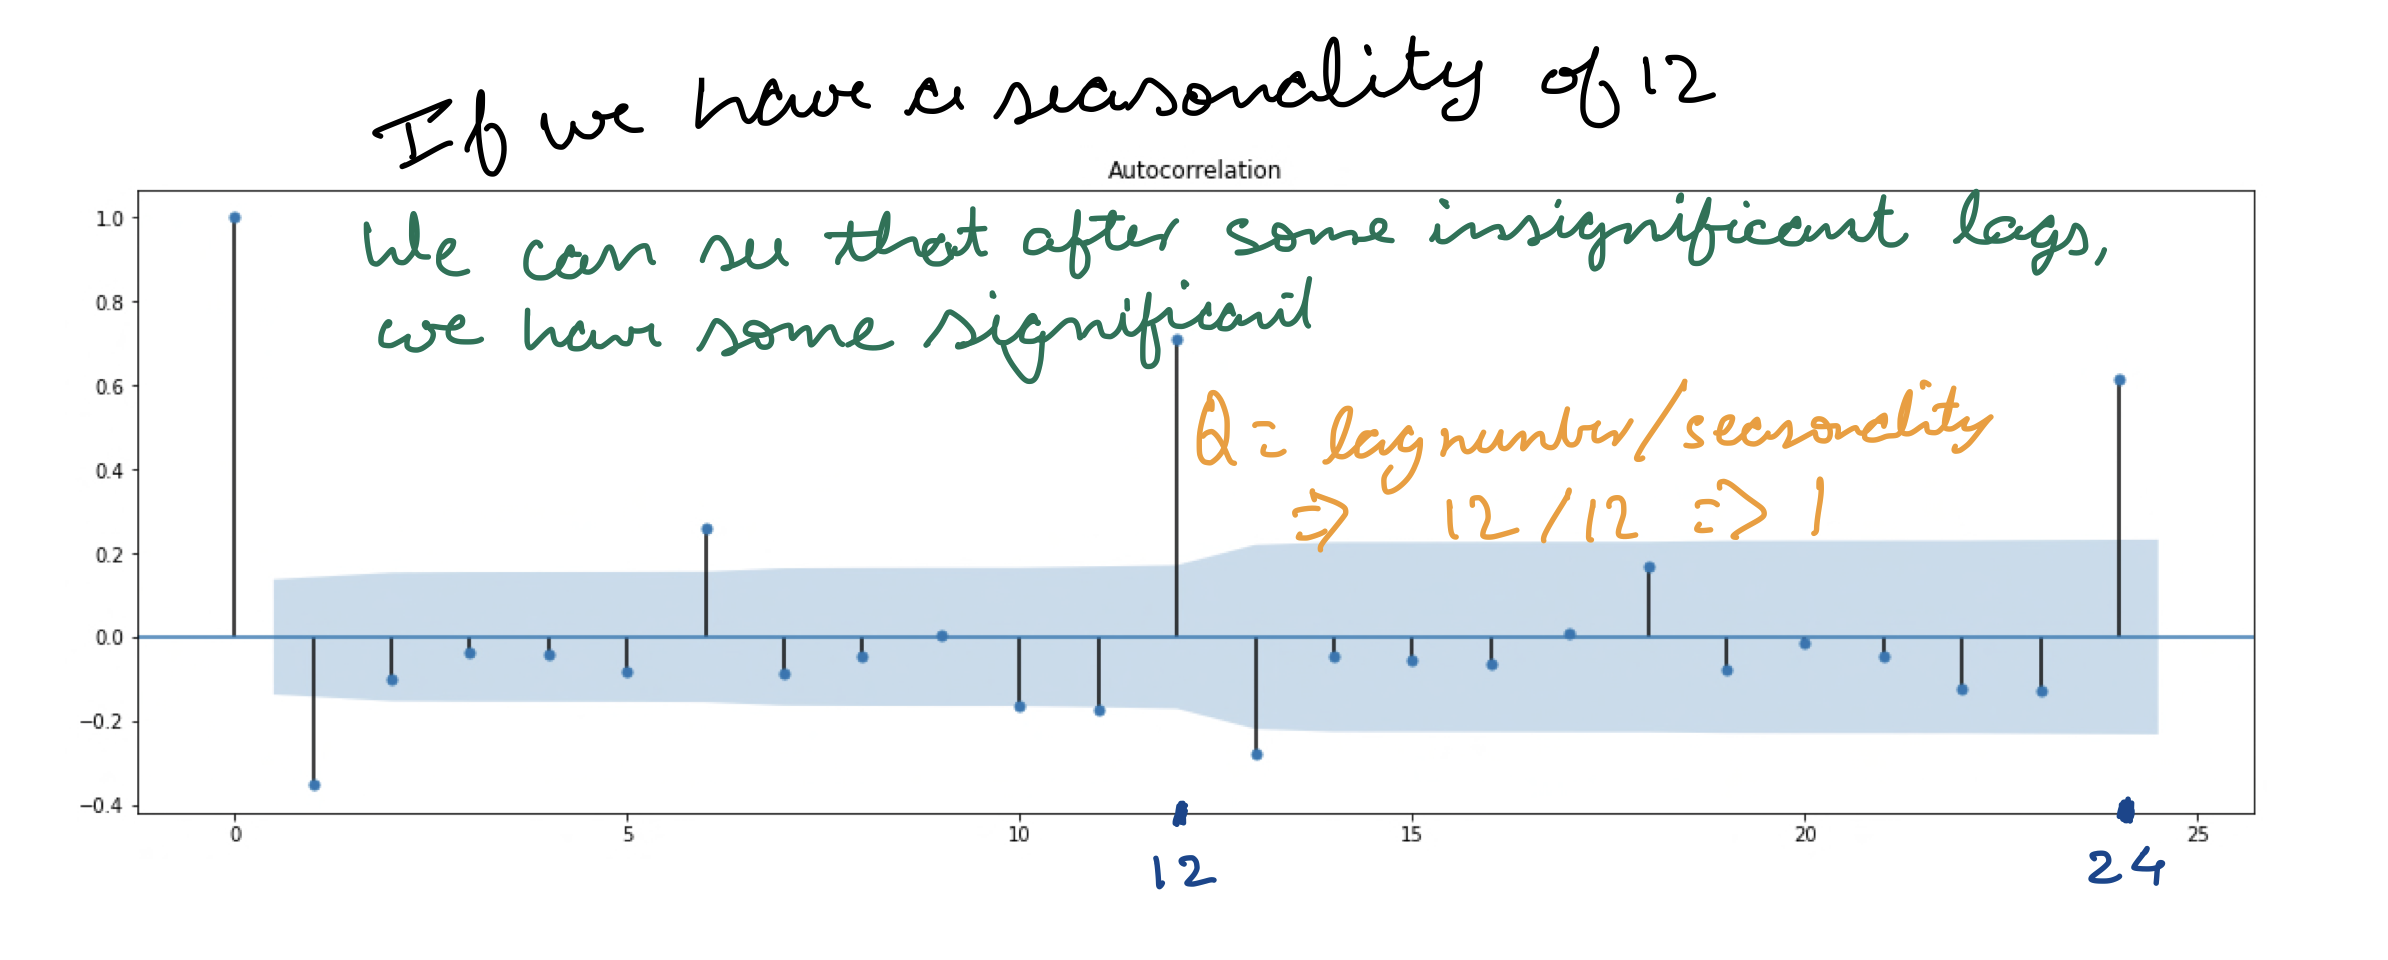

in our case we can say
- s=12
- D=1
- P=1
- Q=1

MAE : 536.809
RMSE : 622.984
MAPE: 0.037


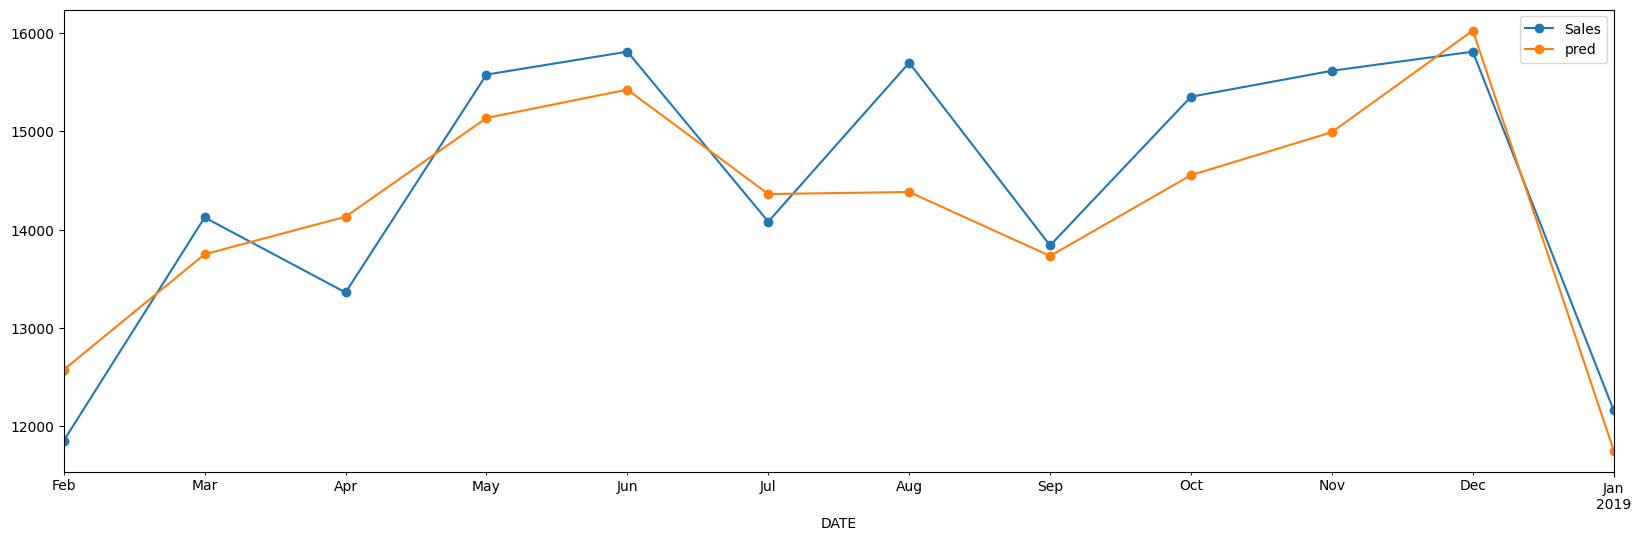

In [ ]:
model = SARIMAX(train_x.Sales, order=(3, 1, 3), seasonal_order=(1,1,1,12))
model = model.fit(disp=False)
test_x['pred'] = model.forecast(steps=12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

## Prediction Intervals

Prediction intervals are used to provide a range where the forecast is likely to be with a specific degree of confidence. a prediction interval defines the interval within which the true value of the response variable is expected to be found with a given probability. By using a prediction interval you can account for uncertainty in the forecast, and the random variation of the data.

Owing to the potential error of our forecast, and unpredictability of future, we cannot claim to be a hundred percent sure of our forecasts.

- But we can still, based on our study of time series, say that the future value, would lie in the range of [A,B].

- Naturally A becomes the minimum possible value of our target variable at time t, and

- B becomes the maximum possible value at time t.

Prediction intervals provide an upper and lower expectation for the real observation.
This [A,B] becomes a range for determining the real possible value for a certain prediction.

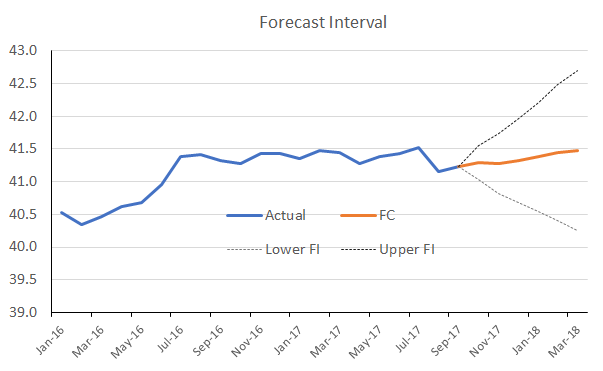

Let's use the returned upper and lower bound values of each forecast using the function `conf_int` to create separate series for lower and upper bounds for visualization purpose.

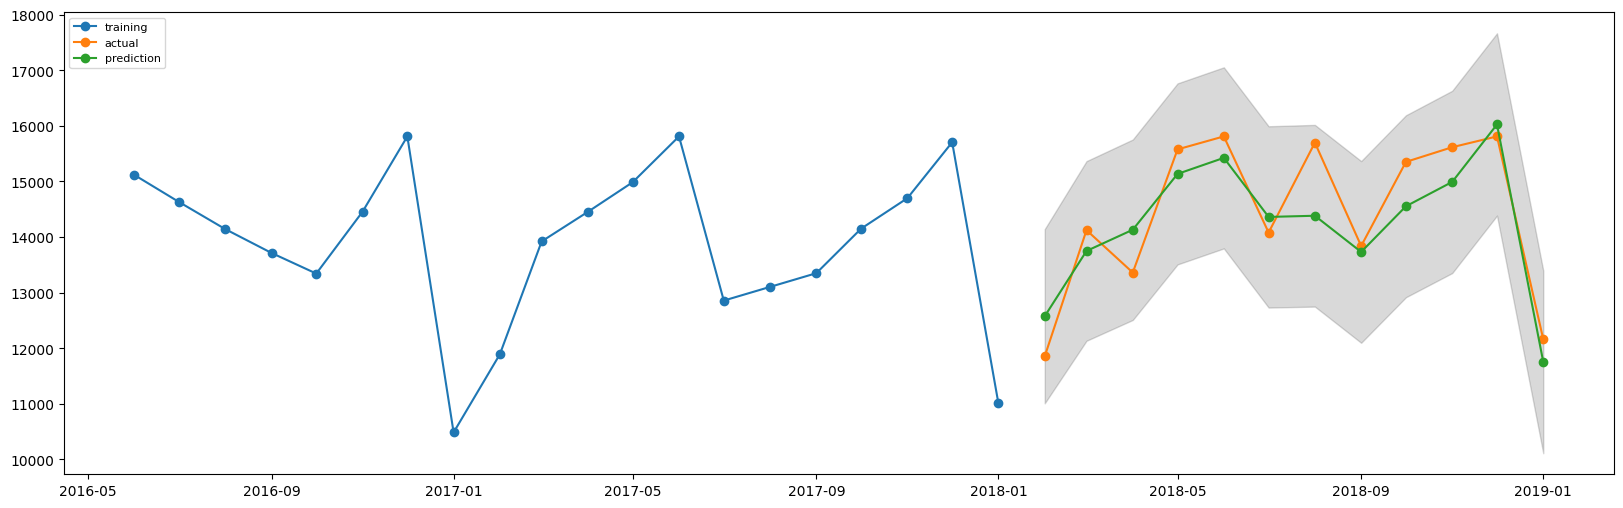

In [ ]:
test_x[['lower', 'upper']] = model.get_forecast(steps=12).conf_int(0.05).values
plt.plot(train_x['Sales'][-20:], '-o', label='training')
plt.plot(test_x['Sales'], '-o', label='actual')
plt.plot(test_x['pred'], '-o', label='prediction')
plt.fill_between(test_x.index, test_x['lower'], test_x['upper'],
                 color='k', alpha=.15)
plt.legend(loc='upper left', fontsize=8)
plt.show()

# Case study
Imagine you are a Data Scientist at a food chain ‘Xotica’!

Your manager has asked you to forecast the number of visitors for upcoming 39 days (almost 6 weeks) using the number of visitors recorded within the past 1-1.5 years.


**`Instructor Note`**:
- Cover the below case study if time permits else explain below topics and share the colab notebook with them and ask them to go through it post lecture
Topics to be covered from the case study
  - Exogenous vairable
  - SARIMAX
  - Facebook Prophet

Reading the data

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20,8)

In [ ]:
!gdown 1Um8gdIjpEx7Iv-VUoBpmGCS80ck_x7AO

Downloading...
From: https://drive.google.com/uc?id=1Um8gdIjpEx7Iv-VUoBpmGCS80ck_x7AO
To: /content/rest_vis.csv
100% 13.1k/13.1k [00:00<00:00, 43.1MB/s]


In [ ]:
df = pd.read_csv('/content/rest_vis.csv')
df.head()

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [ ]:
df.shape

(517, 4)


The provided dataset has features `‘Date’, ‘holiday’, 'weekday' and 'total`(total no. of visitors).

The data consists of number of **daily** visitors to the restaurant located in the United States, subject to American holidays.

The data set contains 517 days: 478 days of restaurant's data and 39 days of data which have `Nan` in `total`.

Let's find out the number of rows having values 'Nan' in dataset.

In [ ]:
df.isna().sum()

date        0
weekday     0
holiday     0
total      39
dtype: int64

Here let's keep a copy of the original data so that in future, even after modifications on the data we won't have to read the csv again and again.

In [ ]:
df1 = df.copy()

Let's drop all the rows which have `Nan`.

In [ ]:
df.dropna(inplace = True)

Set the `date` column as index after converting it to datetime format.

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date',inplace = True)
df.head(5)

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


**NOTE:-**
- Here you can see, that the target variable of the time series is the ```total``` column.
- In our last business case, we saw only date and the target variable.
- However, there are other columns: ```holiday, weekday```.

<br>





#### Plot the source data.

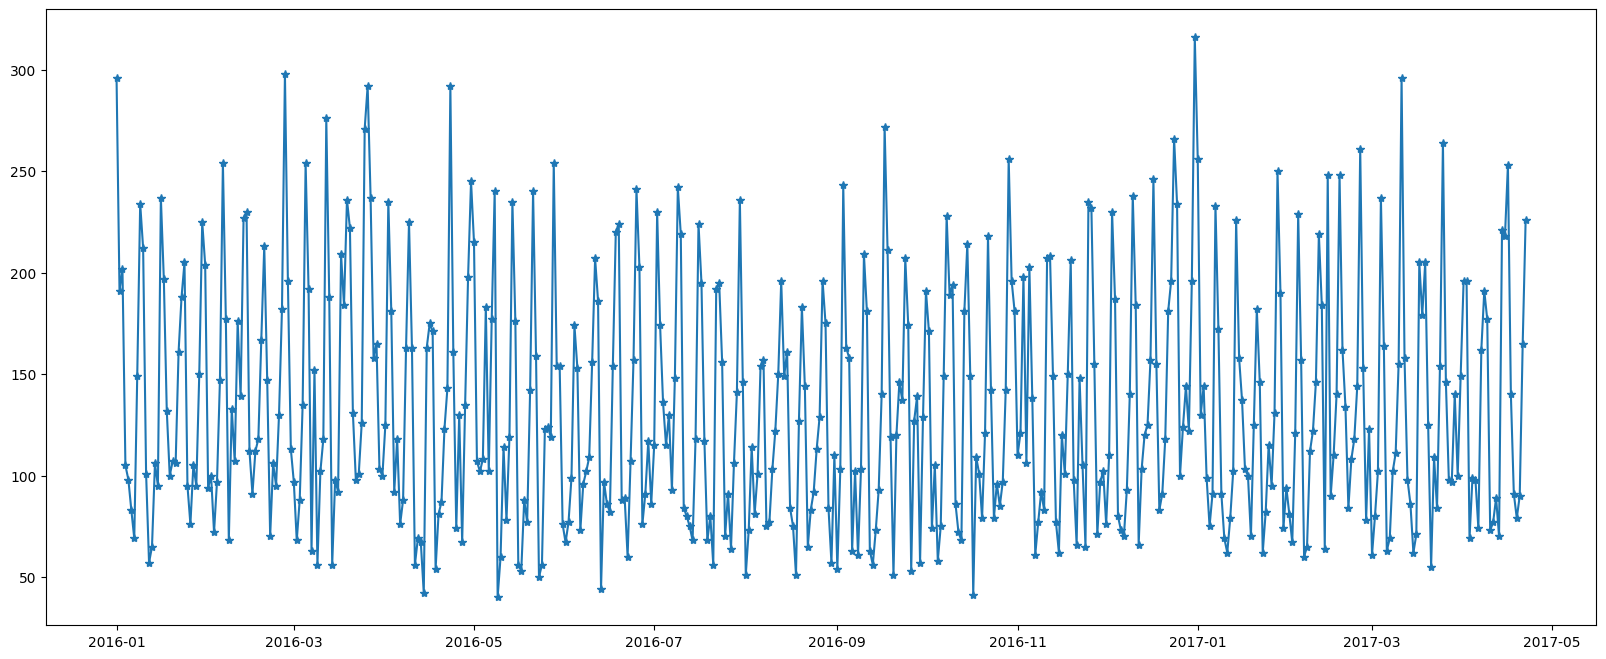

In [ ]:
# Lets take a look at our time series plot
plt.plot(df.index, df['total'], '-*')
plt.show()

> **INTERACTION**
> - Can you guess which days of the week can the peaks in the data represent?
> - Ans: weekends

In the above plot, we can see the peaks but we can't map those peaks to any particular days. Therefore let's try to decrease the number of days to plot, so that we get more insights.

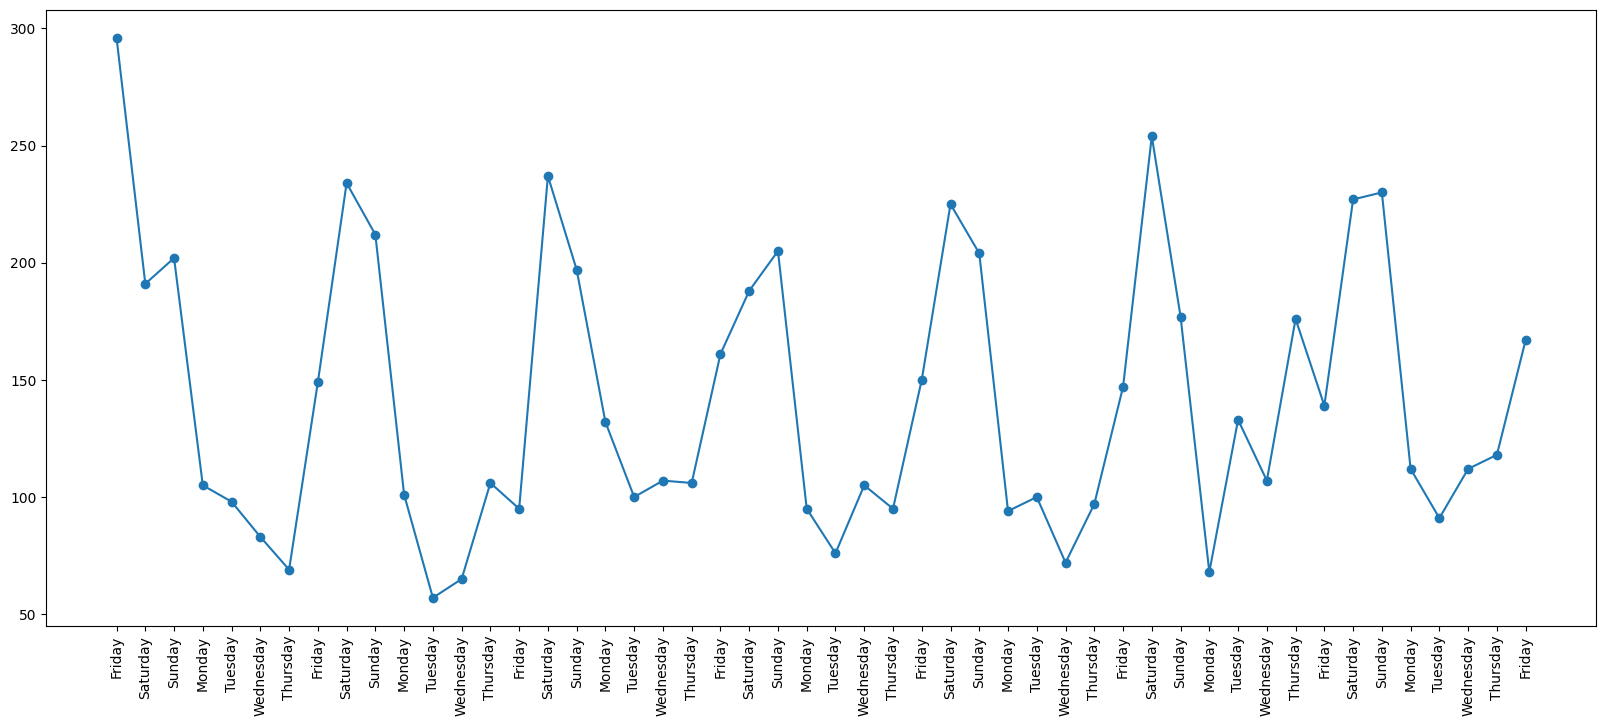

In [ ]:
plt.plot(range(50),df['total'][:50], '-o')
plt.xticks(range(0,50), df['weekday'][:50],rotation = 90)
plt.show()

It is easily observable that the peaks in the number of visitors is around Saturday and Sunday.

#### Plot the data with holidays.

We also have the data about `holidays`, therefore let's visualize it to observe any relationship between holidays and number of people visiting if it exists.

In [ ]:
df['holiday'].value_counts()

0    446
1     32
Name: holiday, dtype: int64

feature `holiday` is representing whether there is holiday (1) on the day or not(0).

Plot of data with `holiday`. Lets use a red line to indicate that the given day is a holiday.

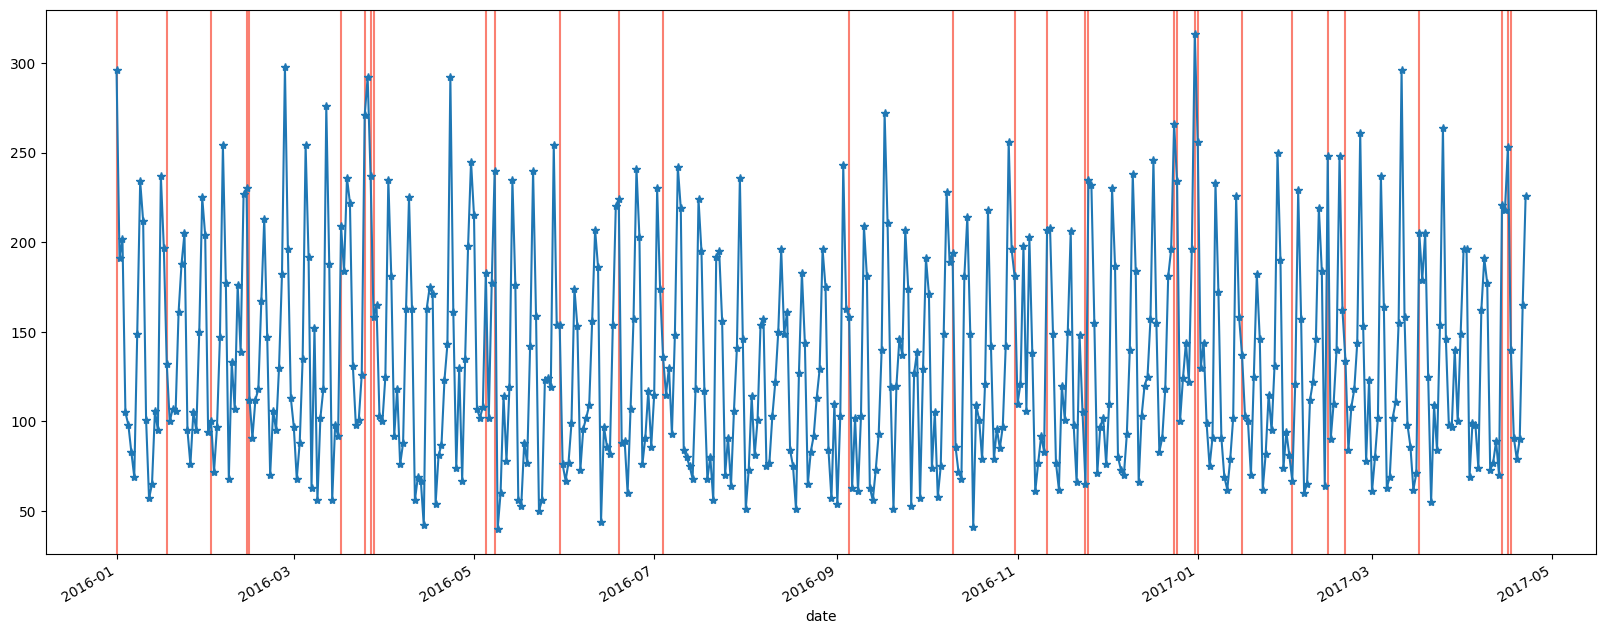

In [ ]:
# Lets take a look at our time series plot
holidays = df.loc[df.holiday==1].index
for hday in holidays:
    plt.axvline(x=hday, color='#FA8072')
df.total.plot(style='-*')
plt.show()

**Notice:-**
- We can see that holidays generally see a **peak** in foot falls.

**Now let's try to decompose the time series to see if it follows any pattern**

<Figure size 2000x800 with 0 Axes>

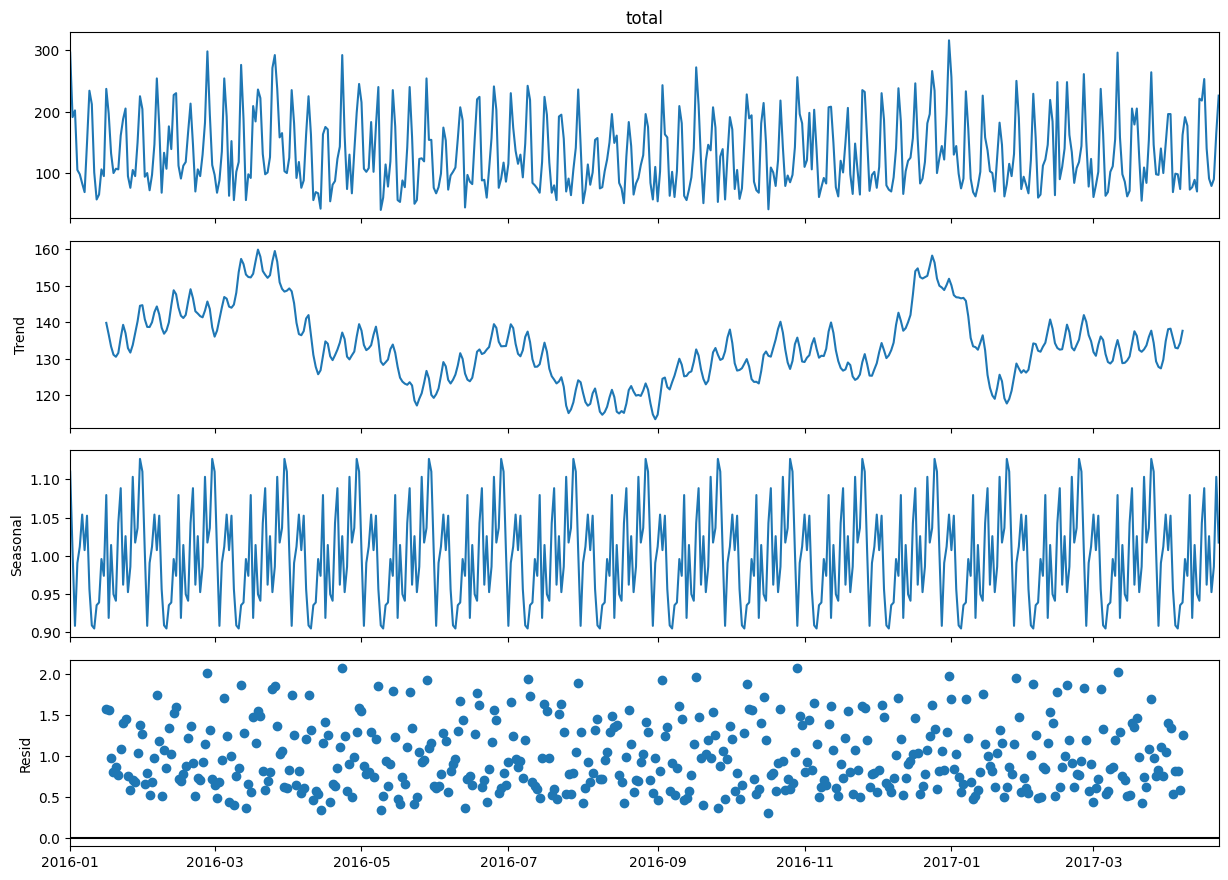

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['total'], model='multiplicative',period = 30)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(12, 9)
fig.show()

* From the above decomposition, it's visible that the data consists of seasonality and the trend is increasing and decreasing which is understandable as the number of visitors will increase during the weekends.

* As their is seasonality, let's try to use SARIMA for the predictions.

### Lets generate a baseline forecast

Now we will fit a **SARIMA model** of seasonal order (1,0,1,7) on the training data.


Here,
- $P=1$: Seasonal Auto regressive order.
- $D=0$: Differencing order of the seasonal process.
- $Q=1$: Seasonal moving average order.
- $s=7$: periodicity where the pattern repeat itself (length of cycle).
 - We can observe a **weekly** pattern, hence 7
- $p,d,q$: AR order, MA order and the Differencing order respectively, have been kept default (1,0,0)

<br>


> **Though not compulsary, a Few guidelines that one should keep in mind:**
- $m$: seasonality
 - We can identify this from the ACF and PACF plot where our value m is equal to the lag with the greatest autocorrelation coefficient other than that at lag=0.
- $P, Q$: Seasonal AR and MA orders
 - We generally do not want P+Q to exceed 2.
 - Using increasingly complex models will increase the risk of **overfitting**.
- $D$: Seasonal Differencing order
 - This can be found using `Adfuller test` on the seasonal decompose.
 - The rule of thumb for our D parameter is that both `D` and the series differencing order `d` should not be greater than 2.



Let's split the data into train and test.


In [ ]:
train = df.iloc[:436]
test = df.iloc[436:]

In [ ]:
test.tail()

,weekday,holiday,total
date,,,
2017-04-18,Tuesday,0,91.0
2017-04-19,Wednesday,0,79.0
2017-04-20,Thursday,0,90.0
2017-04-21,Friday,0,165.0
2017-04-22,Saturday,0,226.0


Let's train a pure seasonality based model, by ignoring the `p, d, q` hyperparamters

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['total'], seasonal_order=(1,0,1,7))
results = model.fit()
fc = results.forecast(42)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


###Model Diagnostics
Four plots result from the plot_diagnostics function. The Standardized residual, Histogram plus KDE estimate, Normal q-q, and the correlogram.Let's analyze the residuals after training the model on the SARIMA

- **Standardized residual**
There are no obvious patterns in the residuals, with values having a mean of zero and having a uniform variance.

- **Histogram plus KDE estimate**
The KDE curve should be very similar to the normal distribution (labeled as N(0,1) in the plot)

- **Normal Q-Q**
Most of the data points should lie on the straight line

- **Correlogram (ACF plot)**
95% of correlations for lag greater than zero should not be significant. The grey area is the confidence band, and if values fall outside of this then they are statistically significant. In our case, there are a few values outside of this area, and therefore we may need to add more predictors to make the model more accurate

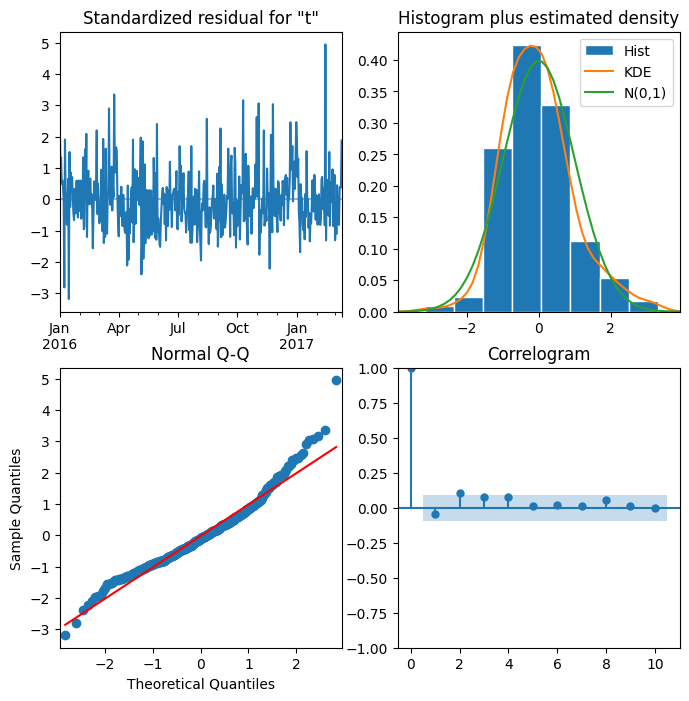

In [ ]:
results.plot_diagnostics(figsize=(8,8));

> **By observing the residual plots, what can we infer about the patterns in the residuals?**

- The residuals have **constant variance**.
- Majority of the dots lie on the red line in the Normal Q-Q plot
 - Hence, the residuals follow a **normal distribution.**
- The residuals are **not auto correlated** as there is no significant pattern.


  

Now let's use the predict() function to get the predictions for the observations in the test data.

In [ ]:
# Obtain predicted values
start=len(train)
end=len(train)+len(test)-1
predictions = results.predict(start=start, end=end)

#### Observing the relation of predicted vs actual values on holidays

Let's plot the predicted forecasts and the actual observed values on the test set, and calculate performance scores.

Also, let's add a red line to indicate the **holidays** in the test set.

**Instructor Note:**
> - No need to run the cell as the plot will be same as the attached image but arrows will not be there.

In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

MAE : 25.159
RMSE : 31.97
MAPE: 0.202


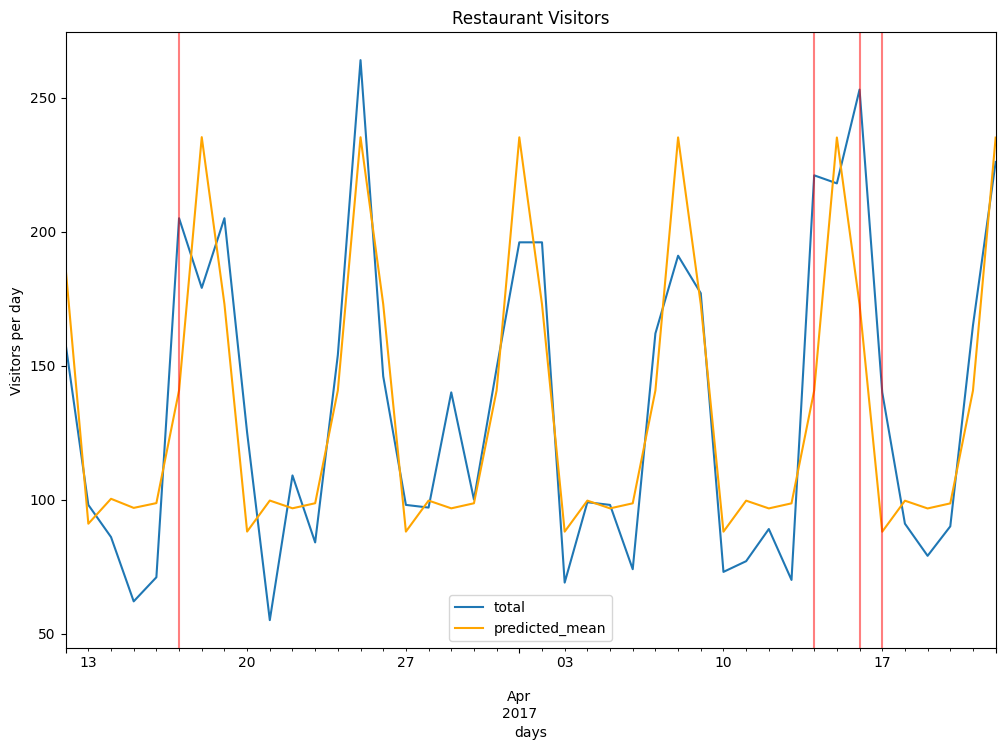

In [ ]:
performance(test['total'], predictions)
# Plot predictions against known values
title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'
ax = test['total'].plot(legend=True,figsize=(12,8),title=title)
predictions.plot(legend=True,color = 'orange')
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5)

> **Q. Can you observe any difference between actual and predicted values on the days when there was a holiday?**

 If we look at the plot of total vs predictions, it can be observed that the model has missed peaks for the holidays (see the arrows).

# Exogenous Variables

An exogenous variable is one whose value is determined outside the model and is imposed on the model. In other words, variables that affect a model without being affected by it.

- a factor whose value is determined by factors or variables outside the system under study or by the past values of it

Here are some example situations to help you understand exogenous variables:

- External factors in agriculture like floods, crop-eating pests attack
- sales when an exceptionlly good product is launched
- Demand of paracetamol if an unexpected flu spreads

## SARIMAX

Seasonal Auto-Regressive Integrated Moving Average with eXogenous factors, or SARIMAX, is an extension of the SARIMA models
SARIMAX extends on this framework just by adding the capability to handle exogenous variables.

we need to specify the exogenous variables to be used in the `exog` parameter of SARIMAX function

<br>

> **How is the exogenous variable incorporated?**

Exogenous variables are assigned a weight, say $w_i$,
- We dont need to initialise this, it is learned and trained by SARIMAX, and taken care of under the hood.

This is done in addition to the SARIMAX operations.

In [ ]:
model = SARIMAX(train['total'],exog=train['holiday'],order=(1,0,0),seasonal_order=(1,0,1,7),enforce_invertibility=False)
results = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Let's obtain the forecasts with this SARIMAX model trained with exogenous variable.

In [ ]:
exog_forecast = test[['holiday']]  # requires two brackets to yield a shape of (35,1)
predictions = results.predict(start=start, end=end, exog=exog_forecast).rename('Predictions')

#### Let's plot the predicted vs actual forecast values, and observe them closely on holidays.

**Instructor Note:**
> * No need to run the cell as the plot will be the same but arrows will not be there.

MAE : 18.649
RMSE : 22.93
MAPE: 0.161


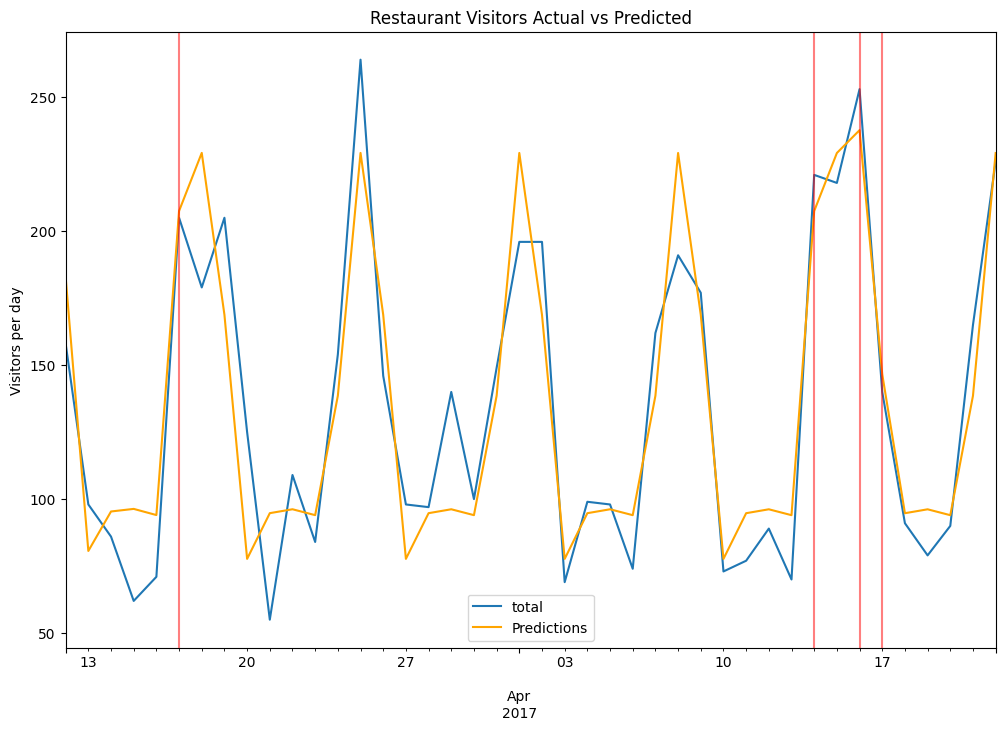

In [ ]:
performance(test['total'], predictions)
# Plot predictions against known values
title='Restaurant Visitors Actual vs Predicted'
ylabel='Visitors per day'
xlabel=''

ax = test['total'].plot(legend=True,figsize=(12,8),title=title)
predictions.plot(legend=True, color = 'orange')
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5);

MAE : 18.649<br>
RMSE : 22.93<br>
MAPE: 0.161<br>
<img src = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/007/810/original/Screenshot_2022-07-22_at_9.12.57_PM.png?1658504130" width = 800, height = 400/>

- It can be observed that the predictions now are somewhat more closer to the peaks, for holidays.
 - Observe the arrows.

- Moreover, the peformace has also improved a lot.



>**Assessment Questions**
- Forecasting: https://www.scaler.com/hire/test/problem/27521/

####**Forecasting for the 39 newer observations**

We earlier dropped the rows which had Nan in the starting, now let's predict the values of `total` for these 39 observations.

Now we will be using SARIMAX to forecast the number of visitors of the last 39 observations which had null values. We will be using the 'holiday' data.

In [ ]:
model = SARIMAX(df['total'],exog=df['holiday'],order=(1,0,0),seasonal_order=(1,0,1,7),enforce_invertibility=False)
results = model.fit()
exog_forecast = df1[478:][['holiday']]
fcast = results.predict(478,df1.shape[0]-1,exog = exog_forecast).rename('Forecast')

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In the above code snippet we are using `df1` to get the `holiday` data for the rows where the `total` was none and we dropped them.

Here we are just visualizing the last 100 observations of the dataset, for clear visualization.

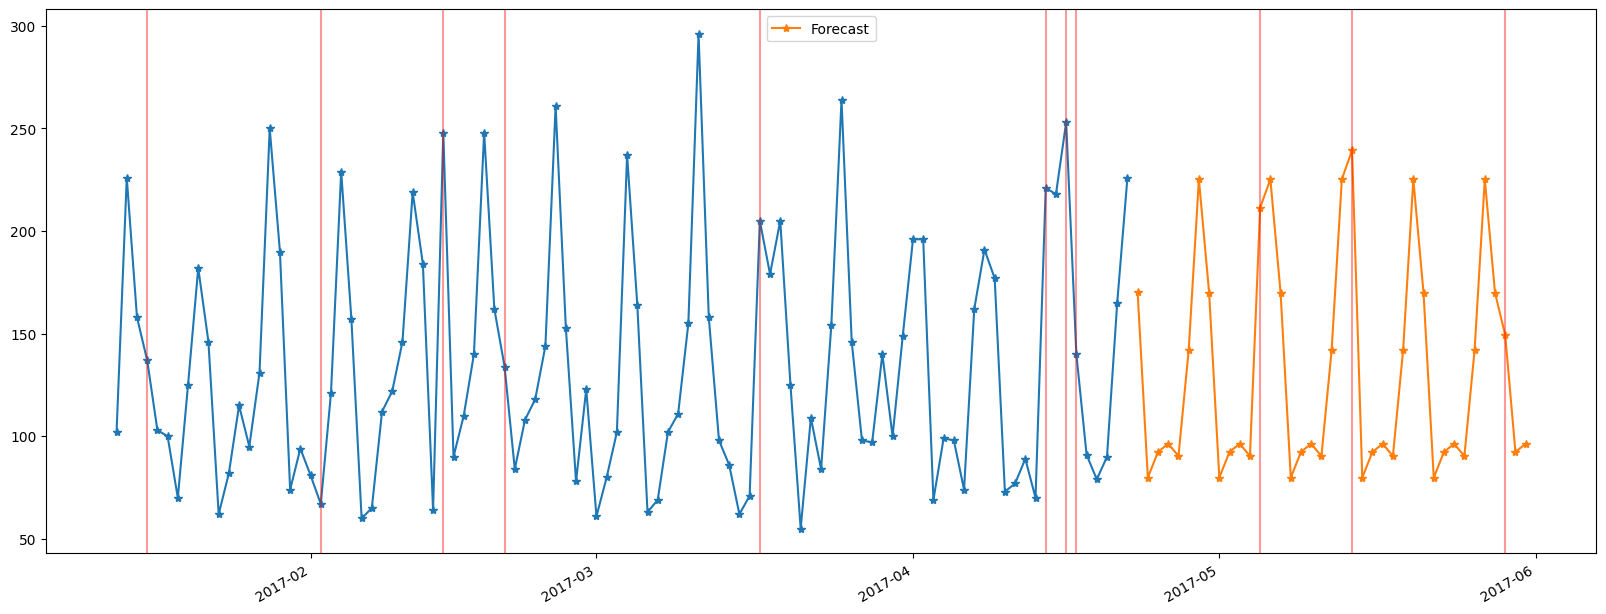

In [ ]:
# Plot the forecast alongside historical values
title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'

# ax = df['total'][-100:].plot(legend=True,figsize=(16,5),title=title, style = '-*')
plt.plot(df[-100:].index, df[-100:].total, '-*')
fcast.plot(legend=True, style = '-*')
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in df[-100:].query('holiday==1').index:
    plt.axvline(x=x, color='red', alpha = 0.4)

for x in df1[-42:].query('holiday==1').date:
    plt.axvline(x=pd.to_datetime(x), color='red', alpha = 0.4)


Note that as a real forecaster,
- you will have to decide wether the future plot looks correct or not.
- Metrics and other measures aside, it is your responsibility that forecast should be correct.
- Hence forecasting is a game of experience, not just theory and code

# Time Series with Linear Regression


can we use regression for forecasting. Yes because we need to get a value as prediction so its not a classification problem

> we have already seen how regresion is used for prediction in AR Model, so how is this different.
- it is different in the features that we use for regression.
- in AR model we only used past lags till certain degree as features

- if we have some exogenous variables and other data that we can utilize as our feture and covert this to a proper supervised regression problem

## Feature Engineering for Time Series
we will use feature engineering to construct all of the inputs that will be used to make predictions for future time steps.The goal of feature engineering is to provide strong and ideally simple relationships between new input features and the output feature to model.

> **Date-Time Related Features**
Date time features are features created from the time stamp value of each observation. A few examples of these features are the integer hour, month, and day of week for each observation. Data scientists can perform transformations of these date time features using pandas and adding new columns (hour, month, and day of week columns) to their original dataset where hour, month, and day of week information is extracted from the timestamp value for each observation.

- Minutes of the day.
- Hour of day.
- weekend/weekday
- Business hours or not.
- Season of the year.
- Business quarter of the year.
- Dayltime or night.
- Public holiday or not.

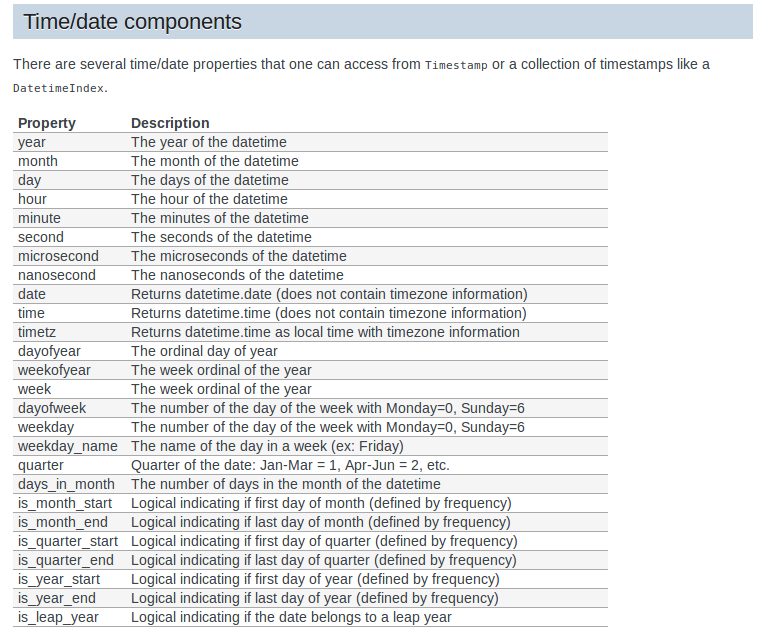

> **Lag Features**
are considered useful because they are created on the assumption that what happened in the past can influence or contain a sort of intrinsic information about the future.
Consider this – you are predicting the stock price for a company. So, the previous day’s stock price is important to make a prediction, right? In other words, the value at time t is greatly affected by the value at time t-1.

- The Pandas library provides the shift() function to help create these shifted or lag features from a time series dataset. Shifting the dataset by 1 creates the t-1 column and so on.
- weekly shift
- monthly shift
- yearly shift

> **Window statistics**
A step beyond adding raw lagged values is to add a summary of the values at previous time steps.
We can calculate summary statistics across the values in the sliding window and include these as features in our dataset.

- Pandas provides a rolling() function that provides rolling window calculations, and it creates a new data structure with the window of values at each timestep.
- getting mean of median of previous window
- Expanding window statistics consist of features that include all previous data. Pandas offers an expanding() function that provides expanding transformations and assembles sets of all prior values for each timestep.

### Implimentation

In [ ]:
df = df1.copy()
df['date'] = pd.to_datetime(df['date'])

We have seen in the decomposed plots that the number of visitors alter during weekdays and weekends and there is also some pattern in the trends over the weeks.

Earlier we saw that the number of visitors was higher on the weekends according to the data.

Therefore let's try engineering a new feature which indicates whether there is a weekend or not.

In [ ]:
df["weekday"] = np.where(((df["weekday"] == "Friday") | (df["weekday"] == "Thursday") | (df["weekday"] == "Wednesday") | (df["weekday"] == "Tuesday") | (df["weekday"] == "Monday")), "working_day", "weekend")
intmdt = pd.get_dummies(df['weekday'])
df = pd.concat([df, intmdt],axis =1 )
df.head()

,date,weekday,holiday,total,weekend,working_day
0,2016-01-01,working_day,1,296.0,0,1
1,2016-01-02,weekend,0,191.0,1,0
2,2016-01-03,weekend,0,202.0,1,0
3,2016-01-04,working_day,0,105.0,0,1
4,2016-01-05,working_day,0,98.0,0,1


**Now lets capture weekly seasonality**

In [ ]:
df['dayofweek'] = df['date'].dt.dayofweek
df['sale_wrt_dow'] = df.groupby('dayofweek')['total'].transform('mean')
df[['sale_wrt_dow', 'dayofweek']].drop_duplicates()

,sale_wrt_dow,dayofweek
0,148.840580,4
1,228.101449,5
2,180.338235,6
3,90.691176,0
4,93.838235,1
5,94.411765,2
6,98.720588,3


Now let's calculate the values of past 1-31 days number of visitors for each observation storing in columns with name Lag_i where i is the previous ith day's observation.

In [ ]:
for i in range(1,32):
  df["Lag_{}".format(i)] = df['total'].shift(i)

Let's try to use the average of past one months values for each observation as a feature named `average_monthly_lag`

In [ ]:
lis = ['Lag_{}'.format(i) for i in range(1,32)]
df.dropna(inplace = True)    # Drop because some Lags will be NaN.
df['last_month_avg_level'] = df.loc[:,lis].sum(axis=1)/31
df.head()

,date,weekday,holiday,total,weekend,working_day,dayofweek,sale_wrt_dow,Lag_1,Lag_2,...,Lag_23,Lag_24,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level
31,2016-02-01,working_day,0,94.0,0,1,0,90.691176,204.0,225.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355
32,2016-02-02,working_day,1,100.0,0,1,1,93.838235,94.0,204.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226
33,2016-02-03,working_day,0,72.0,0,1,2,94.411765,100.0,94.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742
34,2016-02-04,working_day,0,97.0,0,1,3,98.720588,72.0,100.0,...,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,129.774194
35,2016-02-05,working_day,0,147.0,0,1,4,148.840580,97.0,72.0,...,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,129.516129


Similarly let's use a feature 'average_weekly_lag' for an average past 7 days observations.



In [ ]:
lis = ['Lag_{}'.format(i) for i in range(1,8)]
df['last_week_avg_level'] = df.loc[:,lis].sum(axis=1)/7
df.head(3)

,date,weekday,holiday,total,weekend,working_day,dayofweek,sale_wrt_dow,Lag_1,Lag_2,...,Lag_24,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level
31,2016-02-01,working_day,0,94.0,0,1,0,90.691176,204.0,225.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286
32,2016-02-02,working_day,1,100.0,0,1,1,93.838235,94.0,204.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429
33,2016-02-03,working_day,0,72.0,0,1,2,94.411765,100.0,94.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000


We can have 'average_biweekly_lag' as well.

In [ ]:
lis = ["Lag_{}".format(i) for i in range(1,15)]
df['last_2week_avg_level'] = df.loc[:,lis].sum(axis = 1)/14
df.head(3)

,date,weekday,holiday,total,weekend,working_day,dayofweek,sale_wrt_dow,Lag_1,Lag_2,...,Lag_25,Lag_26,Lag_27,Lag_28,Lag_29,Lag_30,Lag_31,last_month_avg_level,last_week_avg_level,last_2week_avg_level
31,2016-02-01,working_day,0,94.0,0,1,0,90.691176,204.0,225.0,...,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,135.714286,139.214286
32,2016-02-02,working_day,1,100.0,0,1,1,93.838235,94.0,204.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,135.571429,136.500000
33,2016-02-03,working_day,0,72.0,0,1,2,94.411765,100.0,94.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,139.000000,136.500000


In [ ]:
df.shape

(447, 42)

Let's retrieve the present features and columns in the dataframe to decide which featues we can use in predictions.

In [ ]:
df.columns

Index(['date', 'weekday', 'holiday', 'total', 'weekend', 'working_day',
       'dayofweek', 'sale_wrt_dow', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
       'Lag_5', 'Lag_6', 'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10', 'Lag_11',
       'Lag_12', 'Lag_13', 'Lag_14', 'Lag_15', 'Lag_16', 'Lag_17', 'Lag_18',
       'Lag_19', 'Lag_20', 'Lag_21', 'Lag_22', 'Lag_23', 'Lag_24', 'Lag_25',
       'Lag_26', 'Lag_27', 'Lag_28', 'Lag_29', 'Lag_30', 'Lag_31',
       'last_month_avg_level', 'last_week_avg_level', 'last_2week_avg_level'],
      dtype='object')

Let's keep a copy of this version of the dataset so that we could use them later.

In [ ]:
import copy             #dfo has the data with all the columns
dfo = df.copy()

In [ ]:
df = dfo.copy()
df = df[['total', 'Lag_1', 'last_month_avg_level', 'last_week_avg_level',
          'last_2week_avg_level', 'sale_wrt_dow', 'holiday']]
df.head()

,total,Lag_1,last_month_avg_level,last_week_avg_level,last_2week_avg_level,sale_wrt_dow,holiday
31,94.0,204.0,143.419355,135.714286,139.214286,90.691176,0
32,100.0,94.0,136.903226,135.571429,136.500000,93.838235,1
33,72.0,100.0,133.967742,139.000000,136.500000,94.411765,0
34,97.0,72.0,129.774194,134.285714,134.000000,98.720588,0
35,147.0,97.0,129.516129,134.571429,133.357143,148.840580,0


Splitting the dataset into train and test.Preparing X and y for training the model.

In [ ]:
train = df.iloc[:df.shape[0]-42].dropna()
test = df.iloc[df.shape[0]-42:]


train_X = train.drop(["total"],axis =1)
train_y = train['total']
test_X = test.drop(["total"],axis =1)
test_y = test['total']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape

# Train and pred
model = LinearRegression()
model.fit(train_X, train_y)
y_pred = pd.Series(model.predict(test_X), index=test.index)
mape(test['total'],y_pred)

0.15182569897310053

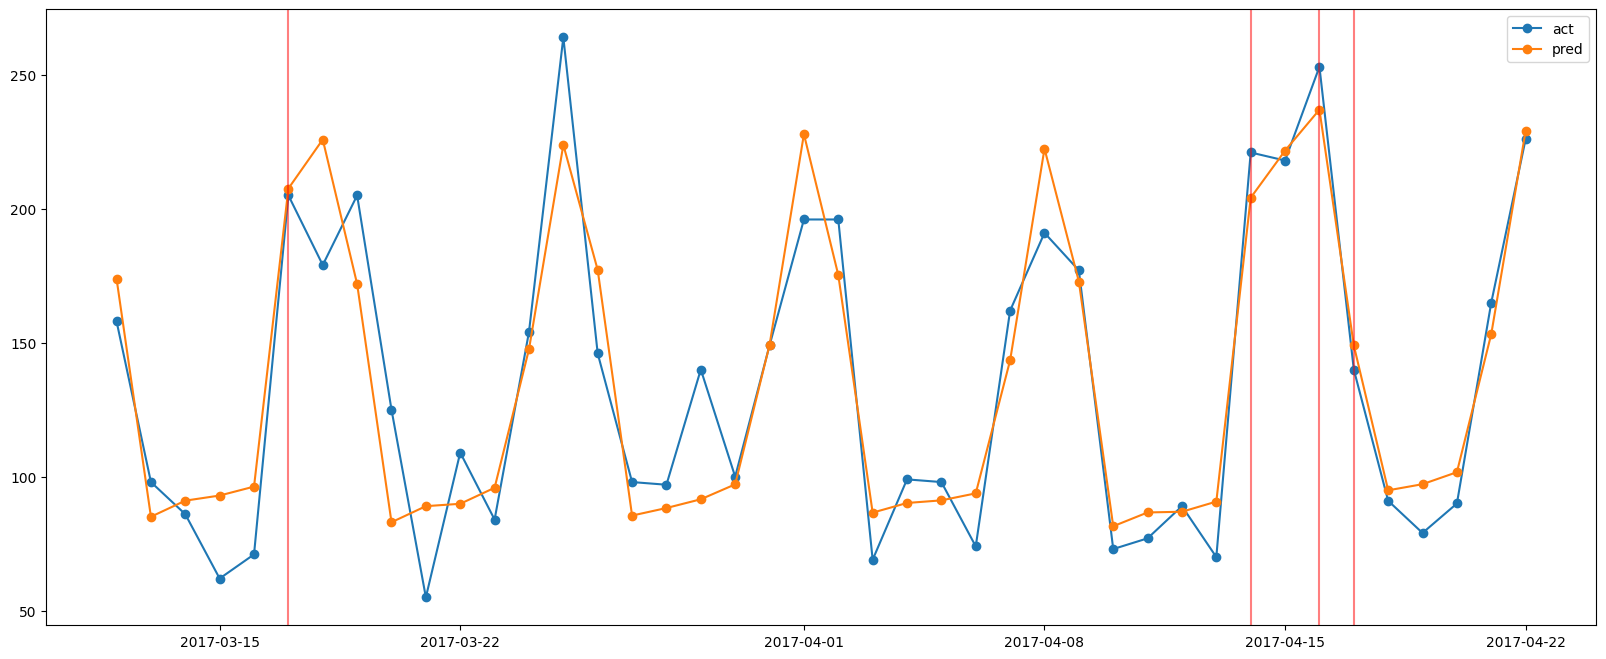

In [ ]:
plt.plot(dfo.tail(42)['date'], test_y, '-o', label='act')
plt.plot(dfo.tail(42)['date'], y_pred, '-o', label='pred')
for x in dfo[-42:].query('holiday==1')['date']:
    plt.axvline(x=x, color='red', alpha = 0.5)
plt.legend()

- This performance is surprisingly very good.
- Note that this is a much simpler algorithm than SARIMAX.

Further improvements can be done with

- Thinking of more inovative features.
- Better feature selection
- Different regressors and Hyper parameter tuning
- Stacking / Cascading etc.

> **IMPORTANT NOTE**
> - please note that SARIMAX forecast was 1 - 42 days into the future. This forecast is only 1 day into the future!! Lag_1 has been used as a feature!
- if your model uses lag or window features it is not possible for multiple predictions is the lags are not available
> - For multiple days ahead forecast you need a **new LR for each horizon**. Shift your target by -k, where k is horizon-1

Let's try to use a combination of newly engineered variables with Lag_1 and weekend to train the linear regression model.

# Facebook’s Prophet

https://peerj.com/preprints/3190.pdf

The Prophet library is an open-source library designed for making forecasts for univariate time series datasets. It is easy to use and designed to automatically find a good set of hyperparameters for the model in an effort to make skillful forecasts for data with trends and seasonal structure by default.

> It is particularly good at modeling time series that have multiple seasonalities and doesn’t face some of the above drawbacks of other algorithms. At its core is the sum of three functions of time plus an error term: growth $g(t)$, seasonality $s(t)$, holidays $h(t)$ , and error $e_t$ :

          `y(t)= g(t) + s(t) + h(t) + εt`


- NOTE: Prophet does not perform well on non-stationary data because it is difficult to find the actual seasonality and trend of the data if the patterns are inconsistent.

- Prophet can also handle outliers and handles other data issues by itself.  
- It can fit time-series data having non-linearity in trends as well as holiday effects.
- It works quite well with data having daily, weekly, monthly and/or yearly seasonality
- it can handle multiple seasonalities simultaneously
- It is highly susceptible to missing data, outliers and erratic changes in time-series data.

### Prophet Implementation

For using `prophet` we need to install `pystan` as well which is an interface.

**Instructor Note**:
> - This installation will take around 5-6 mins, so better to do it earlier.

In [ ]:
!pip install pystan~=2.14
#!pip install fbprophet

* We're using the same dataset .

* For using Prophet, data set should contain only two columns with column names as ‘ds’ and ‘y’

* ‘ds’ should always be in ‘date-time’ format.

The DataFrame must have a specific format. The first column must have the name ‘ds‘ and contain the date-times. The second column must have the name ‘y‘ and contain the observations.

In [ ]:
df = df1.copy()

In [ ]:
df['ds'] = pd.to_datetime(df['date'])
df['y'] = df['total']
df = df[['ds', 'y', 'holiday']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ds       517 non-null    datetime64[ns]
 1   y        478 non-null    float64       
 2   holiday  517 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 12.2 KB


#### Fitting Prophet

To use Prophet for forecasting, first, a Prophet() object is defined and configured, then it is fit on the dataset by calling the fit() function and passing the data.

The Prophet() object takes arguments to configure the type of model you want, such as the type of growth, the type of seasonality, and more. By default, the model will work hard to figure out almost everything automatically.

* `make_future_dataframe` creates a placeholder for storing future variables, so we will be predicting future values for 12 periods.

* Firstly, let's try to fit a model without adding seasonality component and holiday effects.

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4y70ss2/dx0ekg5d.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4y70ss2/zoh7ewjx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=51001', 'data', 'file=/tmp/tmpt4y70ss2/dx0ekg5d.json', 'init=/tmp/tmpt4y70ss2/zoh7ewjx.json', 'output', 'file=/tmp/tmpt4y70ss2/prophet_model_nizytv5/prophet_model-20240229113221.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:32:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:32:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


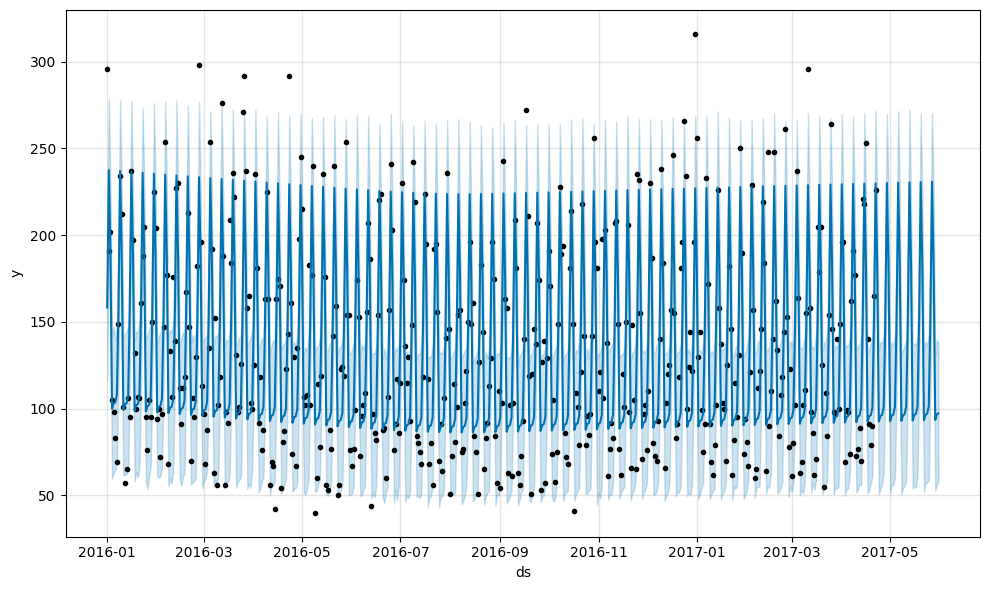

In [ ]:
#from fbprophet import Prophet
from prophet import Prophet
m = Prophet()
m.fit(df[['ds', 'y']][:-39]) #here we are leaving last 39 observations because we will predict it in 'future'
future = m.make_future_dataframe(periods=39,freq="D")
forecast = m.predict(future)
fig = m.plot(forecast)

* In the plot, black dots are actual visits, deep blue lines are the predicted visits and light blue lines is the 95% confidence interval around the prediction.

- You can see that the lines are flat and the model is not able to capture the seasonality properly so it is not a good fit.
- Here light blue lines are 95% confidence intervals around the predictions.
- Here we also didn't do anything explicitly for `Nan` values it was handled by `prophet`.

Let's see what has the model stored in `forecast` in the above code snippet.


In [ ]:
forecast.tail(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
513,2017-05-28,136.358999,142.748702,226.363685,136.198032,136.523571,46.765696,46.765696,46.765696,46.765696,46.765696,46.765696,0.0,0.0,0.0,183.124695
514,2017-05-29,136.384708,52.748355,130.683404,136.218600,136.557113,-42.866641,-42.866641,-42.866641,-42.866641,-42.866641,-42.866641,0.0,0.0,0.0,93.518067
515,2017-05-30,136.410417,56.167443,139.511911,136.238663,136.589384,-39.702954,-39.702954,-39.702954,-39.702954,-39.702954,-39.702954,0.0,0.0,0.0,96.707463
516,2017-05-31,136.436126,57.804532,138.347211,136.254504,136.622821,-39.112778,-39.112778,-39.112778,-39.112778,-39.112778,-39.112778,0.0,0.0,0.0,97.323347


There are a lot of added features in the dataframe which include `yhat_lower` and `yhat_upper` for the confidence intervals. `yhat` is the prediction.

Comparing the predictions
- Here we are just plotting the observations and predictions of the dates between `2017-01-01` and `2017-04-22`.

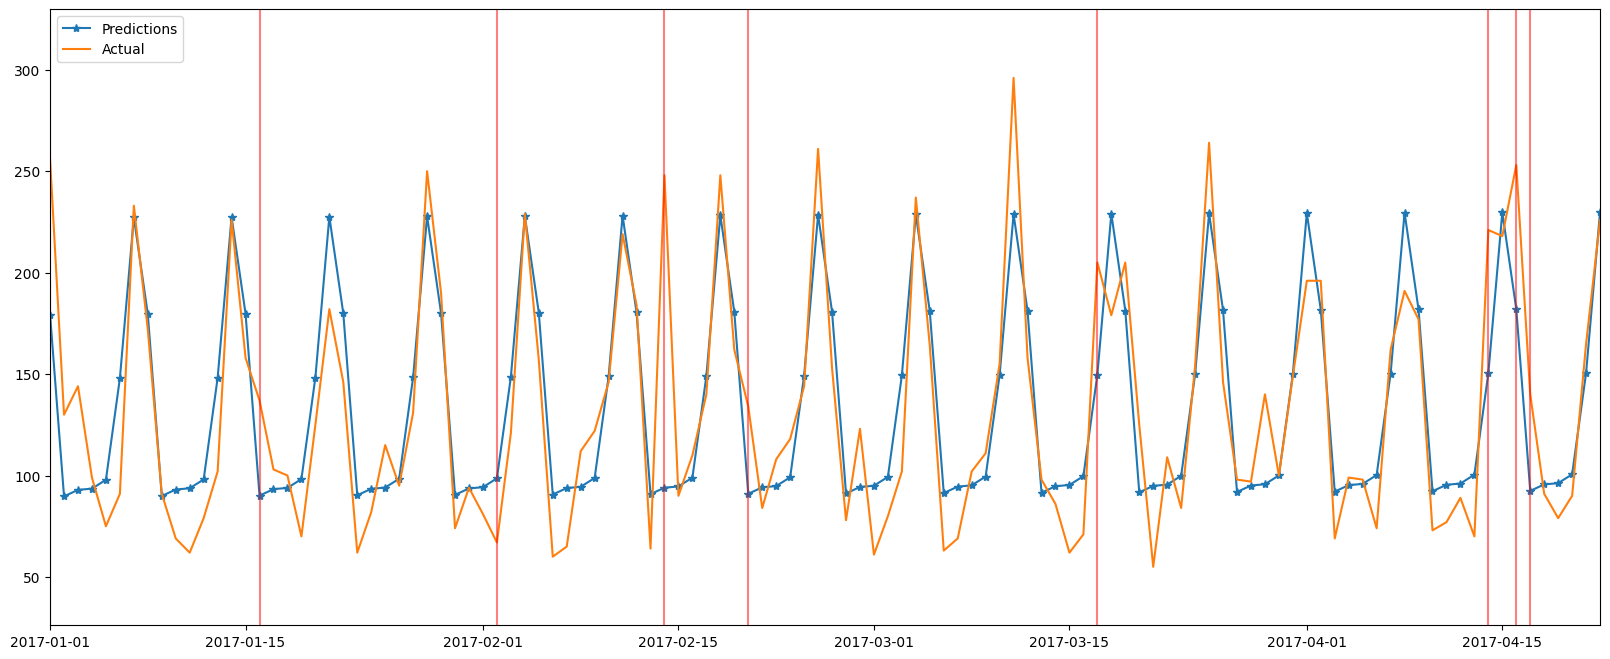

In [ ]:
plt.plot(forecast['ds'], forecast['yhat'],'-*', label = 'Predictions')
plt.plot(df['ds'], df['y'], label = 'Actual')
for x in df.query('holiday==1')['ds']:
    plt.axvline(x=x, color='red', alpha = 0.5);
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2017-04-22'))
plt.legend()

- In the plot we can see that the values predicted are flat therefore it's not able to capture the fluctuations properly.

- Here the model is just predicting according to the seasonality it's not taking anything else into account.

- Here the predicted values can be considered as the average seasonality.
  - i.e. The prediction on sunday would be the average of values on past Sundays.

Here we are leaving last 39 observations while calculating the metrics as we don't have actual values of `visitors` for those days.

In [ ]:
performance(df['y'][:-39],forecast['yhat'][:-39])

MAE : 24.057
RMSE : 31.984
MAPE: 0.213


Now, this time, let's apply seasonality(yearly and weekly), and add holiday effects in our model and fit it in order to get a better model.

This can be done simply by setting `yearly_seasonality` and `weekly_seasonality` as `True`.

####**Q. How can we add exogenous variable to the prophet model?**

We can use `add_regressor` for adding features to the prophet model.

<br>

https://medium.com/grabngoinfo/hyperparameter-tuning-and-regularization-for-time-series-model-using-prophet-in-python-9791370a07dc

There is another interesting parameter here: `changepoint_prior_scale`
It determines the scale of the change at the time series trend change point.
- By default, changepoint_prior_scale it is set to 0.05, increasing this value allows the automatic detection of more change points and decreases it allows for less. Alternatively, we can specify a number of changepoints to detect using n_changepoints or list the changepoints ourselves using changepoints. Be careful with this, as too many changepoints may cause overfitting.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4y70ss2/546o8x4n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4y70ss2/0pm0456m.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=7882', 'data', 'file=/tmp/tmpt4y70ss2/546o8x4n.json', 'init=/tmp/tmpt4y70ss2/0pm0456m.json', 'output', 'file=/tmp/tmpt4y70ss2/prophet_model9cltoooz/prophet_model-20240229113222.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:32:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:32:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


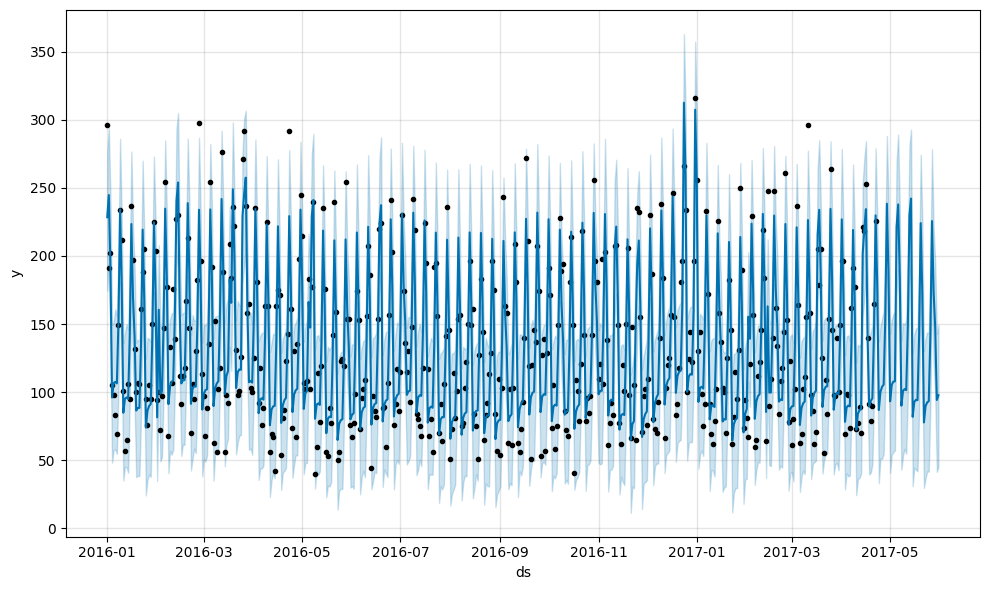

In [ ]:
model2=Prophet(interval_width=0.95, yearly_seasonality=True, weekly_seasonality=True,
               changepoint_prior_scale=4)
model2.add_regressor('holiday') #adding holidays data in the model3
model2.fit(df[:-39])
forecast2 = model2.predict(df)
fig = model2.plot(forecast2)

In [ ]:
performance(df['y'][:-39],forecast2['yhat'][:-39])

MAE : 19.923
RMSE : 25.671
MAPE: 0.18


All the metrics have improved from the last model which wasn't using the `holiday` feature.

* We got a Mean absolute percentage error of 18, which might not seem great, but it really depends on the use case.
- The performance has certainly improved in terms of the above mentioned metrics.

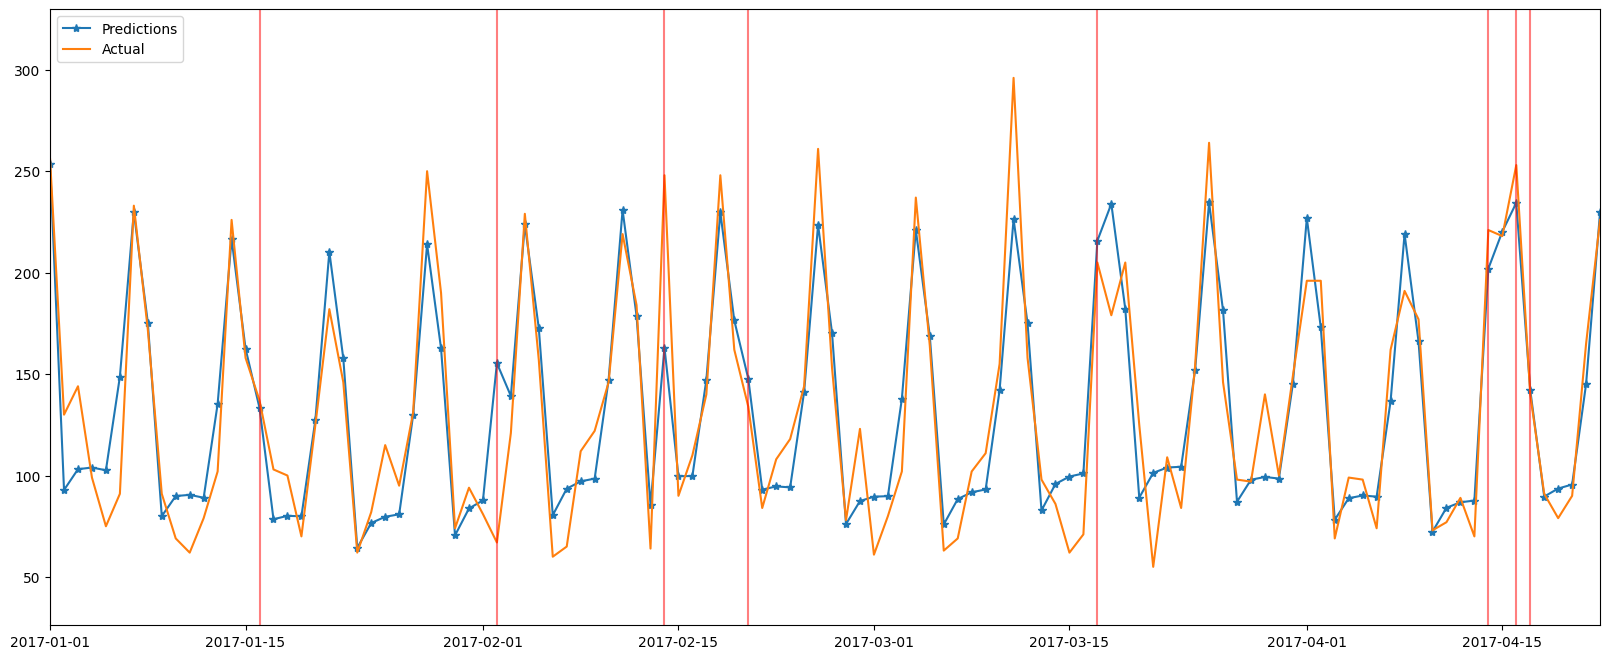

In [ ]:
plt.plot(forecast2['ds'], forecast2['yhat'],'-*', label = 'Predictions')
plt.plot(df['ds'], df['y'], label = 'Actual')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2017-04-22'))
for x in df.query('holiday==1')['ds']:
    plt.axvline(x=x, color='red', alpha = 0.5);
plt.legend()

* We can see the model with added yearly and weekly seasonality and holidays, has a good fit trying to capture most of the data points and patterns.



This time the model didn't give flat outputs.

**Even if we don't have the holiday's data, we can use Prophet for getting the holidays data.**
- prophet has holiday list for 19 countries to be directly used

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4y70ss2/zi2veuvl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpt4y70ss2/5h25j_uu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48320', 'data', 'file=/tmp/tmpt4y70ss2/zi2veuvl.json', 'init=/tmp/tmpt4y70ss2/5h25j_uu.json', 'output', 'file=/tmp/tmpt4y70ss2/prophet_modelsrghvwp8/prophet_model-20240229113223.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:32:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:32:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


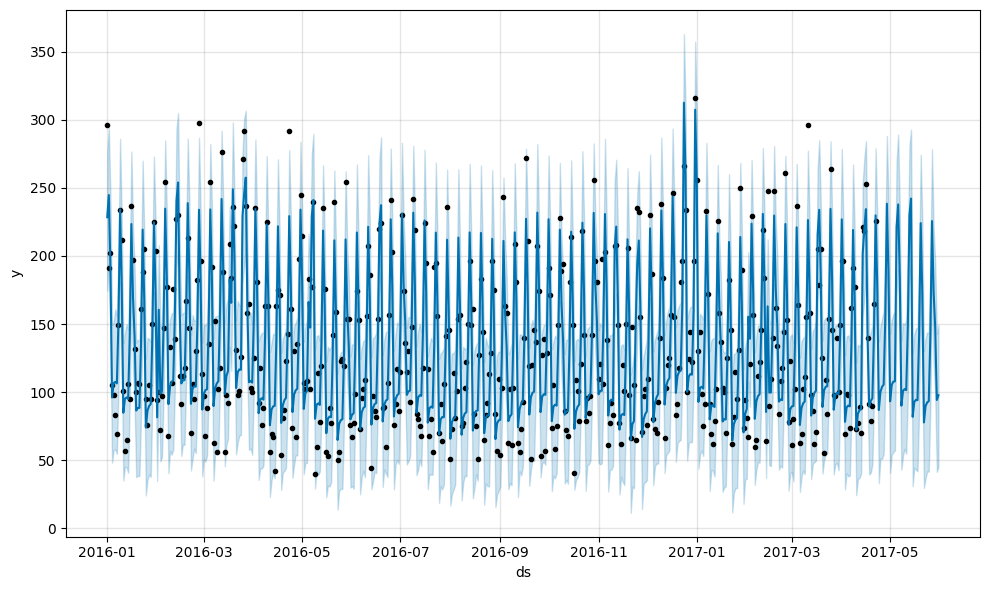

In [ ]:
model3=Prophet(interval_width=0.95, yearly_seasonality=True, weekly_seasonality=True,
               changepoint_prior_scale=4)
model3.add_country_holidays(country_name='US') #adding holidays data in the model2
model3.fit(df[:-39])
future = m.make_future_dataframe(periods=39,freq="D")
forecast3 = model3.predict(df)
fig = model3.plot(forecast2)

In [ ]:
performance(df['y'][:-39],forecast3['yhat'][:-39])

MAE : 20.942
RMSE : 27.732
MAPE: 0.184


Here the `MAPE` of predictions has gone down to `18.5`
- This is understandable as the `holiday` data given to us would be more exact or subjective to the region which could be more accountable to the fluctuations, than the general holiday data provided by the model.